# DSSE-Net without residual connections: nested patient-level validation

This is the reproducible notebook for data decoding, quality control, cropping, nested stratified patient-level cross-validation, training, evaluation, ablation, baseline comparison, and Grad-CAM.

The selected primary configuration is **DSSE-Net without residual connections**. Its frozen results and explainability dashboard appear immediately after the imports. Long implementation cells are collapsed for readability, and all expensive training switches are disabled by default.

Data protocol: 233 patients, 2,931 quality-controlled MRI slices, five outer folds, and five inner folds per outer development set. The verified label mapping is `1=meningioma`, `2=glioma`, and `3=pituitary`.

## Imports

In [1]:
from __future__ import annotations

import os

# Required by CuBLAS for reproducible CUDA matrix operations. This must be
# configured before the first CUDA operation in a fresh Jupyter kernel.
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import torch
from torch import nn
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from statsmodels.stats.contingency_tables import mcnemar
import numpy as np
import cv2
import json
import gc

from pathlib import Path

from timeit import default_timer as timer
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, cohen_kappa_score,
    confusion_matrix, log_loss, matthews_corrcoef,
    precision_recall_fscore_support, roc_auc_score, roc_curve, auc,
)
from sklearn.preprocessing import label_binarize

import seaborn as sns
from thop import profile
import h5py
from collections import Counter
from hashlib import sha256
import platform
import random
import shutil

import pandas as pd
import sklearn
from IPython.display import display
from sklearn.model_selection import StratifiedGroupKFold

print(torch.__version__)  # want 1.12+
print(torchvision.__version__)  # want 0.13+

# Setup device-agnostic code.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

# Display NVIDIA GPU information when CUDA is available.
if torch.cuda.is_available():
    !nvidia-smi

SEED = 42
OUTER_FOLDS = 5
INNER_FOLDS = 5

RAW_LABEL_TO_CLASS = {1: "meningioma", 2: "glioma", 3: "pituitary"}
CLASS_TO_INDEX = {"meningioma": 0, "glioma": 1, "pituitary": 2}

EXPECTED_SLICES = 3064
EXPECTED_PATIENTS = 233
EXPECTED_IMAGE_COUNTS = {1: 708, 2: 1426, 3: 930}
EXPECTED_PATIENT_COUNTS = {1: 82, 2: 89, 3: 62}

PROJECT_ROOT = Path.cwd().resolve()
RAW_MAT_DIR = PROJECT_ROOT / "brainDataset"
OUTPUT_DIR = PROJECT_ROOT / "nested_cv_artifacts"
IMAGE_ROOT = PROJECT_ROOT / "nested_cv_images"
CANONICAL_IMAGE_ROOT = IMAGE_ROOT / "all_images"
CROPPED_ROOT = PROJECT_ROOT / "nested_cv_cropped"
CROPPED_CANONICAL_ROOT = CROPPED_ROOT / "all_images"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not RAW_MAT_DIR.is_dir():
    raise FileNotFoundError(
        f"Expected raw dataset at {RAW_MAT_DIR}. Run this notebook from zubNet-A."
    )

random.seed(SEED)
np.random.seed(SEED)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw dataset:  {RAW_MAT_DIR}")
print(f"Artifacts:    {OUTPUT_DIR}")
print(f"Python: {platform.python_version()} | h5py: {h5py.__version__} | sklearn: {sklearn.__version__}")

2.7.1+cu128
0.22.1+cu128
cuda
Tue Sep  8 00:14:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 616.56                 KMD Version: 616.56        CUDA UMD Version: 13.4     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5080      WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   49C    P5             32W /  360W |    1547MiB /  16303MiB |     10%      Default |
|                                         |                        |                  N/A |
+-----------------

## Selected primary model: DSSE-Net without residual connections

The completed `without_residual` variant is the selected DSSE-Net configuration in this notebook. It retains depthwise convolution, squeeze-and-excitation attention, block dropout, classifier dropout, and the original training augmentation (including vertical flip), but removes every residual shortcut addition.

Selection criterion: highest pooled out-of-fold patient-level accuracy and macro-F1 among the evaluated DSSE-Net configurations. The component analysis identified this configuration as the final architecture. Its reported OOF performance remains internal-validation evidence and is not independent external validation. All long-running switches remain disabled by default.

**Frozen result location:** `nested_cv_ablation_results/split_ablation/without_residual/`

In [2]:
from dsse_primary import (
    DSSEWithoutResidual,
    PRIMARY_VARIANT,
    build_primary_baseline_mcnemar,
    build_primary_gradcam_gallery,
    load_primary_report,
    plot_primary_dashboard,
    primary_result_root,
)
from IPython.display import Image as NotebookImage

PRIMARY_RESULTS_ROOT = primary_result_root(PROJECT_ROOT)
primary_model = DSSEWithoutResidual(num_classes=len(CLASS_TO_INDEX))
primary_total_parameters = sum(
    parameter.numel() for parameter in primary_model.parameters()
)

print(f"Selected variant: {PRIMARY_VARIANT}")
print("Residual additions: disabled")
print("Vertical flip during training: enabled (p=0.5)")
print(f"Parameters: {primary_total_parameters:,}")
print(f"Frozen results: {PRIMARY_RESULTS_ROOT}")

Selected variant: without_residual
Residual additions: disabled
Vertical flip during training: enabled (p=0.5)
Parameters: 287,881
Frozen results: C:\Users\Alzubair\Desktop\newmodel1\SIVP\brain tumor\zubNet-A\nested_cv_ablation_results\split_ablation\without_residual


## Primary saved results

The table below is the frozen pooled out-of-fold result over all 233 patients and 2,931 slices. It is read from saved artifacts; this section never retrains a model.

| Model | Correct patients | Patient accuracy | Balanced accuracy | Macro-F1 | Macro AUC | Slice accuracy |
|---|---:|---:|---:|---:|---:|---:|
| DSSE-Net with residual | 212/233 | 90.99% | 91.56% | 90.73% | 99.04% | 91.71% |
| **DSSE-Net Without residual — selected** | **217/233** | **93.13%** | **93.49%** | **92.95%** | **99.36%** | 91.61% |
| Without residual + no vertical flip | 216/233 | 92.70% | 93.12% | 92.72% | 99.28% | 91.47% |

The selected model improved patient accuracy by 2.15 percentage points over the with-residual control, but the paired improvement was not statistically significant (exact McNemar raw `p=0.332`; Holm-adjusted `p=0.997`). The selected-model comparisons with all five baselines are regenerated from patient-level OOF predictions in the code cell below. None is significant after Holm correction; the smallest raw p-value is against ResNet-50 (`p=0.145996`, Holm-adjusted `p=0.729980`).

,model,correct_patients,patients,patient_accuracy,patient_balanced_accuracy,patient_macro_f1,patient_macro_auc,patient_ece,slice_accuracy,slice_macro_f1,fold_accuracy_sd
0,With residual connections,212,233,90.99%,91.56%,90.73%,99.04%,3.60%,91.71%,90.75%,5.82%
1,Without residual (selected),217,233,93.13%,93.49%,92.95%,99.36%,7.87%,91.61%,90.77%,3.54%
2,Without residual + no V-flip,216,233,92.70%,93.12%,92.72%,99.28%,6.65%,91.47%,90.63%,4.18%


SELECTED MODEL — OUTER-FOLD PATIENT RESULTS


,outer_fold,samples,accuracy,balanced_accuracy,macro_f1,macro_roc_auc_ovr
0,0,47,95.74%,96.30%,95.48%,99.31%
1,1,46,89.13%,89.65%,87.99%,99.15%
2,2,47,95.74%,95.24%,95.68%,99.46%
3,3,47,89.36%,89.68%,89.34%,99.18%
4,4,46,95.65%,96.28%,95.65%,99.51%


SELECTED MODEL — PATIENT-LEVEL CLASS RESULTS


,class_index,class_name,precision,sensitivity_recall,specificity,f1_score,roc_auc_ovr,support
0,0,meningioma,97.26%,86.59%,98.68%,91.61%,98.97%,82
1,1,glioma,95.51%,95.51%,97.22%,95.51%,99.38%,89
2,2,pituitary,85.92%,98.39%,94.15%,91.73%,99.71%,62


SELECTED MODEL — PATIENT-CLUSTER BOOTSTRAP 95% CI


,evaluation_level,metric,estimate,confidence_level,lower,upper,bootstrap_iterations,resampling_unit
0,patient_level,accuracy,93.13%,0.950000,89.70%,96.14%,2000,patient
1,patient_level,balanced_accuracy,93.49%,0.950000,90.40%,96.28%,2000,patient
2,patient_level,macro_f1,92.95%,0.950000,89.53%,95.98%,2000,patient
3,patient_level,macro_roc_auc_ovr,99.36%,0.950000,98.83%,99.77%,2000,patient


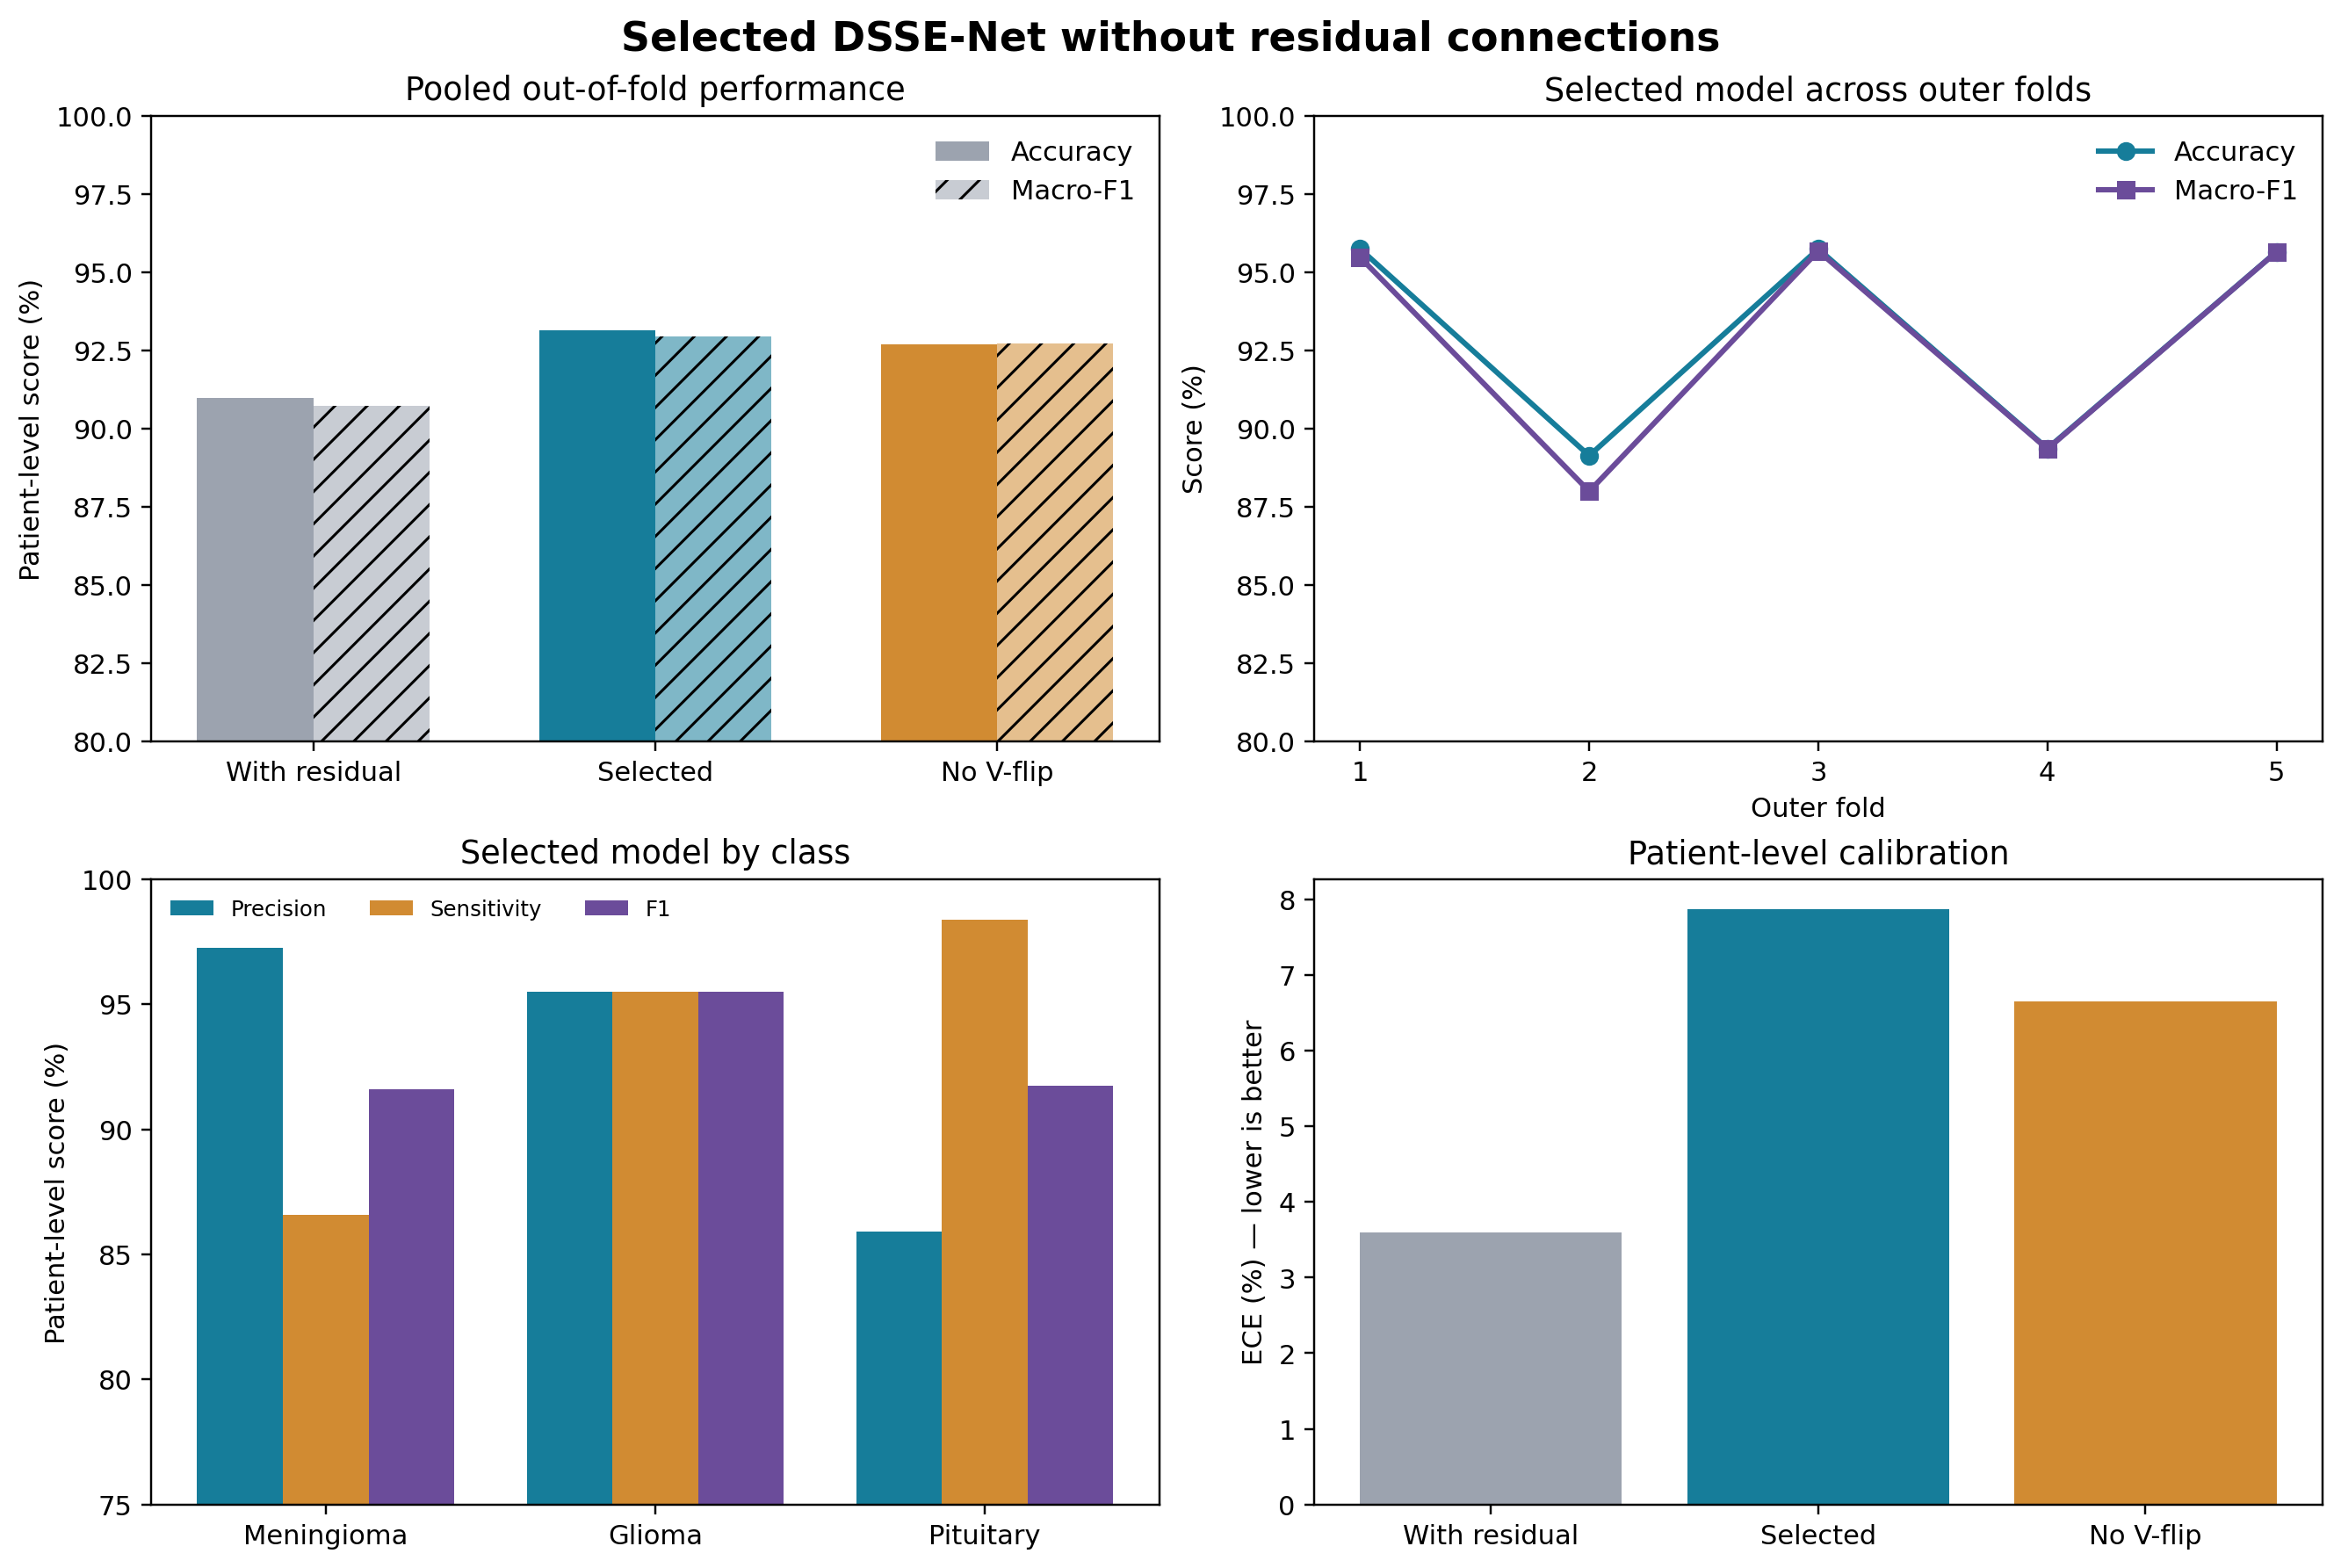

SELECTED MODEL VS BASELINES — EXACT PATIENT-LEVEL MCNEMAR + HOLM


,comparison,baseline_model,baseline_label,patients,both_correct,primary_correct_baseline_wrong,primary_wrong_baseline_correct,both_wrong,discordant_pairs,test,mcnemar_statistic,raw_p_value,holm_adjusted_p_value,significant_after_holm_0_05
0,without_residual_vs_resnet50,resnet50,ResNet-50,233,214,3,9,7,12,exact_two_sided_mcnemar,3.000000,0.145996,0.729980,False
1,without_residual_vs_densenet121,densenet121,DenseNet-121,233,212,5,10,6,15,exact_two_sided_mcnemar,5.000000,0.301758,1.000000,False
2,without_residual_vs_mobilenet_v3_large,mobilenet_v3_large,MobileNetV3-Large,233,211,6,9,7,15,exact_two_sided_mcnemar,6.000000,0.607239,1.000000,False
3,without_residual_vs_efficientnet_b0,efficientnet_b0,EfficientNet-B0,233,211,6,11,5,17,exact_two_sided_mcnemar,6.000000,0.332306,1.000000,False
4,without_residual_vs_regnet_y_400mf,regnet_y_400mf,RegNet-Y-400MF,233,212,5,8,8,13,exact_two_sided_mcnemar,5.000000,0.581055,1.000000,False


Saved: C:\Users\Alzubair\Desktop\newmodel1\SIVP\brain tumor\zubNet-A\nested_cv_baseline_results\split_baseline\tables\paired_patient_mcnemar_holm_vs_without_residual.csv


In [3]:
primary_report = load_primary_report(PROJECT_ROOT)

percentage_columns = [
    "patient_accuracy",
    "patient_balanced_accuracy",
    "patient_macro_f1",
    "patient_macro_auc",
    "patient_ece",
    "slice_accuracy",
    "slice_macro_f1",
    "fold_accuracy_sd",
]
display(
    primary_report["comparison"].style.format(
        {column: "{:.2%}" for column in percentage_columns}
    )
)

print("SELECTED MODEL — OUTER-FOLD PATIENT RESULTS")
display(
    primary_report["selected_folds"].style.format(
        {
            "accuracy": "{:.2%}",
            "balanced_accuracy": "{:.2%}",
            "macro_f1": "{:.2%}",
            "macro_roc_auc_ovr": "{:.2%}",
        }
    )
)

print("SELECTED MODEL — PATIENT-LEVEL CLASS RESULTS")
display(
    primary_report["per_class"].style.format(
        {
            "precision": "{:.2%}",
            "sensitivity_recall": "{:.2%}",
            "specificity": "{:.2%}",
            "f1_score": "{:.2%}",
            "roc_auc_ovr": "{:.2%}",
        }
    )
)

print("SELECTED MODEL — PATIENT-CLUSTER BOOTSTRAP 95% CI")
display(
    primary_report["confidence_intervals"].style.format(
        {"estimate": "{:.2%}", "lower": "{:.2%}", "upper": "{:.2%}"}
    )
)

primary_dashboard_path = plot_primary_dashboard(primary_report)
display(NotebookImage(filename=str(primary_dashboard_path)))

print("SELECTED MODEL VS BASELINES — EXACT PATIENT-LEVEL MCNEMAR + HOLM")
primary_mcnemar, primary_mcnemar_path = build_primary_baseline_mcnemar(
    PROJECT_ROOT
)
display(
    primary_mcnemar.style.format(
        {
            "raw_p_value": "{:.6f}",
            "holm_adjusted_p_value": "{:.6f}",
        }
    )
)
print(f"Saved: {primary_mcnemar_path}")

### Primary-model figures

![Selected model dashboard](nested_cv_ablation_results/split_ablation/without_residual/figures/primary_model_dashboard.png)

<table>
<tr>
<td><img src="nested_cv_ablation_results/split_ablation/without_residual/oof_evaluation/oof_patient_level_confusion_matrix.png" alt="Patient-level confusion matrix"></td>
<td><img src="nested_cv_ablation_results/split_ablation/without_residual/oof_evaluation/oof_patient_level_roc_curves.png" alt="Patient-level ROC curves"></td>
</tr>
</table>

## Grad-CAM for the selected without-residual model

Grad-CAM is included because interpretability is useful in medical-image classification and reviewers commonly expect evidence that predictions are not driven only by borders or preprocessing artifacts. The gallery uses one correctly classified out-of-fold slice per class, selected deterministically as the example nearest that class's median confidence—not the highest-confidence image. Each slice is explained by its matching locked outer-fold model and was not used to train that model.

Grad-CAM is qualitative supporting evidence, not a localization ground truth or proof of clinical causality. The target layer is the final depthwise convolution: `stage3[-1].dwconv[0]`.

,class_name,file_name,patient_id,outer_fold,image_path,predicted_class,confidence,selection_rule,target_layer
0,meningioma,102.mat,107494,4,nested_cv_cropped/outer_fold_4/test/meningioma...,meningioma,0.990528,correct OOF slice nearest class-median confidence,stage3[-1].dwconv[0]
1,glioma,2954.mat,MR051796,4,nested_cv_cropped/outer_fold_4/test/glioma/295...,glioma,0.997138,correct OOF slice nearest class-median confidence,stage3[-1].dwconv[0]
2,pituitary,1029.mat,101017,3,nested_cv_cropped/outer_fold_3/test/pituitary/...,pituitary,0.993143,correct OOF slice nearest class-median confidence,stage3[-1].dwconv[0]


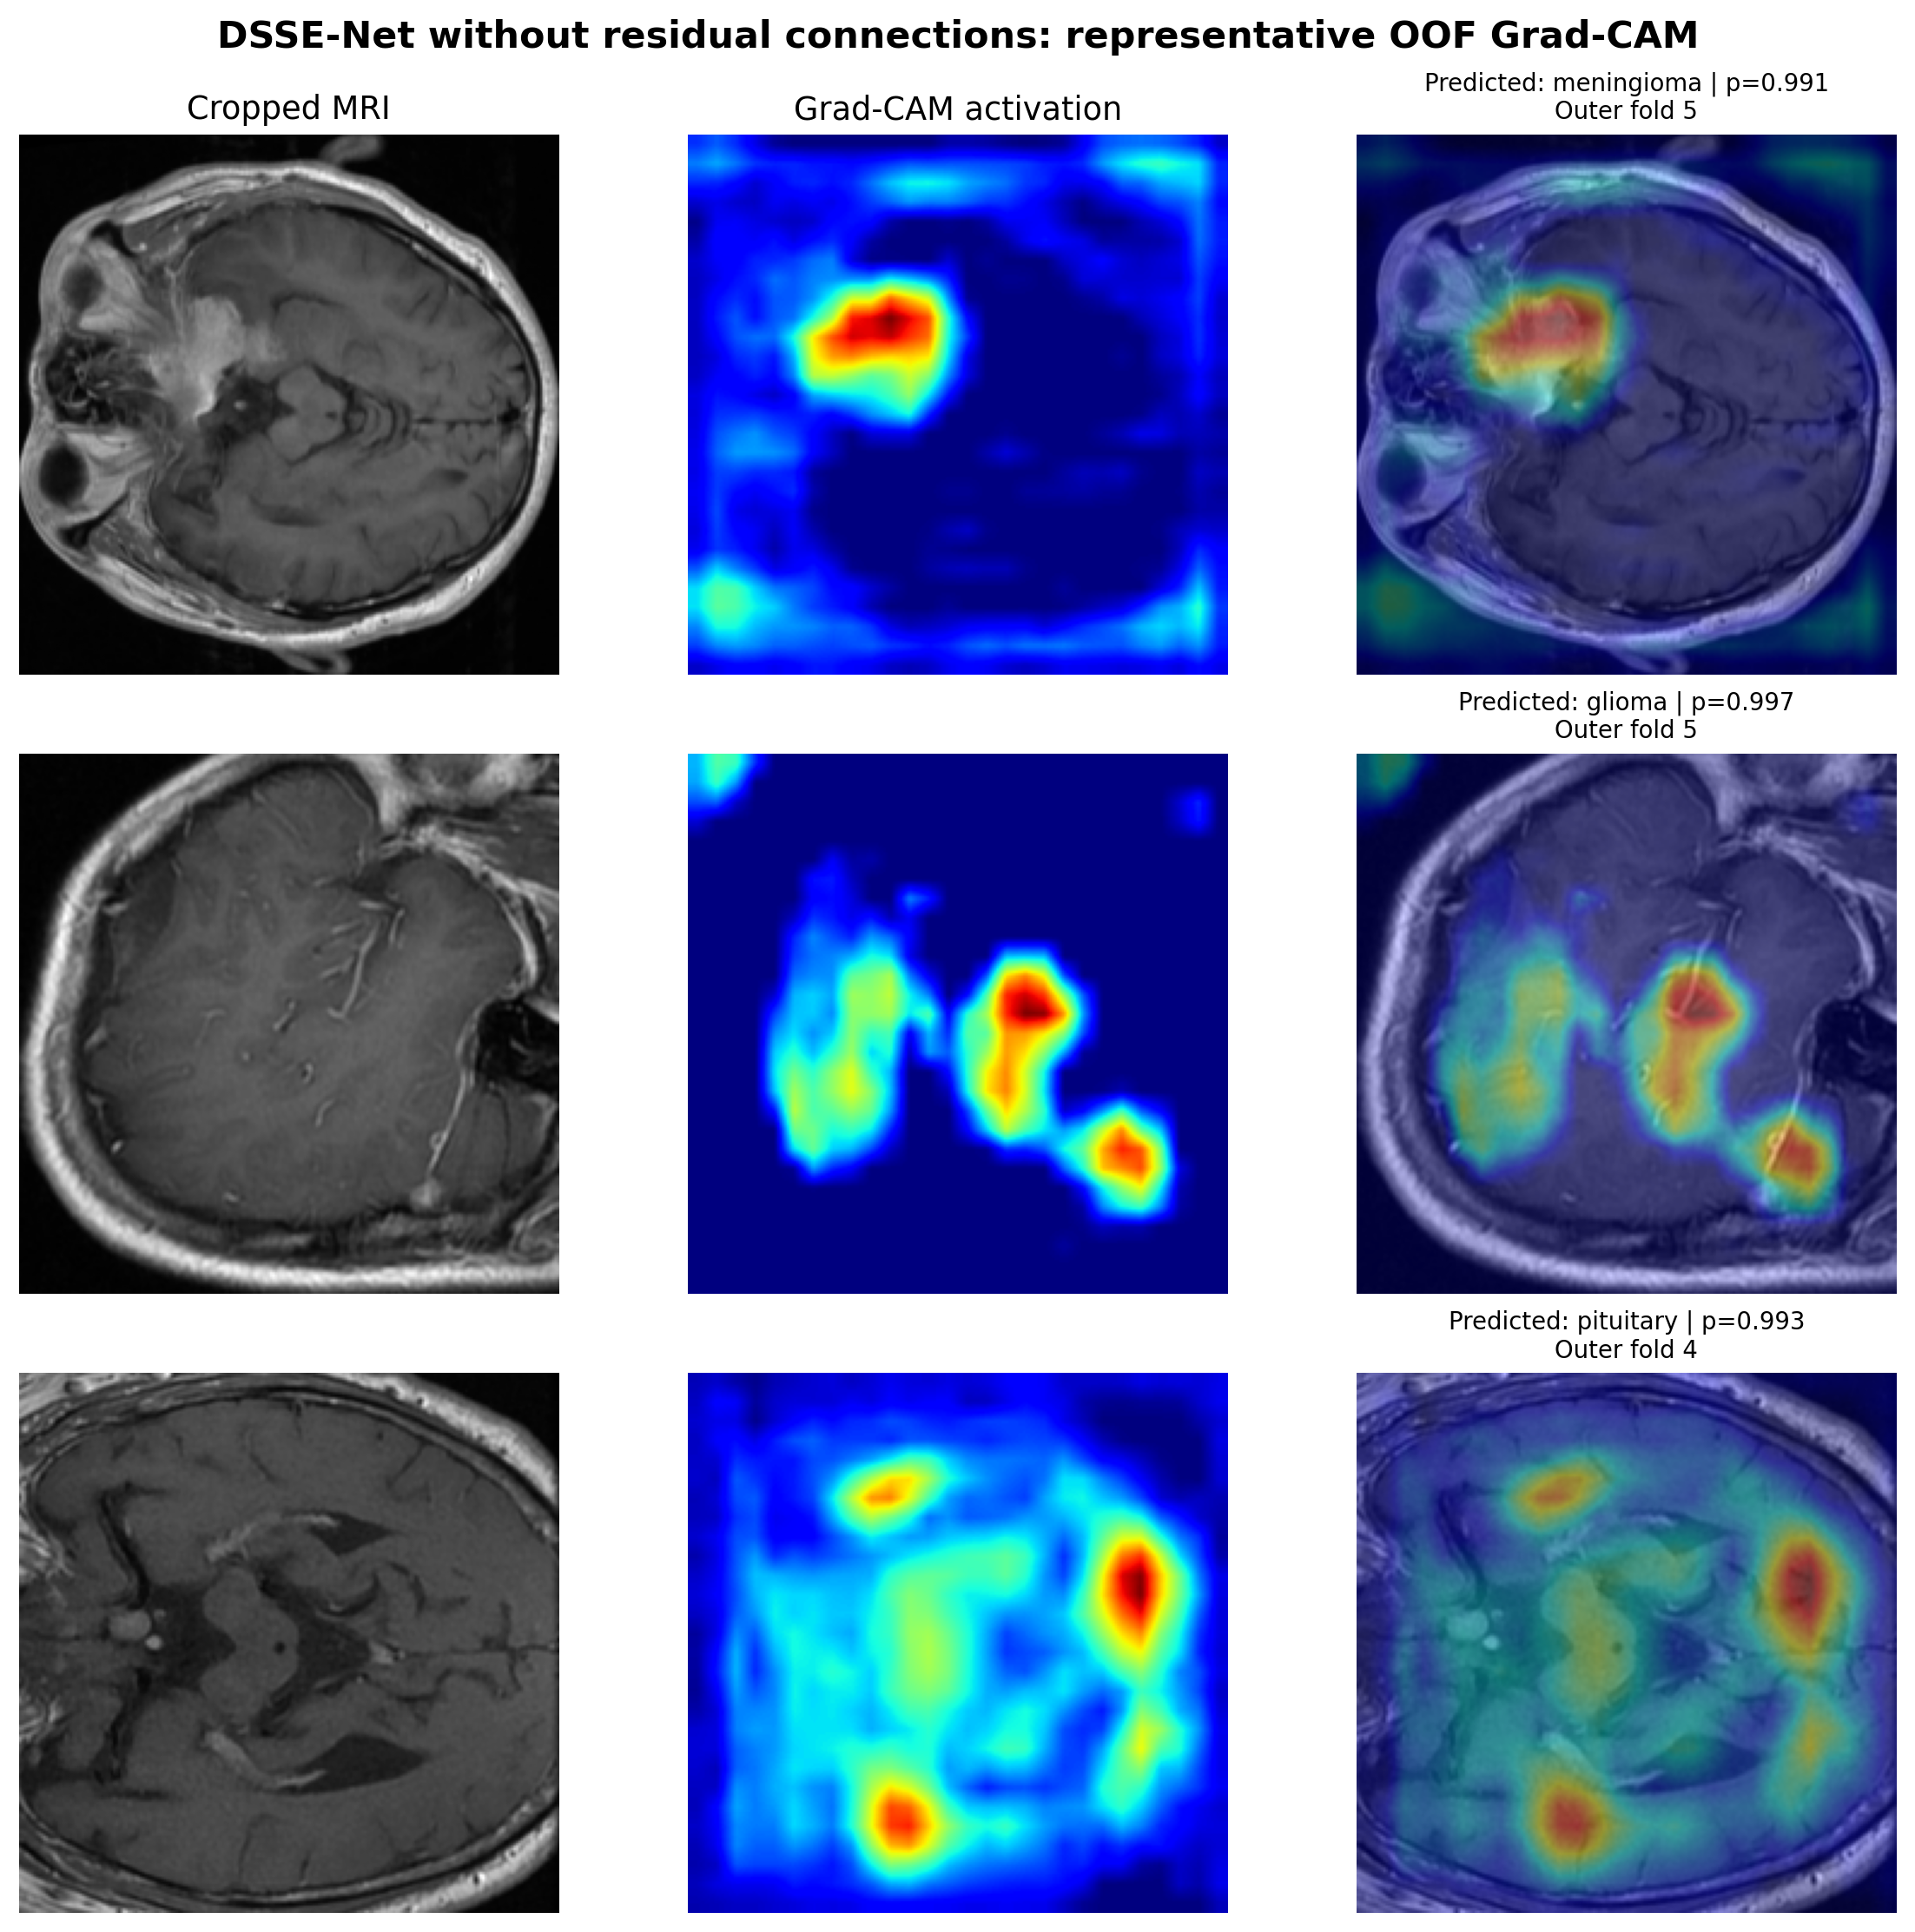

In [4]:
primary_gradcam = build_primary_gradcam_gallery(
    PROJECT_ROOT,
    overwrite=False,
    device=device,
)
display(primary_gradcam["selection"])
display(NotebookImage(filename=str(primary_gradcam["figure_path"])))

![Representative OOF Grad-CAM for DSSE-Net without residual connections](nested_cv_ablation_results/split_ablation/without_residual/figures/gradcam_representative_oof.png)

## 1. Decode the complete PID and read metadata

MATLAB stores each patient identifier as UTF-16 character codes. The previous expression `[0][0]` read only the first character; for example, `[49, 48, 48, 51, 54, 48]` must be decoded as `100360`.

In [7]:
def decode_matlab_char_array(raw: np.ndarray) -> str:
    values = np.asarray(raw).reshape(-1)
    if values.dtype.kind in {"u", "i"}:
        decoded = "".join(chr(int(code)) for code in values if int(code) != 0)
    elif values.dtype.kind in {"U", "S"}:
        decoded = "".join(
            item.decode("utf-8") if isinstance(item, bytes) else str(item)
            for item in values
        )
    else:
        raise TypeError(f"Unsupported MATLAB character dtype: {values.dtype}")

    decoded = decoded.strip().strip("\x00")
    if not decoded:
        raise ValueError("Encountered an empty patient identifier")
    return decoded


def read_mat_metadata(mat_path: Path) -> tuple[str, int]:
    with h5py.File(mat_path, "r") as mat_file:
        cjdata = mat_file["cjdata"]
        patient_id = decode_matlab_char_array(cjdata["PID"][()])
        raw_label = int(np.asarray(cjdata["label"][()]).squeeze())

    if raw_label not in RAW_LABEL_TO_CLASS:
        raise ValueError(f"Unexpected label {raw_label} in {mat_path.name}")
    return patient_id, raw_label

## 2. Build and validate slice/patient manifests

In [8]:
mat_paths = sorted(RAW_MAT_DIR.glob("*.mat"), key=lambda path: int(path.stem))
records: list[dict] = []

for mat_path in mat_paths:
    patient_id, raw_label = read_mat_metadata(mat_path)
    class_name = RAW_LABEL_TO_CLASS[raw_label]
    records.append(
        {
            "file_name": mat_path.name,
            "relative_path": mat_path.relative_to(PROJECT_ROOT).as_posix(),
            "patient_id": patient_id,
            "raw_label": raw_label,
            "class_name": class_name,
            "class_index": CLASS_TO_INDEX[class_name],
        }
    )

slice_manifest = pd.DataFrame.from_records(records)

assert len(slice_manifest) == EXPECTED_SLICES, (
    f"Expected {EXPECTED_SLICES} slices, found {len(slice_manifest)}"
)
assert not slice_manifest["file_name"].duplicated().any(), "Duplicate MAT filenames found"
assert not slice_manifest["relative_path"].duplicated().any(), "Duplicate MAT paths found"
assert not slice_manifest["patient_id"].isna().any(), "Missing patient IDs found"
assert slice_manifest["patient_id"].nunique() == EXPECTED_PATIENTS
assert Counter(slice_manifest["raw_label"]) == Counter(EXPECTED_IMAGE_COUNTS)

labels_per_patient = slice_manifest.groupby("patient_id")["raw_label"].nunique()
assert labels_per_patient.eq(1).all(), "At least one patient has multiple class labels"

patient_manifest = (
    slice_manifest.groupby("patient_id", as_index=False)
    .agg(
        raw_label=("raw_label", "first"),
        class_name=("class_name", "first"),
        class_index=("class_index", "first"),
        slice_count=("file_name", "size"),
    )
    .sort_values("patient_id")
    .reset_index(drop=True)
)

assert len(patient_manifest) == EXPECTED_PATIENTS
assert Counter(patient_manifest["raw_label"]) == Counter(EXPECTED_PATIENT_COUNTS)
assert int(patient_manifest["slice_count"].sum()) == EXPECTED_SLICES

print(f"Validated {len(slice_manifest)} slices from {len(patient_manifest)} unique patients.")
display(
    patient_manifest.groupby(["raw_label", "class_name"], as_index=False)
    .agg(patients=("patient_id", "nunique"), slices=("slice_count", "sum"))
)
display(slice_manifest.head())

Validated 3064 slices from 233 unique patients.


,raw_label,class_name,patients,slices
0,1,meningioma,82,708
1,2,glioma,89,1426
2,3,pituitary,62,930


,file_name,relative_path,patient_id,raw_label,class_name,class_index
0,1.mat,brainDataset/1.mat,100360,1,meningioma,0
1,2.mat,brainDataset/2.mat,100360,1,meningioma,0
2,3.mat,brainDataset/3.mat,100360,1,meningioma,0
3,4.mat,brainDataset/4.mat,100360,1,meningioma,0
4,5.mat,brainDataset/5.mat,100360,1,meningioma,0


## 3. Create five outer patient-level folds

Each patient is assigned to exactly one outer test fold. Across the five runs, every patient is internally tested once and is never present in the corresponding development set.

In [9]:
outer_assignment = patient_manifest.copy()
outer_assignment["outer_test_fold"] = -1
outer_membership_frames: list[pd.DataFrame] = []

outer_cv = StratifiedGroupKFold(
    n_splits=OUTER_FOLDS, shuffle=True, random_state=SEED
)
outer_X = np.zeros((len(patient_manifest), 1), dtype=np.uint8)

for outer_fold, (development_idx, test_idx) in enumerate(
    outer_cv.split(
        outer_X,
        y=patient_manifest["class_name"],
        groups=patient_manifest["patient_id"],
    )
):
    outer_assignment.loc[test_idx, "outer_test_fold"] = outer_fold

    development_rows = patient_manifest.iloc[development_idx].copy()
    development_rows.insert(0, "role", "development")
    development_rows.insert(0, "outer_fold", outer_fold)

    test_rows = patient_manifest.iloc[test_idx].copy()
    test_rows.insert(0, "role", "outer_test")
    test_rows.insert(0, "outer_fold", outer_fold)

    outer_membership_frames.extend([development_rows, test_rows])

outer_membership = pd.concat(outer_membership_frames, ignore_index=True)
outer_assignment["outer_test_fold"] = outer_assignment["outer_test_fold"].astype(int)
assert outer_assignment["outer_test_fold"].between(0, OUTER_FOLDS - 1).all()

## 4. Create five inner tuning folds inside each outer development set

The outer test patients are excluded before inner-fold generation. Model selection, early stopping, and hyperparameter tuning must use only `inner_train` and `inner_tune`.

In [10]:
inner_membership_frames: list[pd.DataFrame] = []

for outer_fold in range(OUTER_FOLDS):
    development = (
        outer_membership.query(
            "outer_fold == @outer_fold and role == 'development'"
        )
        .drop(columns=["outer_fold", "role"])
        .reset_index(drop=True)
    )

    inner_cv = StratifiedGroupKFold(
        n_splits=INNER_FOLDS,
        shuffle=True,
        random_state=SEED + 100 + outer_fold,
    )
    inner_X = np.zeros((len(development), 1), dtype=np.uint8)

    for inner_fold, (train_idx, tune_idx) in enumerate(
        inner_cv.split(
            inner_X,
            y=development["class_name"],
            groups=development["patient_id"],
        )
    ):
        train_rows = development.iloc[train_idx].copy()
        train_rows.insert(0, "role", "inner_train")
        train_rows.insert(0, "inner_fold", inner_fold)
        train_rows.insert(0, "outer_fold", outer_fold)

        tune_rows = development.iloc[tune_idx].copy()
        tune_rows.insert(0, "role", "inner_tune")
        tune_rows.insert(0, "inner_fold", inner_fold)
        tune_rows.insert(0, "outer_fold", outer_fold)

        inner_membership_frames.extend([train_rows, tune_rows])

inner_membership = pd.concat(inner_membership_frames, ignore_index=True)

## 5. Leakage and coverage tests

In [11]:
all_patients = set(patient_manifest["patient_id"])
outer_test_frequency = Counter()

for outer_fold in range(OUTER_FOLDS):
    fold_rows = outer_membership.query("outer_fold == @outer_fold")
    development_patients = set(
        fold_rows.query("role == 'development'")["patient_id"]
    )
    test_patients = set(fold_rows.query("role == 'outer_test'")["patient_id"])

    assert development_patients.isdisjoint(test_patients)
    assert development_patients | test_patients == all_patients
    assert set(fold_rows.query("role == 'outer_test'")["class_name"]) == set(
        RAW_LABEL_TO_CLASS.values()
    )
    outer_test_frequency.update(test_patients)

    tuning_frequency = Counter()
    for inner_fold in range(INNER_FOLDS):
        inner_rows = inner_membership.query(
            "outer_fold == @outer_fold and inner_fold == @inner_fold"
        )
        inner_train_patients = set(
            inner_rows.query("role == 'inner_train'")["patient_id"]
        )
        inner_tune_patients = set(
            inner_rows.query("role == 'inner_tune'")["patient_id"]
        )

        assert inner_train_patients.isdisjoint(inner_tune_patients)
        assert inner_train_patients | inner_tune_patients == development_patients
        assert (inner_train_patients | inner_tune_patients).isdisjoint(test_patients)
        assert set(inner_rows.query("role == 'inner_tune'")["class_name"]) == set(
            RAW_LABEL_TO_CLASS.values()
        )
        tuning_frequency.update(inner_tune_patients)

    assert set(tuning_frequency) == development_patients
    assert set(tuning_frequency.values()) == {1}

assert set(outer_test_frequency) == all_patients
assert set(outer_test_frequency.values()) == {1}

print("All leakage, coverage, label, and fold-integrity tests passed.")

All leakage, coverage, label, and fold-integrity tests passed.


## 6. Summarize and save reproducible assignments

In [12]:
outer_summary = (
    outer_membership.groupby(["outer_fold", "role", "class_name"], as_index=False)
    .agg(patients=("patient_id", "nunique"), slices=("slice_count", "sum"))
    .sort_values(["outer_fold", "role", "class_name"])
)
inner_summary = (
    inner_membership.groupby(
        ["outer_fold", "inner_fold", "role", "class_name"], as_index=False
    )
    .agg(patients=("patient_id", "nunique"), slices=("slice_count", "sum"))
    .sort_values(["outer_fold", "inner_fold", "role", "class_name"])
)

slice_manifest.to_csv(OUTPUT_DIR / "slice_manifest.csv", index=False)
patient_manifest.to_csv(OUTPUT_DIR / "patient_manifest.csv", index=False)
outer_assignment.to_csv(OUTPUT_DIR / "outer_fold_assignment.csv", index=False)
outer_membership.to_csv(OUTPUT_DIR / "outer_split_membership.csv", index=False)
inner_membership.to_csv(OUTPUT_DIR / "inner_split_membership.csv", index=False)
outer_summary.to_csv(OUTPUT_DIR / "outer_fold_summary.csv", index=False)
inner_summary.to_csv(OUTPUT_DIR / "inner_fold_summary.csv", index=False)

assignment_bytes = (
    outer_assignment.sort_values("patient_id").to_csv(index=False).encode("utf-8")
    + inner_membership.sort_values(
        ["outer_fold", "inner_fold", "role", "patient_id"]
    ).to_csv(index=False).encode("utf-8")
)
split_sha256 = sha256(assignment_bytes).hexdigest()

split_config = {
    "protocol": "nested_stratified_patient_level_cross_validation",
    "seed": SEED,
    "outer_folds": OUTER_FOLDS,
    "inner_folds": INNER_FOLDS,
    "raw_label_to_class": RAW_LABEL_TO_CLASS,
    "class_to_index": CLASS_TO_INDEX,
    "slice_count": int(len(slice_manifest)),
    "patient_count": int(len(patient_manifest)),
    "assignment_sha256": split_sha256,
    "versions": {
        "python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "h5py": h5py.__version__,
        "scikit_learn": sklearn.__version__,
    },
}
with (OUTPUT_DIR / "split_config.json").open("w", encoding="utf-8") as file:
    json.dump(split_config, file, indent=2, sort_keys=True)

display(outer_summary)
print(f"Assignment SHA-256: {split_sha256}")
print(f"Saved nested-CV artifacts to: {OUTPUT_DIR}")

,outer_fold,role,class_name,patients,slices
0,0,development,glioma,72,1129
1,0,development,meningioma,64,496
2,0,development,pituitary,50,759
3,0,outer_test,glioma,17,297
4,0,outer_test,meningioma,18,212
5,0,outer_test,pituitary,12,171
6,1,development,glioma,72,1198
7,1,development,meningioma,63,595
8,1,development,pituitary,52,771
9,1,outer_test,glioma,17,228


Assignment SHA-256: 116d4ba2022389afc80739a616477c31f8c2a2e10356077494d823c641bb462e
Saved nested-CV artifacts to: C:\Users\Alzubair\Desktop\newmodel1\SIVP\brain tumor\zubNet-A\nested_cv_artifacts


## 7. Export PNG images and materialize the nested-CV folders

Each MAT image is normalized to 8-bit PNG once under `nested_cv_images/all_images`. Folder views are then created with the familiar `train`, `validation`, and `test` names. Hard links are used when supported, so all folds behave like ordinary image folders without storing dozens of physical copies.

Important: treat `nested_cv_images` as a read-only source. Cropping and all other preprocessing must write to a different root such as `nested_cv_cropped`; never overwrite these linked files in place.

In [13]:
def normalize_to_uint8(image: np.ndarray) -> np.ndarray:
    image = np.asarray(image, dtype=np.float32).squeeze()
    if image.ndim != 2:
        raise ValueError(f"Expected a 2D MRI slice, received shape {image.shape}")
    minimum = float(image.min())
    maximum = float(image.max())
    if not np.isfinite(minimum) or not np.isfinite(maximum) or maximum <= minimum:
        raise ValueError("MRI slice has an invalid or constant intensity range")
    normalized = (image - minimum) / (maximum - minimum)
    return np.rint(normalized * 255.0).astype(np.uint8)


def export_canonical_png(row: object) -> Path:
    mat_path = PROJECT_ROOT / row.relative_path
    png_path = CANONICAL_IMAGE_ROOT / row.class_name / Path(row.file_name).with_suffix(".png")
    png_path.parent.mkdir(parents=True, exist_ok=True)

    if png_path.exists():
        existing = cv2.imread(str(png_path), cv2.IMREAD_GRAYSCALE)
        if existing is None or existing.size == 0:
            raise RuntimeError(f"Existing PNG is unreadable: {png_path}")
        return png_path

    with h5py.File(mat_path, "r") as mat_file:
        image = normalize_to_uint8(mat_file["cjdata"]["image"][()])

    if not cv2.imwrite(str(png_path), image):
        raise OSError(f"Failed to write {png_path}")
    return png_path


CANONICAL_IMAGE_ROOT.mkdir(parents=True, exist_ok=True)
png_paths: list[Path] = []
for row in slice_manifest.itertuples(index=False):
    png_paths.append(export_canonical_png(row))

slice_manifest["png_relative_path"] = [
    path.relative_to(PROJECT_ROOT).as_posix() for path in png_paths
]
slice_manifest.to_csv(OUTPUT_DIR / "slice_manifest.csv", index=False)

canonical_counts = {
    class_name: len(list((CANONICAL_IMAGE_ROOT / class_name).glob("*.png")))
    for class_name in CLASS_TO_INDEX
}
expected_canonical_counts = {
    RAW_LABEL_TO_CLASS[label]: count for label, count in EXPECTED_IMAGE_COUNTS.items()
}
assert canonical_counts == expected_canonical_counts, (
    canonical_counts, expected_canonical_counts
)
print(f"Canonical PNG cache verified: {sum(canonical_counts.values())} images")


def link_or_copy(source: Path, destination: Path) -> str:
    destination.parent.mkdir(parents=True, exist_ok=True)
    if destination.exists():
        if source.stat().st_size != destination.stat().st_size:
            raise RuntimeError(f"Conflicting existing file: {destination}")
        return "existing"
    try:
        os.link(source, destination)
        return "hardlink"
    except OSError:
        shutil.copy2(source, destination)
        return "copy"


def materialize_patient_view(patient_ids: set[str], destination_root: Path) -> Counter:
    selected = slice_manifest[slice_manifest["patient_id"].isin(patient_ids)]
    methods: Counter = Counter()
    for row in selected.itertuples(index=False):
        source = PROJECT_ROOT / row.png_relative_path
        destination = destination_root / row.class_name / source.name
        methods[link_or_copy(source, destination)] += 1
    return methods


def count_png_files(root: Path) -> int:
    return sum(1 for _ in root.rglob("*.png"))


IMAGE_ROOT.mkdir(parents=True, exist_ok=True)
assignment_marker = IMAGE_ROOT / "split_assignment_sha256.txt"
if assignment_marker.exists():
    existing_sha256 = assignment_marker.read_text(encoding="utf-8").strip()
    if existing_sha256 != split_sha256:
        raise RuntimeError(
            "The image folders belong to a different split. Use a new IMAGE_ROOT "
            "or remove the old folders intentionally before rebuilding."
        )
else:
    assignment_marker.write_text(split_sha256 + "\n", encoding="utf-8")

link_methods: Counter = Counter()
materialization_rows: list[dict] = []

for outer_fold in range(OUTER_FOLDS):
    selected_outer = outer_membership.query("outer_fold == @outer_fold")
    outer_train_patients = set(
        selected_outer.query("role == 'development'")["patient_id"]
    )
    outer_test_patients = set(
        selected_outer.query("role == 'outer_test'")["patient_id"]
    )
    outer_root = IMAGE_ROOT / f"outer_fold_{outer_fold}"

    for split_name, patient_ids in (
        ("train", outer_train_patients),
        ("test", outer_test_patients),
    ):
        destination = outer_root / split_name
        link_methods.update(materialize_patient_view(patient_ids, destination))
        expected = int(
            slice_manifest["patient_id"].isin(patient_ids).sum()
        )
        actual = count_png_files(destination)
        assert actual == expected, (destination, actual, expected)
        materialization_rows.append(
            {
                "outer_fold": outer_fold,
                "inner_fold": pd.NA,
                "split": split_name,
                "patients": len(patient_ids),
                "images": actual,
                "path": destination.relative_to(PROJECT_ROOT).as_posix(),
            }
        )

    for inner_fold in range(INNER_FOLDS):
        selected_inner = inner_membership.query(
            "outer_fold == @outer_fold and inner_fold == @inner_fold"
        )
        inner_train_patients = set(
            selected_inner.query("role == 'inner_train'")["patient_id"]
        )
        inner_tune_patients = set(
            selected_inner.query("role == 'inner_tune'")["patient_id"]
        )
        inner_root = outer_root / "inner_folds" / f"inner_fold_{inner_fold}"

        for split_name, patient_ids in (
            ("train", inner_train_patients),
            ("validation", inner_tune_patients),
        ):
            destination = inner_root / split_name
            link_methods.update(materialize_patient_view(patient_ids, destination))
            expected = int(
                slice_manifest["patient_id"].isin(patient_ids).sum()
            )
            actual = count_png_files(destination)
            assert actual == expected, (destination, actual, expected)
            materialization_rows.append(
                {
                    "outer_fold": outer_fold,
                    "inner_fold": inner_fold,
                    "split": split_name,
                    "patients": len(patient_ids),
                    "images": actual,
                    "path": destination.relative_to(PROJECT_ROOT).as_posix(),
                }
            )

image_folder_summary = pd.DataFrame(materialization_rows)
image_folder_summary.to_csv(OUTPUT_DIR / "image_folder_summary.csv", index=False)

split_config["canonical_image_root"] = CANONICAL_IMAGE_ROOT.relative_to(PROJECT_ROOT).as_posix()
split_config["fold_image_root"] = IMAGE_ROOT.relative_to(PROJECT_ROOT).as_posix()
split_config["folder_materialization"] = "hardlink_with_copy_fallback"
with (OUTPUT_DIR / "split_config.json").open("w", encoding="utf-8") as file:
    json.dump(split_config, file, indent=2, sort_keys=True)

print(f"Folder entries: {sum(link_methods.values())} -> {dict(link_methods)}")
print(f"Verified {len(image_folder_summary)} train/validation/test folder views.")
display(image_folder_summary.head(12))

Canonical PNG cache verified: 3064 images
Folder entries: 76600 -> {'existing': 76600}
Verified 60 train/validation/test folder views.


,outer_fold,inner_fold,split,patients,images,path
0,0,<NA>,train,186,2384,nested_cv_images/outer_fold_0/train
1,0,<NA>,test,47,680,nested_cv_images/outer_fold_0/test
2,0,0,train,149,1905,nested_cv_images/outer_fold_0/inner_folds/inne...
3,0,0,validation,37,479,nested_cv_images/outer_fold_0/inner_folds/inne...
4,0,1,train,149,1926,nested_cv_images/outer_fold_0/inner_folds/inne...
5,0,1,validation,37,458,nested_cv_images/outer_fold_0/inner_folds/inne...
6,0,2,train,149,1905,nested_cv_images/outer_fold_0/inner_folds/inne...
7,0,2,validation,37,479,nested_cv_images/outer_fold_0/inner_folds/inne...
8,0,3,train,149,1949,nested_cv_images/outer_fold_0/inner_folds/inne...
9,0,3,validation,37,435,nested_cv_images/outer_fold_0/inner_folds/inne...


## 8. Apply manual image quality control and rebuild patient-level folds

Images manually removed from nested_cv_cropped/all_images are recorded as quality-control exclusions. The active slice and patient manifests are then rebuilt, followed by fresh nested stratified patient-level folds. This cell must run before the final cropped fold folders are materialized.

In [14]:
MANUAL_EXCLUSIONS_PATH = OUTPUT_DIR / "manual_quality_exclusions.csv"
PRE_QC_MANIFEST_PATH = OUTPUT_DIR / "slice_manifest_before_manual_qc.csv"
QC_MANIFEST_PATH = OUTPUT_DIR / "quality_control_manifest.csv"

pre_qc_slice_manifest = slice_manifest.copy()
pre_qc_slice_manifest["cropped_relative_path"] = pre_qc_slice_manifest.apply(
    lambda row: (
        CROPPED_CANONICAL_ROOT
        / row["class_name"]
        / Path(row["file_name"]).with_suffix(".png")
    ).relative_to(PROJECT_ROOT).as_posix(),
    axis=1,
)
assert len(pre_qc_slice_manifest) == EXPECTED_SLICES
assert pre_qc_slice_manifest["file_name"].is_unique
pre_qc_slice_manifest.to_csv(PRE_QC_MANIFEST_PATH, index=False)

expected_relative_paths = set(pre_qc_slice_manifest["cropped_relative_path"])
actual_relative_paths = {
    path.relative_to(PROJECT_ROOT).as_posix()
    for path in CROPPED_CANONICAL_ROOT.glob("*/*.png")
}
unexpected_paths = sorted(actual_relative_paths - expected_relative_paths)
if unexpected_paths:
    raise RuntimeError(
        f"Found {len(unexpected_paths)} unexpected PNG files under all_images; "
        f"first entries: {unexpected_paths[:10]}"
    )

missing_relative_paths = expected_relative_paths - actual_relative_paths
missing_file_names = {Path(path).with_suffix(".mat").name for path in missing_relative_paths}

previously_excluded_file_names: set[str] = set()
if MANUAL_EXCLUSIONS_PATH.exists():
    previous_exclusions = pd.read_csv(
        MANUAL_EXCLUSIONS_PATH, dtype={"patient_id": str}
    )
    previously_excluded_file_names = set(previous_exclusions["file_name"])

manual_excluded_file_names = missing_file_names | previously_excluded_file_names
unknown_exclusions = manual_excluded_file_names - set(pre_qc_slice_manifest["file_name"])
assert not unknown_exclusions, sorted(unknown_exclusions)

manual_exclusions = pre_qc_slice_manifest[
    pre_qc_slice_manifest["file_name"].isin(manual_excluded_file_names)
].copy()
manual_exclusions["exclusion_reason"] = "manual_visual_quality_control"
manual_exclusions["file_number"] = manual_exclusions["file_name"].map(
    lambda name: int(Path(name).stem)
)
manual_exclusions = manual_exclusions.sort_values("file_number").drop(
    columns="file_number"
)
manual_exclusions.to_csv(MANUAL_EXCLUSIONS_PATH, index=False)

quality_control_manifest = pre_qc_slice_manifest.copy()
quality_control_manifest["quality_control_status"] = np.where(
    quality_control_manifest["file_name"].isin(manual_excluded_file_names),
    "excluded_manual_visual_qc",
    "included",
)
quality_control_manifest.to_csv(QC_MANIFEST_PATH, index=False)

slice_manifest = quality_control_manifest.query(
    "quality_control_status == 'included'"
).drop(columns="quality_control_status").reset_index(drop=True)
assert len(slice_manifest) + len(manual_exclusions) == EXPECTED_SLICES
assert slice_manifest["file_name"].is_unique
assert all((PROJECT_ROOT / path).is_file() for path in slice_manifest["cropped_relative_path"])

patient_label_counts = slice_manifest.groupby("patient_id")["class_name"].nunique()
assert patient_label_counts.eq(1).all(), "A patient has more than one class label"
patient_manifest = (
    slice_manifest.groupby(
        ["patient_id", "raw_label", "class_name", "class_index"],
        as_index=False,
    )
    .agg(slice_count=("file_name", "size"))
    .sort_values("patient_id")
    .reset_index(drop=True)
)
if patient_manifest.groupby("class_name").size().min() < max(OUTER_FOLDS, INNER_FOLDS):
    raise RuntimeError("Too few patients in a class for five-fold stratification")

outer_assignment = patient_manifest.copy()
outer_assignment["outer_test_fold"] = -1
outer_membership_frames = []
outer_cv = StratifiedGroupKFold(
    n_splits=OUTER_FOLDS, shuffle=True, random_state=SEED
)
outer_X = np.zeros((len(patient_manifest), 1), dtype=np.uint8)
for outer_fold, (development_idx, test_idx) in enumerate(
    outer_cv.split(
        outer_X,
        y=patient_manifest["class_name"],
        groups=patient_manifest["patient_id"],
    )
):
    outer_assignment.loc[test_idx, "outer_test_fold"] = outer_fold
    development_rows = patient_manifest.iloc[development_idx].copy()
    development_rows.insert(0, "role", "development")
    development_rows.insert(0, "outer_fold", outer_fold)
    test_rows = patient_manifest.iloc[test_idx].copy()
    test_rows.insert(0, "role", "outer_test")
    test_rows.insert(0, "outer_fold", outer_fold)
    outer_membership_frames.extend([development_rows, test_rows])

outer_membership = pd.concat(outer_membership_frames, ignore_index=True)
outer_assignment["outer_test_fold"] = outer_assignment["outer_test_fold"].astype(int)
assert outer_assignment["outer_test_fold"].between(0, OUTER_FOLDS - 1).all()

inner_membership_frames = []
for outer_fold in range(OUTER_FOLDS):
    development = (
        outer_membership.query(
            "outer_fold == @outer_fold and role == 'development'"
        )
        .drop(columns=["outer_fold", "role"])
        .reset_index(drop=True)
    )
    inner_cv = StratifiedGroupKFold(
        n_splits=INNER_FOLDS,
        shuffle=True,
        random_state=SEED + 100 + outer_fold,
    )
    inner_X = np.zeros((len(development), 1), dtype=np.uint8)
    for inner_fold, (train_idx, tune_idx) in enumerate(
        inner_cv.split(
            inner_X,
            y=development["class_name"],
            groups=development["patient_id"],
        )
    ):
        train_rows = development.iloc[train_idx].copy()
        train_rows.insert(0, "role", "inner_train")
        train_rows.insert(0, "inner_fold", inner_fold)
        train_rows.insert(0, "outer_fold", outer_fold)
        tune_rows = development.iloc[tune_idx].copy()
        tune_rows.insert(0, "role", "inner_tune")
        tune_rows.insert(0, "inner_fold", inner_fold)
        tune_rows.insert(0, "outer_fold", outer_fold)
        inner_membership_frames.extend([train_rows, tune_rows])

inner_membership = pd.concat(inner_membership_frames, ignore_index=True)
all_patients = set(patient_manifest["patient_id"])
outer_test_frequency = Counter()
for outer_fold in range(OUTER_FOLDS):
    selected_outer = outer_membership.query("outer_fold == @outer_fold")
    development_patients = set(
        selected_outer.query("role == 'development'")["patient_id"]
    )
    test_patients = set(
        selected_outer.query("role == 'outer_test'")["patient_id"]
    )
    assert development_patients.isdisjoint(test_patients)
    assert development_patients | test_patients == all_patients
    outer_test_frequency.update(test_patients)
    for inner_fold in range(INNER_FOLDS):
        selected_inner = inner_membership.query(
            "outer_fold == @outer_fold and inner_fold == @inner_fold"
        )
        train_patients = set(
            selected_inner.query("role == 'inner_train'")["patient_id"]
        )
        tune_patients = set(
            selected_inner.query("role == 'inner_tune'")["patient_id"]
        )
        assert train_patients.isdisjoint(tune_patients)
        assert train_patients | tune_patients == development_patients
        assert train_patients.isdisjoint(test_patients)
        assert tune_patients.isdisjoint(test_patients)
assert set(outer_test_frequency) == all_patients
assert set(outer_test_frequency.values()) == {1}

outer_summary = (
    outer_membership.groupby(["outer_fold", "role", "class_name"], as_index=False)
    .agg(patients=("patient_id", "nunique"), slices=("slice_count", "sum"))
    .sort_values(["outer_fold", "role", "class_name"])
)
inner_summary = (
    inner_membership.groupby(
        ["outer_fold", "inner_fold", "role", "class_name"],
        as_index=False,
    )
    .agg(patients=("patient_id", "nunique"), slices=("slice_count", "sum"))
    .sort_values(["outer_fold", "inner_fold", "role", "class_name"])
)

slice_manifest.to_csv(OUTPUT_DIR / "slice_manifest.csv", index=False)
patient_manifest.to_csv(OUTPUT_DIR / "patient_manifest.csv", index=False)
outer_assignment.to_csv(OUTPUT_DIR / "outer_fold_assignment.csv", index=False)
outer_membership.to_csv(OUTPUT_DIR / "outer_split_membership.csv", index=False)
inner_membership.to_csv(OUTPUT_DIR / "inner_split_membership.csv", index=False)
outer_summary.to_csv(OUTPUT_DIR / "outer_fold_summary.csv", index=False)
inner_summary.to_csv(OUTPUT_DIR / "inner_fold_summary.csv", index=False)

assignment_bytes = (
    outer_assignment.sort_values("patient_id").to_csv(index=False).encode("utf-8")
    + inner_membership.sort_values(
        ["outer_fold", "inner_fold", "role", "patient_id"]
    ).to_csv(index=False).encode("utf-8")
)
split_sha256 = sha256(assignment_bytes).hexdigest()
split_config = {
    "protocol": "nested_stratified_patient_level_cross_validation_after_manual_qc",
    "seed": SEED,
    "outer_folds": OUTER_FOLDS,
    "inner_folds": INNER_FOLDS,
    "raw_label_to_class": RAW_LABEL_TO_CLASS,
    "class_to_index": CLASS_TO_INDEX,
    "pre_qc_slice_count": int(len(pre_qc_slice_manifest)),
    "manual_quality_exclusions": int(len(manual_exclusions)),
    "slice_count": int(len(slice_manifest)),
    "patient_count": int(len(patient_manifest)),
    "assignment_sha256": split_sha256,
    "quality_control_manifest": QC_MANIFEST_PATH.name,
    "manual_exclusions_manifest": MANUAL_EXCLUSIONS_PATH.name,
    "versions": {
        "python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "h5py": h5py.__version__,
        "scikit_learn": sklearn.__version__,
    },
}
with (OUTPUT_DIR / "split_config.json").open("w", encoding="utf-8") as file:
    json.dump(split_config, file, indent=2, sort_keys=True)

qc_summary = quality_control_manifest.groupby(
    ["quality_control_status", "class_name"], as_index=False
).agg(images=("file_name", "size"), patients=("patient_id", "nunique"))
display(qc_summary)
print(f"Manual QC exclusions: {len(manual_exclusions)}")
print(f"Active dataset: {len(slice_manifest)} images from {len(patient_manifest)} patients")
print(f"Post-QC assignment SHA-256: {split_sha256}")
print("All post-QC patient leakage and coverage tests passed.")

,quality_control_status,class_name,images,patients
0,excluded_manual_visual_qc,glioma,116,42
1,excluded_manual_visual_qc,meningioma,7,7
2,excluded_manual_visual_qc,pituitary,10,7
3,included,glioma,1310,89
4,included,meningioma,701,82
5,included,pituitary,920,62


Manual QC exclusions: 133
Active dataset: 2931 images from 233 patients
Post-QC assignment SHA-256: 554d062a5bd78bc4c2e014e2d53f44d4f5aeb243d2a52a61302bdb90a75d8ea3
All post-QC patient leakage and coverage tests passed.


## 9. Validate the final cropped images and materialize post-QC folds

The manually reviewed images in nested_cv_cropped/all_images are treated as the final canonical cropped dataset. This stage does not recrop, replace, or resize them; it validates that every included image is readable, records its final dimensions, and materializes the nested-CV folder views using the post-QC patient assignments.

Final manually reviewed cropped dataset verified: 2931 active images {'meningioma': 701, 'glioma': 1310, 'pituitary': 920}


,class_name,status,images,mean_width,mean_height,mean_retained_area
0,glioma,ok,1310,318.890076,334.808397,0.411832
1,meningioma,ok,701,315.653352,333.302425,0.405922
2,pituitary,ok,920,335.221739,370.720652,0.487026


Cropped folder entries: 73275 -> {'existing': 73275}
Verified 60 cropped folder views.


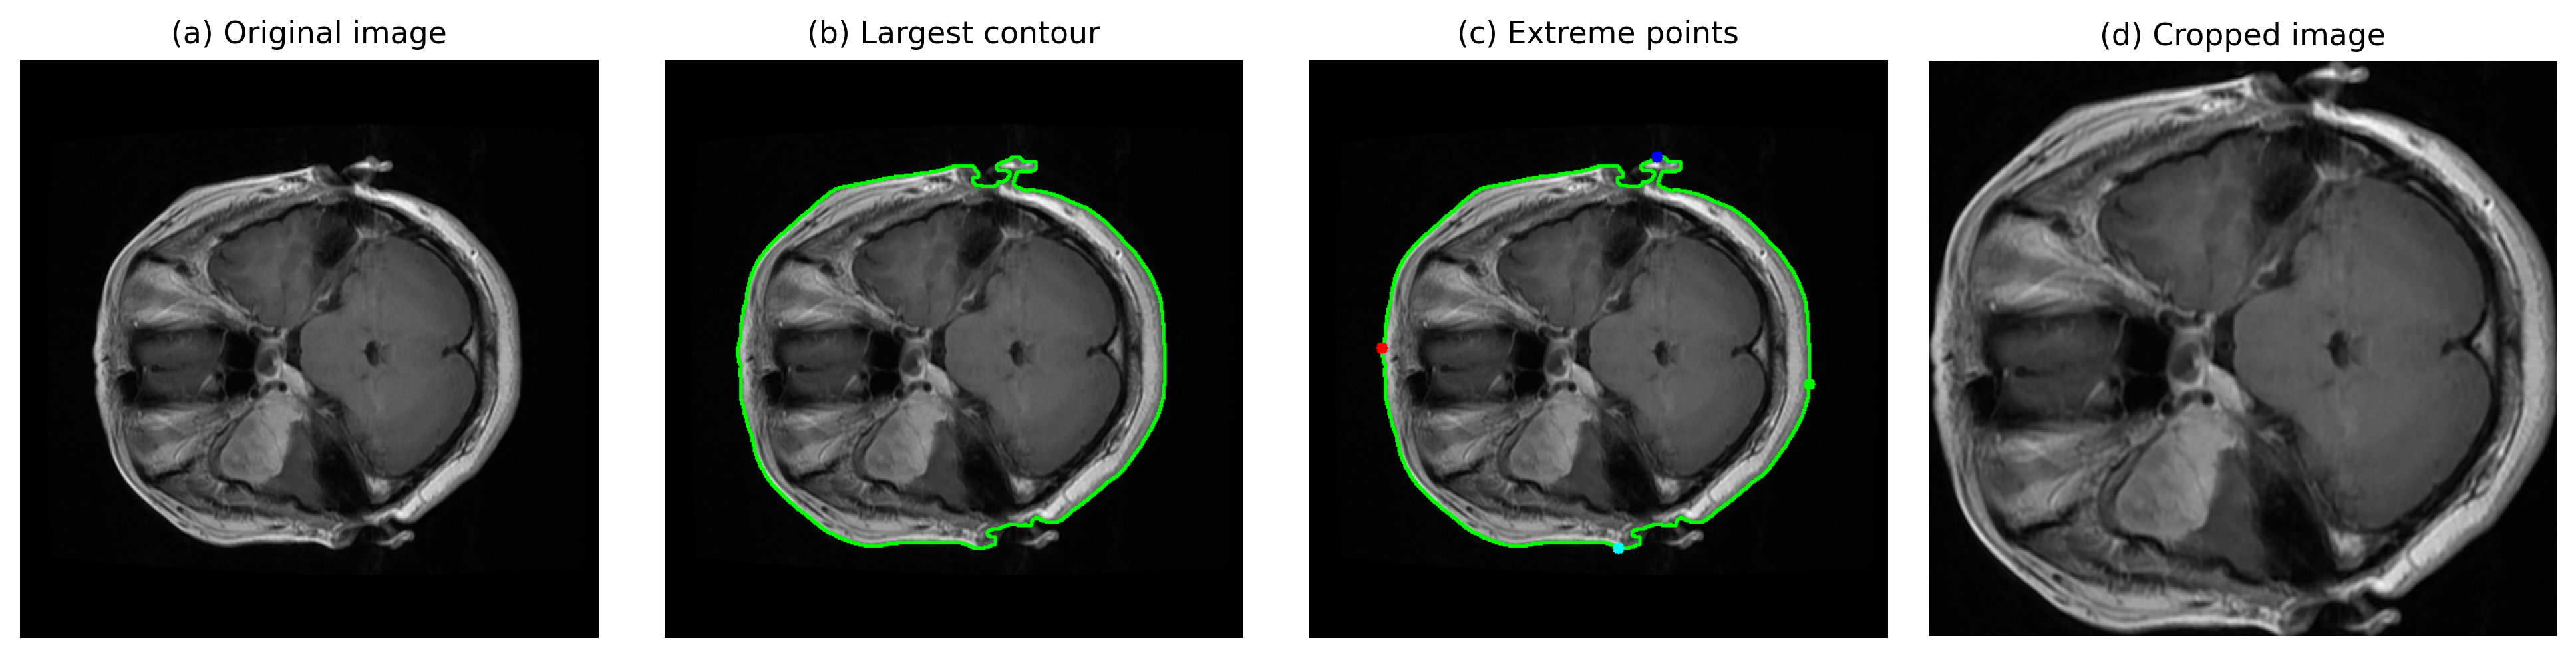

Saved cropping preview to: C:\Users\Alzubair\Desktop\newmodel1\SIVP\brain tumor\zubNet-A\nested_cv_artifacts\cropping_pipeline_preview.png


In [15]:
CROP_CONFIG = {
    "gaussian_kernel": [5, 5],
    "gaussian_sigma": 0,
    "threshold": 45,
    "erosion_iterations": 2,
    "dilation_iterations": 2,
    "contour_retrieval": "RETR_EXTERNAL",
    "contour_approximation": "CHAIN_APPROX_SIMPLE",
    "padding_pixels": 0,
    "include_extreme_endpoint": True,
}
crop_config_sha256 = sha256(
    json.dumps(CROP_CONFIG, sort_keys=True).encode("utf-8")
).hexdigest()


def crop_brain_extreme_points(
    image: np.ndarray, padding_pixels: int = 0
) -> tuple[np.ndarray | None, dict, np.ndarray | None, dict[str, tuple[int, int]]]:
    gray = (
        cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        if image.ndim == 3
        else image.copy()
    )
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresholded = cv2.threshold(blurred, 45, 255, cv2.THRESH_BINARY)
    thresholded = cv2.erode(thresholded, None, iterations=2)
    thresholded = cv2.dilate(thresholded, None, iterations=2)
    contours, _ = cv2.findContours(
        thresholded.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    height, width = gray.shape[:2]
    base_metadata = {
        "original_width": width,
        "original_height": height,
    }
    if not contours:
        return None, {**base_metadata, "status": "no_contour"}, None, {}

    contour = max(contours, key=cv2.contourArea)
    points = {
        "left": tuple(map(int, contour[contour[:, :, 0].argmin()][0])),
        "right": tuple(map(int, contour[contour[:, :, 0].argmax()][0])),
        "top": tuple(map(int, contour[contour[:, :, 1].argmin()][0])),
        "bottom": tuple(map(int, contour[contour[:, :, 1].argmax()][0])),
    }

    x1 = max(points["left"][0] - padding_pixels, 0)
    x2 = min(points["right"][0] + padding_pixels + 1, width)
    y1 = max(points["top"][1] - padding_pixels, 0)
    y2 = min(points["bottom"][1] + padding_pixels + 1, height)

    if x2 <= x1 or y2 <= y1:
        return (
            None,
            {
                **base_metadata,
                "status": "invalid_bbox",
                "x1": x1, "y1": y1, "x2": x2, "y2": y2,
            },
            contour,
            points,
        )

    cropped = image[y1:y2, x1:x2]
    if cropped.size == 0:
        return (
            None,
            {**base_metadata, "status": "empty_crop", "x1": x1, "y1": y1, "x2": x2, "y2": y2},
            contour,
            points,
        )

    cropped_height, cropped_width = cropped.shape[:2]
    metadata = {
        **base_metadata,
        "status": "ok",
        "x1": x1, "y1": y1, "x2": x2, "y2": y2,
        "cropped_width": cropped_width,
        "cropped_height": cropped_height,
        "retained_area_ratio": (cropped_width * cropped_height) / (width * height),
        "largest_contour_area": float(cv2.contourArea(contour)),
    }
    return cropped, metadata, contour, points


CROPPED_CANONICAL_ROOT.mkdir(parents=True, exist_ok=True)
cropping_records: list[dict] = []

# all_images is the manually reviewed canonical dataset. Do not recrop or overwrite it.
for row in slice_manifest.itertuples(index=False):
    source_path = PROJECT_ROOT / row.png_relative_path
    final_cropped_path = PROJECT_ROOT / row.cropped_relative_path

    source_image = cv2.imread(str(source_path), cv2.IMREAD_GRAYSCALE)
    final_cropped_image = cv2.imread(str(final_cropped_path), cv2.IMREAD_GRAYSCALE)
    if source_image is None or final_cropped_image is None:
        cropping_records.append(
            {
                "file_name": row.file_name,
                "patient_id": row.patient_id,
                "class_name": row.class_name,
                "source_relative_path": row.png_relative_path,
                "cropped_relative_path": row.cropped_relative_path,
                "status": "unreadable_final_image",
            }
        )
        continue

    original_height, original_width = source_image.shape[:2]
    cropped_height, cropped_width = final_cropped_image.shape[:2]
    cropping_records.append(
        {
            "file_name": row.file_name,
            "patient_id": row.patient_id,
            "class_name": row.class_name,
            "source_relative_path": row.png_relative_path,
            "cropped_relative_path": row.cropped_relative_path,
            "original_width": original_width,
            "original_height": original_height,
            "status": "ok",
            "x1": pd.NA, "y1": pd.NA, "x2": pd.NA, "y2": pd.NA,
            "cropped_width": cropped_width,
            "cropped_height": cropped_height,
            "retained_area_ratio": (cropped_width * cropped_height)
            / (original_width * original_height),
            "largest_contour_area": pd.NA,
        }
    )

cropping_manifest = pd.DataFrame(cropping_records)
cropping_manifest.to_csv(OUTPUT_DIR / "cropping_manifest.csv", index=False)
failed_crops = cropping_manifest.query("status != 'ok'").copy()
failed_crops.to_csv(OUTPUT_DIR / "cropping_failures.csv", index=False)

assert len(cropping_manifest) == len(slice_manifest)
assert failed_crops.empty, (
    f"Final cropped-image validation failed for {len(failed_crops)} images"
)
assert cropping_manifest["cropped_relative_path"].notna().all()

cropped_path_by_file = cropping_manifest.set_index("file_name")[
    "cropped_relative_path"
].to_dict()
slice_manifest["cropped_relative_path"] = slice_manifest["file_name"].map(
    cropped_path_by_file
)
slice_manifest.to_csv(OUTPUT_DIR / "slice_manifest.csv", index=False)

cropped_counts = {
    class_name: len(list((CROPPED_CANONICAL_ROOT / class_name).glob("*.png")))
    for class_name in CLASS_TO_INDEX
}
expected_cropped_counts = (
    slice_manifest.groupby("class_name").size().astype(int).to_dict()
)
assert cropped_counts == expected_cropped_counts, (cropped_counts, expected_cropped_counts)
print(
    f"Final manually reviewed cropped dataset verified: "
    f"{len(cropping_manifest)} active images {cropped_counts}"
)
display(
    cropping_manifest.groupby(["class_name", "status"], as_index=False)
    .agg(
        images=("file_name", "size"),
        mean_width=("cropped_width", "mean"),
        mean_height=("cropped_height", "mean"),
        mean_retained_area=("retained_area_ratio", "mean"),
    )
)


def materialize_cropped_patient_view(
    patient_ids: set[str], destination_root: Path
) -> Counter:
    selected = slice_manifest[slice_manifest["patient_id"].isin(patient_ids)]
    methods: Counter = Counter()
    for row in selected.itertuples(index=False):
        source = PROJECT_ROOT / row.cropped_relative_path
        destination = destination_root / row.class_name / source.name
        methods[link_or_copy(source, destination)] += 1
    return methods


CROPPED_ROOT.mkdir(parents=True, exist_ok=True)
cropped_marker_value = f"{split_sha256}:{crop_config_sha256}"
cropped_marker = CROPPED_ROOT / "split_and_crop_sha256.txt"
if cropped_marker.exists():
    existing_marker = cropped_marker.read_text(encoding="utf-8").strip()
    if existing_marker != cropped_marker_value:
        # Remove only stale fold views; never remove the canonical all_images directory.
        for fold_number in range(OUTER_FOLDS):
            stale_fold_root = CROPPED_ROOT / f"outer_fold_{fold_number}"
            if stale_fold_root.exists():
                assert stale_fold_root.resolve().parent == CROPPED_ROOT.resolve()
                shutil.rmtree(stale_fold_root)
cropped_marker.write_text(cropped_marker_value + "\n", encoding="utf-8")

cropped_link_methods: Counter = Counter()
cropped_folder_rows: list[dict] = []

for outer_fold in range(OUTER_FOLDS):
    selected_outer = outer_membership.query("outer_fold == @outer_fold")
    outer_train_patients = set(
        selected_outer.query("role == 'development'")["patient_id"]
    )
    outer_test_patients = set(
        selected_outer.query("role == 'outer_test'")["patient_id"]
    )
    outer_root = CROPPED_ROOT / f"outer_fold_{outer_fold}"

    for split_name, patient_ids in (
        ("train", outer_train_patients),
        ("test", outer_test_patients),
    ):
        destination = outer_root / split_name
        cropped_link_methods.update(
            materialize_cropped_patient_view(patient_ids, destination)
        )
        expected = int(slice_manifest["patient_id"].isin(patient_ids).sum())
        actual = count_png_files(destination)
        assert actual == expected, (destination, actual, expected)
        cropped_folder_rows.append(
            {
                "outer_fold": outer_fold, "inner_fold": pd.NA,
                "split": split_name, "patients": len(patient_ids),
                "images": actual,
                "path": destination.relative_to(PROJECT_ROOT).as_posix(),
            }
        )

    for inner_fold in range(INNER_FOLDS):
        selected_inner = inner_membership.query(
            "outer_fold == @outer_fold and inner_fold == @inner_fold"
        )
        inner_train_patients = set(
            selected_inner.query("role == 'inner_train'")["patient_id"]
        )
        inner_tune_patients = set(
            selected_inner.query("role == 'inner_tune'")["patient_id"]
        )
        inner_root = outer_root / "inner_folds" / f"inner_fold_{inner_fold}"

        for split_name, patient_ids in (
            ("train", inner_train_patients),
            ("validation", inner_tune_patients),
        ):
            destination = inner_root / split_name
            cropped_link_methods.update(
                materialize_cropped_patient_view(patient_ids, destination)
            )
            expected = int(slice_manifest["patient_id"].isin(patient_ids).sum())
            actual = count_png_files(destination)
            assert actual == expected, (destination, actual, expected)
            cropped_folder_rows.append(
                {
                    "outer_fold": outer_fold, "inner_fold": inner_fold,
                    "split": split_name, "patients": len(patient_ids),
                    "images": actual,
                    "path": destination.relative_to(PROJECT_ROOT).as_posix(),
                }
            )

cropped_folder_summary = pd.DataFrame(cropped_folder_rows)
cropped_folder_summary.to_csv(
    OUTPUT_DIR / "cropped_image_folder_summary.csv", index=False
)
with (OUTPUT_DIR / "cropping_config.json").open("w", encoding="utf-8") as file:
    json.dump(
        {
            **CROP_CONFIG,
            "config_sha256": crop_config_sha256,
            "post_crop_manual_quality_control": True,
            "final_images_are_not_overwritten": True,
        },
        file, indent=2, sort_keys=True,
    )

split_config["cropped_image_root"] = CROPPED_ROOT.relative_to(PROJECT_ROOT).as_posix()
split_config["crop_config_sha256"] = crop_config_sha256
split_config["successful_crops"] = int((cropping_manifest["status"] == "ok").sum())
split_config["failed_crops"] = int(len(failed_crops))
split_config["cropped_class_counts"] = expected_cropped_counts
with (OUTPUT_DIR / "split_config.json").open("w", encoding="utf-8") as file:
    json.dump(split_config, file, indent=2, sort_keys=True)

print(f"Cropped folder entries: {sum(cropped_link_methods.values())} -> {dict(cropped_link_methods)}")
print(f"Verified {len(cropped_folder_summary)} cropped folder views.")

preview_row = slice_manifest.query("class_name == 'meningioma'").iloc[0]
preview_original = cv2.imread(
    str(PROJECT_ROOT / preview_row.png_relative_path), cv2.IMREAD_GRAYSCALE
)
preview_cropped, _, preview_contour, preview_points = crop_brain_extreme_points(
    preview_original
)
contour_view = cv2.cvtColor(preview_original, cv2.COLOR_GRAY2RGB)
cv2.drawContours(contour_view, [preview_contour], -1, (0, 255, 0), 2)
points_view = contour_view.copy()
point_colors = {
    "left": (255, 0, 0), "right": (0, 255, 0),
    "top": (0, 0, 255), "bottom": (0, 255, 255),
}
for point_name, point in preview_points.items():
    cv2.circle(points_view, point, 5, point_colors[point_name], -1)

figure, axes = plt.subplots(1, 4, figsize=(13, 3.5))
preview_panels = (
    (preview_original, "(a) Original image", "gray"),
    (contour_view, "(b) Largest contour", None),
    (points_view, "(c) Extreme points", None),
    (preview_cropped, "(d) Cropped image", "gray"),
)
for axis, (panel, title, color_map) in zip(axes, preview_panels):
    axis.imshow(panel, cmap=color_map)
    axis.set_title(title)
    axis.axis("off")
figure.tight_layout(pad=0.6)
preview_path = OUTPUT_DIR / "cropping_pipeline_preview.png"
figure.savefig(preview_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved cropping preview to: {preview_path}")

## 10. Select fold manifests and cropped image folders for model development

The helper below returns slice-level manifests for one nested-CV run. The `outer_test` partition must not be used for checkpoint selection, early stopping, threshold selection, or hyperparameter tuning.

In [16]:
def get_outer_slice_manifests(
    outer_fold: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    if outer_fold not in range(OUTER_FOLDS):
        raise ValueError(f"outer_fold must be in [0, {OUTER_FOLDS - 1}]")

    selected_outer = outer_membership.query("outer_fold == @outer_fold")
    development_patients = set(
        selected_outer.query("role == 'development'")["patient_id"]
    )
    test_patients = set(
        selected_outer.query("role == 'outer_test'")["patient_id"]
    )
    assert development_patients.isdisjoint(test_patients)

    def select_outer_slices(patient_ids: set[str], role: str) -> pd.DataFrame:
        selected = slice_manifest[slice_manifest["patient_id"].isin(patient_ids)].copy()
        selected.insert(0, "role", role)
        selected.insert(0, "outer_fold", outer_fold)
        return selected.reset_index(drop=True)

    return (
        select_outer_slices(development_patients, "development"),
        select_outer_slices(test_patients, "outer_test"),
    )


def get_fold_slice_manifests(
    outer_fold: int, inner_fold: int
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    if outer_fold not in range(OUTER_FOLDS):
        raise ValueError(f"outer_fold must be in [0, {OUTER_FOLDS - 1}]")
    if inner_fold not in range(INNER_FOLDS):
        raise ValueError(f"inner_fold must be in [0, {INNER_FOLDS - 1}]")

    selected_inner = inner_membership.query(
        "outer_fold == @outer_fold and inner_fold == @inner_fold"
    )
    train_patients = set(
        selected_inner.query("role == 'inner_train'")["patient_id"]
    )
    tune_patients = set(
        selected_inner.query("role == 'inner_tune'")["patient_id"]
    )
    test_patients = set(
        outer_membership.query(
            "outer_fold == @outer_fold and role == 'outer_test'"
        )["patient_id"]
    )

    assert train_patients.isdisjoint(tune_patients)
    assert train_patients.isdisjoint(test_patients)
    assert tune_patients.isdisjoint(test_patients)

    def select_slices(patient_ids: set[str], role: str) -> pd.DataFrame:
        selected = slice_manifest[slice_manifest["patient_id"].isin(patient_ids)].copy()
        selected.insert(0, "role", role)
        selected.insert(0, "inner_fold", inner_fold)
        selected.insert(0, "outer_fold", outer_fold)
        return selected.reset_index(drop=True)

    return (
        select_slices(train_patients, "inner_train"),
        select_slices(tune_patients, "inner_tune"),
        select_slices(test_patients, "outer_test"),
    )


SELECTED_OUTER_FOLD = 0
SELECTED_INNER_FOLD = 0
train_slices, tune_slices, outer_test_slices = get_fold_slice_manifests(
    SELECTED_OUTER_FOLD, SELECTED_INNER_FOLD
)
outer_development_slices, final_outer_test_slices = get_outer_slice_manifests(
    SELECTED_OUTER_FOLD
)
assert set(outer_test_slices["patient_id"]) == set(final_outer_test_slices["patient_id"])

selected_summary = pd.concat([train_slices, tune_slices, outer_test_slices]).groupby(
    ["role", "class_name"], as_index=False
).agg(patients=("patient_id", "nunique"), slices=("file_name", "size"))
display(selected_summary)

SELECTED_OUTER_ROOT = CROPPED_ROOT / f"outer_fold_{SELECTED_OUTER_FOLD}"
SELECTED_OUTER_DEVELOPMENT_DIR = SELECTED_OUTER_ROOT / "train"
SELECTED_OUTER_TEST_DIR = SELECTED_OUTER_ROOT / "test"
SELECTED_INNER_ROOT = (
    SELECTED_OUTER_ROOT / "inner_folds" / f"inner_fold_{SELECTED_INNER_FOLD}"
)
SELECTED_INNER_TRAIN_DIR = SELECTED_INNER_ROOT / "train"
SELECTED_INNER_VALIDATION_DIR = SELECTED_INNER_ROOT / "validation"

for folder in (
    SELECTED_OUTER_DEVELOPMENT_DIR,
    SELECTED_OUTER_TEST_DIR,
    SELECTED_INNER_TRAIN_DIR,
    SELECTED_INNER_VALIDATION_DIR,
):
    assert folder.is_dir(), folder

print("Training will use the cropped image folders by default.")
print(f"Inner training folder:   {SELECTED_INNER_TRAIN_DIR}")
print(f"Inner validation folder: {SELECTED_INNER_VALIDATION_DIR}")
print(f"Final refit folder:      {SELECTED_OUTER_DEVELOPMENT_DIR}")
print(f"Locked outer test:       {SELECTED_OUTER_TEST_DIR}")

,role,class_name,patients,slices
0,inner_train,glioma,57,842
1,inner_train,meningioma,54,420
2,inner_train,pituitary,38,548
3,inner_tune,glioma,15,193
4,inner_tune,meningioma,10,70
5,inner_tune,pituitary,12,203
6,outer_test,glioma,17,275
7,outer_test,meningioma,18,211
8,outer_test,pituitary,12,169


Training will use the cropped image folders by default.
Inner training folder:   C:\Users\Alzubair\Desktop\newmodel1\SIVP\brain tumor\zubNet-A\nested_cv_cropped\outer_fold_0\inner_folds\inner_fold_0\train
Inner validation folder: C:\Users\Alzubair\Desktop\newmodel1\SIVP\brain tumor\zubNet-A\nested_cv_cropped\outer_fold_0\inner_folds\inner_fold_0\validation
Final refit folder:      C:\Users\Alzubair\Desktop\newmodel1\SIVP\brain tumor\zubNet-A\nested_cv_cropped\outer_fold_0\train
Locked outer test:       C:\Users\Alzubair\Desktop\newmodel1\SIVP\brain tumor\zubNet-A\nested_cv_cropped\outer_fold_0\test


In [17]:
class ExplicitClassImageFolder(ImageFolder):
    """ImageFolder that uses CLASS_TO_INDEX instead of alphabetical labels."""

    def find_classes(self, directory: str) -> tuple[list[str], dict[str, int]]:
        available = {path.name for path in Path(directory).iterdir() if path.is_dir()}
        expected = set(CLASS_TO_INDEX)
        if available != expected:
            raise FileNotFoundError(
                f"Class folders mismatch. Expected {sorted(expected)}, found {sorted(available)}"
            )
        ordered_classes = [
            class_name
            for class_name, _ in sorted(CLASS_TO_INDEX.items(), key=lambda item: item[1])
        ]
        return ordered_classes, CLASS_TO_INDEX.copy()


folder_smoke_test = ExplicitClassImageFolder(SELECTED_INNER_TRAIN_DIR)
assert folder_smoke_test.class_to_idx == CLASS_TO_INDEX
assert len(folder_smoke_test) == len(train_slices)
print(f"Explicit folder class mapping: {folder_smoke_test.class_to_idx}")
print(f"Selected inner-training images: {len(folder_smoke_test)}")

DEVICE = torch.device(device)
print(f"Training device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# The explicit class mapping above prevents ImageFolder from swapping labels.

Explicit folder class mapping: {'meningioma': 0, 'glioma': 1, 'pituitary': 2}
Selected inner-training images: 1810
Training device: cuda
GPU: NVIDIA GeForce RTX 5080


## 11. Training-only augmentation and nested-CV DataLoaders

The paper's augmentation policy is implemented on the fly: random rotation from -20 to +20 degrees, horizontal flip with probability 0.5, and vertical flip with probability 0.5. Random augmentation is applied only to inner-training data and to the outer-development data during the final refit. Inner-validation and locked outer-test images receive deterministic resizing and tensor conversion only. No augmented files are written to disk.

In [18]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
ROTATION_DEGREES = 20
HORIZONTAL_FLIP_PROBABILITY = 0.5
VERTICAL_FLIP_PROBABILITY = 0.5

# Resize first, matching the original implementation, then augment training images.
train_transform = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize(
            IMAGE_SIZE,
            interpolation=transforms.InterpolationMode.BILINEAR,
        ),
        transforms.RandomRotation(
            degrees=ROTATION_DEGREES,
            interpolation=transforms.InterpolationMode.BILINEAR,
            fill=0,
        ),
        transforms.RandomHorizontalFlip(p=HORIZONTAL_FLIP_PROBABILITY),
        transforms.RandomVerticalFlip(p=VERTICAL_FLIP_PROBABILITY),
        transforms.ToTensor(),
    ]
)

# Validation and test data must never receive random augmentation.
evaluation_transform = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize(
            IMAGE_SIZE,
            interpolation=transforms.InterpolationMode.BILINEAR,
        ),
        transforms.ToTensor(),
    ]
)

# Multiprocessing DataLoaders can be unreliable for notebook-defined classes on Windows.
DEFAULT_NUM_WORKERS = 0 if os.name == "nt" else min(4, os.cpu_count() or 1)
PIN_MEMORY = torch.cuda.is_available()


def seed_data_worker(worker_id: int) -> None:
    """Seed NumPy and Python RNGs if DataLoader workers are enabled."""
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def make_data_loader(
    dataset,
    *,
    shuffle: bool,
    seed: int,
    batch_size: int = BATCH_SIZE,
    num_workers: int = DEFAULT_NUM_WORKERS,
) -> DataLoader:
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=PIN_MEMORY,
        drop_last=False,
        worker_init_fn=seed_data_worker if num_workers > 0 else None,
        generator=generator,
        persistent_workers=num_workers > 0,
    )


def create_nested_cv_dataloaders(
    outer_fold: int,
    inner_fold: int,
    *,
    batch_size: int = BATCH_SIZE,
    num_workers: int = DEFAULT_NUM_WORKERS,
) -> tuple[dict[str, DataLoader], dict[str, ExplicitClassImageFolder], dict[str, Path]]:
    """
    Create loaders for one nested-CV run.

    Use inner_train and inner_validation for model/hyperparameter selection.
    Use outer_development to refit a new model after the configuration is locked.
    Use locked_outer_test exactly once for final evaluation of that outer fold.
    """
    if outer_fold not in range(OUTER_FOLDS):
        raise ValueError(f"outer_fold must be in [0, {OUTER_FOLDS - 1}]")
    if inner_fold not in range(INNER_FOLDS):
        raise ValueError(f"inner_fold must be in [0, {INNER_FOLDS - 1}]")

    outer_root = CROPPED_ROOT / f"outer_fold_{outer_fold}"
    inner_root = outer_root / "inner_folds" / f"inner_fold_{inner_fold}"
    fold_directories = {
        "inner_train": inner_root / "train",
        "inner_validation": inner_root / "validation",
        "outer_development": outer_root / "train",
        "locked_outer_test": outer_root / "test",
    }
    for split_name, directory in fold_directories.items():
        if not directory.is_dir():
            raise FileNotFoundError(f"Missing {split_name} directory: {directory}")

    fold_datasets = {
        "inner_train": ExplicitClassImageFolder(
            fold_directories["inner_train"], transform=train_transform
        ),
        "inner_validation": ExplicitClassImageFolder(
            fold_directories["inner_validation"], transform=evaluation_transform
        ),
        "outer_development": ExplicitClassImageFolder(
            fold_directories["outer_development"], transform=train_transform
        ),
        "locked_outer_test": ExplicitClassImageFolder(
            fold_directories["locked_outer_test"], transform=evaluation_transform
        ),
    }
    for dataset in fold_datasets.values():
        assert dataset.class_to_idx == CLASS_TO_INDEX

    run_seed = SEED + (outer_fold * 1000) + (inner_fold * 10)
    fold_loaders = {
        "inner_train": make_data_loader(
            fold_datasets["inner_train"],
            shuffle=True,
            seed=run_seed + 1,
            batch_size=batch_size,
            num_workers=num_workers,
        ),
        "inner_validation": make_data_loader(
            fold_datasets["inner_validation"],
            shuffle=False,
            seed=run_seed + 2,
            batch_size=batch_size,
            num_workers=num_workers,
        ),
        "outer_development": make_data_loader(
            fold_datasets["outer_development"],
            shuffle=True,
            seed=run_seed + 3,
            batch_size=batch_size,
            num_workers=num_workers,
        ),
        "locked_outer_test": make_data_loader(
            fold_datasets["locked_outer_test"],
            shuffle=False,
            seed=run_seed + 4,
            batch_size=batch_size,
            num_workers=num_workers,
        ),
    }
    return fold_loaders, fold_datasets, fold_directories


fold_loaders, fold_datasets, fold_directories = create_nested_cv_dataloaders(
    SELECTED_OUTER_FOLD,
    SELECTED_INNER_FOLD,
)

train_dataloader = fold_loaders["inner_train"]
validation_dataloader = fold_loaders["inner_validation"]
outer_development_dataloader = fold_loaders["outer_development"]
locked_outer_test_dataloader = fold_loaders["locked_outer_test"]

expected_dataset_sizes = {
    "inner_train": len(train_slices),
    "inner_validation": len(tune_slices),
    "outer_development": len(outer_development_slices),
    "locked_outer_test": len(final_outer_test_slices),
}
actual_dataset_sizes = {
    split_name: len(dataset) for split_name, dataset in fold_datasets.items()
}
assert actual_dataset_sizes == expected_dataset_sizes, (
    actual_dataset_sizes,
    expected_dataset_sizes,
)

validation_images, validation_labels = next(iter(validation_dataloader))
assert validation_images.ndim == 4
assert validation_images.shape[1:] == (1, *IMAGE_SIZE)
assert validation_labels.min().item() >= 0
assert validation_labels.max().item() < len(CLASS_TO_INDEX)

augmentation_config = {
    "application": "on_the_fly_training_only",
    "input_size": [1, *IMAGE_SIZE],
    "random_rotation_degrees": [-ROTATION_DEGREES, ROTATION_DEGREES],
    "horizontal_flip_probability": HORIZONTAL_FLIP_PROBABILITY,
    "vertical_flip_probability": VERTICAL_FLIP_PROBABILITY,
    "validation_random_augmentation": False,
    "outer_test_random_augmentation": False,
    "batch_size": BATCH_SIZE,
    "class_to_index": CLASS_TO_INDEX,
}
with (OUTPUT_DIR / "augmentation_and_dataloader_config.json").open(
    "w", encoding="utf-8"
) as file:
    json.dump(augmentation_config, file, indent=2, sort_keys=True)

loader_summary = pd.DataFrame(
    [
        {
            "split": split_name,
            "images": len(fold_datasets[split_name]),
            "batches": len(fold_loaders[split_name]),
            "shuffle": split_name in {"inner_train", "outer_development"},
            "random_augmentation": split_name in {"inner_train", "outer_development"},
            "path": fold_directories[split_name].relative_to(PROJECT_ROOT).as_posix(),
        }
        for split_name in fold_loaders
    ]
)
display(loader_summary)
print(f"Class mapping: {CLASS_TO_INDEX}")
print(
    f"Validation smoke-test batch: images={tuple(validation_images.shape)}, "
    f"labels={tuple(validation_labels.shape)}, "
    f"range=({validation_images.min().item():.3f}, "
    f"{validation_images.max().item():.3f})"
)
print("The locked_outer_test_dataloader must not be used during tuning.")


,split,images,batches,shuffle,random_augmentation,path
0,inner_train,1810,57,True,True,nested_cv_cropped/outer_fold_0/inner_folds/inn...
1,inner_validation,466,15,False,False,nested_cv_cropped/outer_fold_0/inner_folds/inn...
2,outer_development,2276,72,True,True,nested_cv_cropped/outer_fold_0/train
3,locked_outer_test,655,21,False,False,nested_cv_cropped/outer_fold_0/test


Class mapping: {'meningioma': 0, 'glioma': 1, 'pituitary': 2}
Validation smoke-test batch: images=(32, 1, 224, 224), labels=(32,), range=(0.000, 0.973)
The locked_outer_test_dataloader must not be used during tuning.


## 12. Model and training workspace

DSSE-Net, preprocessing, augmentation, training, tuning, outer-fold testing, out-of-fold prediction aggregation, confidence intervals, and paired statistical tests will be implemented below this point.

Training rules:
1. Fit any data-dependent preprocessing statistics on `train_slices` only.
2. Apply augmentation only to `train_slices`.
3. Use `tune_slices` for early stopping and model selection.
4. After tuning, refit the locked configuration on all `outer_development_slices`.
5. Evaluate `final_outer_test_slices` once after the configuration is locked.
6. Use identical outer folds for DSSE-Net, baselines, and ablations.

### Reusable complexity helpers

In [19]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

In [20]:
def compute_flops(model, input_channels):
    dummy_input = torch.randn(1, input_channels, 224, 224).to(device)
    flops, params = profile(model, inputs=(dummy_input,), verbose=False)
    return flops, params

### With-residual DSSE-Net ablation control

This architecture is retained only to reproduce the with-residual ablation control. The selected primary model is the residual-free architecture shown at the beginning of the notebook.

In [25]:
#Input (1x224x224)
#      ↓
#Stem (Conv → BN → ReLU → Downsample)
#      ↓
#Stage 1: 2 × DSSE Block
#      ↓
#Downsample
#      ↓
#Stage 2: 3 × DSSE Block
#      ↓
#Downsample
#      ↓
#Stage 3: 4 × DSSE Block
#      ↓
#Global Average Pooling
#     ↓
#Classifier Head (Linear → BN → ReLU → Dropout → Linear)
#      ↓
#Linear output logits (3 classes; Softmax is used only during inference)


In [26]:
# first block 
# Squeeze-and-Excitation block
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.fc(x).unsqueeze(-1).unsqueeze(-1)
        return x * w

In [27]:
class DSSE_Block(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(DSSE_Block, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )

        self.dwconv = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride,
                      padding=1, groups=out_channels, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )

        self.se = SEBlock(out_channels)

        self.dropout = nn.Dropout2d(0.1)  # NEW REGULARIZATION

        # Shortcut
        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        self.relu = nn.ReLU()

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.conv1(x)
        out = self.dwconv(out)
        out = self.se(out)
        out = self.dropout(out)   # NEW
        out = out + identity
        return self.relu(out)


In [28]:
# model A 
class DSSE_Net(nn.Module):
    def __init__(self, num_classes=3):
        super(DSSE_Net, self).__init__()

        # 1-channel MRI input
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        # Stage 1 (2 blocks, 32 channels)
        self.stage1 = nn.Sequential(
            DSSE_Block(32, 32, stride=1),
            DSSE_Block(32, 32, stride=1)
        )

        # Downsample → Stage 2 (3 blocks, 96 channels)
        self.down1 = nn.Conv2d(32, 96, kernel_size=1, stride=2)
        self.stage2 = nn.Sequential(
            DSSE_Block(96, 96, stride=1),
            DSSE_Block(96, 96, stride=1),
            DSSE_Block(96, 96, stride=1)
        )

        # Downsample → Stage 3 (4 blocks, 192 channels)
        self.down2 = nn.Conv2d(96, 192, kernel_size=1, stride=2)
        self.stage3 = nn.Sequential(
            DSSE_Block(192, 192, stride=1),
            DSSE_Block(192, 192, stride=1),
            DSSE_Block(192, 192, stride=1),
            DSSE_Block(192, 192, stride=1)
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(192, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)

        x = self.stage1(x)
        x = self.down1(x)

        x = self.stage2(x)
        x = self.down2(x)

        x = self.stage3(x)

        x = self.classifier(x)
        return x

## 13. With-residual control: training configuration and checkpoints

Every inner and outer run starts from a newly initialized DSSE-Net. Inner folds select the training duration and, if more candidates are added, the hyperparameters. Final outer models are refitted from scratch and evaluated once on their locked outer-test fold. Checkpoints store state dictionaries, configuration, fold identity, class mapping, split hash, and validation metadata.

In [29]:
CLASS_NAMES = [
    class_name
    for class_name, _ in sorted(CLASS_TO_INDEX.items(), key=lambda item: item[1])
]
RESULTS_ROOT = PROJECT_ROOT / "nested_cv_results"
EXPERIMENT_ROOT = RESULTS_ROOT / f"split_{split_sha256[:12]}"
MODELS_ROOT = EXPERIMENT_ROOT / "models"
PREDICTIONS_ROOT = EXPERIMENT_ROOT / "predictions"
FIGURES_ROOT = EXPERIMENT_ROOT / "figures"
TABLES_ROOT = EXPERIMENT_ROOT / "tables"

DEFAULT_TRAINING_CONFIG = {
    "name": "paper_default",
    "epochs": 50,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "batch_size": 32,
    "monitor": "macro_f1",
    "loss": "cross_entropy",
    "optimizer": "Adam",
    "reproducibility_revision": "cublas_workspace_4096_8_v1",
}

# Add alternatives here only if they are selected exclusively through inner CV.
# Keeping one candidate reproduces the paper settings while inner CV selects
# a robust refit epoch count from the five best inner-validation epochs.
HYPERPARAMETER_CANDIDATES = [
    DEFAULT_TRAINING_CONFIG.copy(),
]

BOOTSTRAP_ITERATIONS = 2000
BOOTSTRAP_CONFIDENCE_LEVEL = 0.95
RESUME_COMPLETED_RUNS = True


def set_reproducibility(seed: int) -> None:
    """Reset all relevant RNGs before every independently trained model."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True, warn_only=True)


def to_jsonable(value):
    if isinstance(value, dict):
        return {str(key): to_jsonable(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_jsonable(item) for item in value]
    if isinstance(value, Path):
        return value.as_posix()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    return value


def write_json(path: Path, payload: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary_path = path.with_suffix(path.suffix + ".tmp")
    with temporary_path.open("w", encoding="utf-8") as file:
        json.dump(to_jsonable(payload), file, indent=2, sort_keys=True)
    os.replace(temporary_path, path)


def save_model_checkpoint(
    path: Path,
    *,
    model: nn.Module,
    optimizer: torch.optim.Optimizer | None,
    epoch: int,
    outer_fold: int,
    inner_fold: int | None,
    training_config: dict,
    metrics: dict,
    checkpoint_type: str,
) -> None:
    """Atomically save a portable state-dict checkpoint."""
    path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        "architecture": "DSSE_Net",
        "checkpoint_type": checkpoint_type,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": (
            optimizer.state_dict() if optimizer is not None else None
        ),
        "epoch": int(epoch),
        "outer_fold": int(outer_fold),
        "inner_fold": None if inner_fold is None else int(inner_fold),
        "training_config": to_jsonable(training_config),
        "metrics": to_jsonable(metrics),
        "class_to_index": CLASS_TO_INDEX,
        "input_shape": [1, *IMAGE_SIZE],
        "split_assignment_sha256": split_sha256,
        "crop_config_sha256": crop_config_sha256,
        "torch_version": torch.__version__,
    }
    temporary_path = path.with_suffix(path.suffix + ".tmp")
    torch.save(payload, temporary_path)
    os.replace(temporary_path, path)


def load_dsse_checkpoint(path: Path, device: torch.device = DEVICE):
    checkpoint = torch.load(path, map_location=device, weights_only=False)
    if checkpoint["split_assignment_sha256"] != split_sha256:
        raise RuntimeError("Checkpoint belongs to a different patient split")
    if checkpoint["class_to_index"] != CLASS_TO_INDEX:
        raise RuntimeError("Checkpoint class mapping does not match this notebook")
    model = DSSE_Net(num_classes=len(CLASS_TO_INDEX)).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    return model, checkpoint


## 14. Evaluation metrics and publication artifacts

Evaluation is produced at both MRI-slice and patient levels. Patient predictions are obtained by averaging the class probabilities of all retained slices from the same patient. Saved artifacts include overall and class-wise metrics, raw and normalized confusion matrices, one-vs-rest ROC curves, calibration plots, inference efficiency, and prediction-level CSV files.

In [30]:
def compute_classification_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    probabilities: np.ndarray,
) -> tuple[dict, pd.DataFrame, np.ndarray]:
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    probabilities = np.asarray(probabilities, dtype=np.float64)
    probability_sums = probabilities.sum(axis=1, keepdims=True)
    if (
        not np.isfinite(probabilities).all()
        or not np.isfinite(probability_sums).all()
        or np.any(probability_sums <= 0)
    ):
        raise ValueError("Probabilities must be finite with positive row sums")
    # Float32 Softmax values can differ from an exact sum of one by a few ULPs.
    # Normalize in float64 before sklearn metrics to avoid misleading warnings.
    probabilities = probabilities / probability_sums
    labels = np.arange(len(CLASS_NAMES))

    matrix = confusion_matrix(y_true, y_pred, labels=labels)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=labels,
        average=None,
        zero_division=0,
    )

    try:
        per_class_auc = roc_auc_score(
            y_true,
            probabilities,
            labels=labels,
            multi_class="ovr",
            average=None,
        )
        macro_auc = roc_auc_score(
            y_true,
            probabilities,
            labels=labels,
            multi_class="ovr",
            average="macro",
        )
        weighted_auc = roc_auc_score(
            y_true,
            probabilities,
            labels=labels,
            multi_class="ovr",
            average="weighted",
        )
    except ValueError:
        per_class_auc = np.full(len(labels), np.nan)
        macro_auc = np.nan
        weighted_auc = np.nan

    per_class_rows = []
    total = matrix.sum()
    for class_index, class_name in enumerate(CLASS_NAMES):
        true_positive = matrix[class_index, class_index]
        false_negative = matrix[class_index, :].sum() - true_positive
        false_positive = matrix[:, class_index].sum() - true_positive
        true_negative = total - true_positive - false_negative - false_positive
        specificity = (
            true_negative / (true_negative + false_positive)
            if true_negative + false_positive > 0
            else np.nan
        )
        per_class_rows.append(
            {
                "class_index": class_index,
                "class_name": class_name,
                "precision": float(precision[class_index]),
                "sensitivity_recall": float(recall[class_index]),
                "specificity": float(specificity),
                "f1_score": float(f1[class_index]),
                "roc_auc_ovr": float(per_class_auc[class_index]),
                "support": int(support[class_index]),
            }
        )

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_precision, weighted_recall, weighted_f1, _ = (
        precision_recall_fscore_support(
            y_true, y_pred, average="weighted", zero_division=0
        )
    )

    one_hot_targets = np.eye(len(labels), dtype=float)[y_true]
    confidence = probabilities.max(axis=1)
    correctness = (y_pred == y_true).astype(float)
    calibration_bins = np.linspace(0.0, 1.0, 11)
    expected_calibration_error = 0.0
    for lower, upper in zip(calibration_bins[:-1], calibration_bins[1:]):
        in_bin = (confidence > lower) & (confidence <= upper)
        if in_bin.any():
            expected_calibration_error += (
                in_bin.mean()
                * abs(correctness[in_bin].mean() - confidence[in_bin].mean())
            )

    overall = {
        "samples": int(len(y_true)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_precision": float(macro_precision),
        "macro_recall": float(macro_recall),
        "macro_f1": float(macro_f1),
        "weighted_precision": float(weighted_precision),
        "weighted_recall": float(weighted_recall),
        "weighted_f1": float(weighted_f1),
        "macro_roc_auc_ovr": float(macro_auc),
        "weighted_roc_auc_ovr": float(weighted_auc),
        "matthews_correlation_coefficient": float(
            matthews_corrcoef(y_true, y_pred)
        ),
        "cohen_kappa": float(cohen_kappa_score(y_true, y_pred)),
        "negative_log_likelihood": float(
            log_loss(y_true, probabilities, labels=labels)
        ),
        "multiclass_brier_score": float(
            np.mean(np.sum((probabilities - one_hot_targets) ** 2, axis=1))
        ),
        "expected_calibration_error_10_bins": float(
            expected_calibration_error
        ),
    }
    return overall, pd.DataFrame(per_class_rows), matrix


def collect_predictions(
    model: nn.Module,
    dataloader: DataLoader,
    loss_fn: nn.Module,
    device: torch.device = DEVICE,
) -> dict:
    model.eval()
    total_loss = 0.0
    total_samples = 0
    labels_list = []
    predictions_list = []
    probabilities_list = []

    with torch.inference_mode():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=PIN_MEMORY)
            labels = labels.to(device, non_blocking=PIN_MEMORY)
            logits = model(images)
            loss = loss_fn(logits, labels)
            probabilities = torch.softmax(logits, dim=1)
            predictions = probabilities.argmax(dim=1)

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size
            labels_list.append(labels.cpu().numpy())
            predictions_list.append(predictions.cpu().numpy())
            probabilities_list.append(probabilities.cpu().numpy())

    return {
        "loss": total_loss / total_samples,
        "y_true": np.concatenate(labels_list),
        "y_pred": np.concatenate(predictions_list),
        "probabilities": np.concatenate(probabilities_list),
    }


def make_slice_prediction_frame(
    prediction_output: dict,
    dataset: ExplicitClassImageFolder,
    outer_fold: int,
) -> pd.DataFrame:
    sample_paths = [Path(path) for path, _ in dataset.samples]
    if len(sample_paths) != len(prediction_output["y_true"]):
        raise RuntimeError("Prediction order does not match the evaluation dataset")

    manifest_lookup = slice_manifest.set_index("file_name")
    probability_columns = [f"probability_{name}" for name in CLASS_NAMES]
    rows = []
    for row_index, image_path in enumerate(sample_paths):
        file_name = image_path.with_suffix(".mat").name
        manifest_row = manifest_lookup.loc[file_name]
        true_label = int(prediction_output["y_true"][row_index])
        if true_label != int(manifest_row["class_index"]):
            raise RuntimeError(f"Label mismatch for {file_name}")
        row = {
            "outer_fold": int(outer_fold),
            "file_name": file_name,
            "patient_id": str(manifest_row["patient_id"]),
            "true_label": true_label,
            "true_class": CLASS_NAMES[true_label],
            "predicted_label": int(prediction_output["y_pred"][row_index]),
            "predicted_class": CLASS_NAMES[
                int(prediction_output["y_pred"][row_index])
            ],
            "correct": bool(
                prediction_output["y_pred"][row_index] == true_label
            ),
        }
        for class_index, column_name in enumerate(probability_columns):
            row[column_name] = float(
                prediction_output["probabilities"][row_index, class_index]
            )
        rows.append(row)
    return pd.DataFrame(rows)


def aggregate_patient_predictions(
    slice_predictions: pd.DataFrame,
) -> pd.DataFrame:
    probability_columns = [f"probability_{name}" for name in CLASS_NAMES]
    label_consistency = slice_predictions.groupby("patient_id")[
        "true_label"
    ].nunique()
    assert label_consistency.eq(1).all()

    patient_predictions = (
        slice_predictions.groupby(
            ["outer_fold", "patient_id", "true_label", "true_class"],
            as_index=False,
        )
        .agg(
            **{
                column: (column, "mean")
                for column in probability_columns
            },
            slice_count=("file_name", "size"),
        )
    )
    probabilities = patient_predictions[probability_columns].to_numpy()
    patient_predictions["predicted_label"] = probabilities.argmax(axis=1)
    patient_predictions["predicted_class"] = patient_predictions[
        "predicted_label"
    ].map(dict(enumerate(CLASS_NAMES)))
    patient_predictions["correct"] = (
        patient_predictions["predicted_label"]
        == patient_predictions["true_label"]
    )
    return patient_predictions


def plot_confusion_artifacts(
    matrix: np.ndarray,
    output_path: Path,
    title_prefix: str,
) -> None:
    row_totals = matrix.sum(axis=1, keepdims=True)
    normalized = np.divide(
        matrix,
        row_totals,
        out=np.zeros_like(matrix, dtype=float),
        where=row_totals != 0,
    )
    figure, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=axes[0],
    )
    axes[0].set_title(f"{title_prefix} raw counts")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    sns.heatmap(
        normalized,
        annot=True,
        fmt=".3f",
        vmin=0,
        vmax=1,
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=axes[1],
    )
    axes[1].set_title(f"{title_prefix} row normalized")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    figure.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close(figure)


def plot_roc_artifact(
    y_true: np.ndarray,
    probabilities: np.ndarray,
    output_path: Path,
    title: str,
) -> None:
    labels = np.arange(len(CLASS_NAMES))
    binary_targets = label_binarize(y_true, classes=labels)
    figure, axis = plt.subplots(figsize=(7, 6))
    for class_index, class_name in enumerate(CLASS_NAMES):
        false_positive_rate, true_positive_rate, _ = roc_curve(
            binary_targets[:, class_index],
            probabilities[:, class_index],
        )
        class_auc = auc(false_positive_rate, true_positive_rate)
        axis.plot(
            false_positive_rate,
            true_positive_rate,
            linewidth=2,
            label=f"{class_name} AUC={class_auc:.3f}",
        )
    axis.plot([0, 1], [0, 1], "k--", linewidth=1)
    axis.set(xlabel="False positive rate", ylabel="True positive rate")
    axis.set_title(title)
    axis.legend(loc="lower right")
    axis.grid(alpha=0.25)
    figure.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close(figure)


def plot_calibration_artifact(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    probabilities: np.ndarray,
    output_path: Path,
    title: str,
) -> None:
    confidence = probabilities.max(axis=1)
    correctness = (y_true == y_pred).astype(float)
    bin_edges = np.linspace(0, 1, 11)
    bin_centers = []
    observed_accuracy = []
    mean_confidence = []
    for lower, upper in zip(bin_edges[:-1], bin_edges[1:]):
        in_bin = (confidence > lower) & (confidence <= upper)
        if in_bin.any():
            bin_centers.append((lower + upper) / 2)
            observed_accuracy.append(correctness[in_bin].mean())
            mean_confidence.append(confidence[in_bin].mean())

    figure, axis = plt.subplots(figsize=(6, 6))
    axis.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    axis.plot(
        mean_confidence,
        observed_accuracy,
        marker="o",
        linewidth=2,
        label="DSSE-Net",
    )
    axis.set(xlim=(0, 1), ylim=(0, 1))
    axis.set(xlabel="Mean confidence", ylabel="Observed accuracy")
    axis.set_title(title)
    axis.legend()
    axis.grid(alpha=0.25)
    figure.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close(figure)


def save_evaluation_bundle(
    prediction_frame: pd.DataFrame,
    output_directory: Path,
    level_name: str,
) -> dict:
    output_directory.mkdir(parents=True, exist_ok=True)
    probability_columns = [f"probability_{name}" for name in CLASS_NAMES]
    y_true = prediction_frame["true_label"].to_numpy(dtype=int)
    y_pred = prediction_frame["predicted_label"].to_numpy(dtype=int)
    probabilities = prediction_frame[probability_columns].to_numpy(dtype=float)

    overall, per_class, matrix = compute_classification_metrics(
        y_true, y_pred, probabilities
    )
    prediction_frame.to_csv(
        output_directory / f"{level_name}_predictions.csv", index=False
    )
    per_class.to_csv(
        output_directory / f"{level_name}_per_class_metrics.csv", index=False
    )
    pd.DataFrame(
        matrix, index=CLASS_NAMES, columns=CLASS_NAMES
    ).to_csv(output_directory / f"{level_name}_confusion_matrix.csv")
    write_json(
        output_directory / f"{level_name}_overall_metrics.json",
        overall,
    )
    plot_confusion_artifacts(
        matrix,
        output_directory / f"{level_name}_confusion_matrix.png",
        title_prefix=level_name.replace("_", " ").title(),
    )
    plot_roc_artifact(
        y_true,
        probabilities,
        output_directory / f"{level_name}_roc_curves.png",
        title=f"{level_name.replace('_', ' ').title()} one-vs-rest ROC",
    )
    plot_calibration_artifact(
        y_true,
        y_pred,
        probabilities,
        output_directory / f"{level_name}_calibration.png",
        title=f"{level_name.replace('_', ' ').title()} calibration",
    )
    return overall


def measure_inference_efficiency(
    model: nn.Module,
    dataloader: DataLoader,
    device: torch.device = DEVICE,
    warmup_batches: int = 5,
    timed_batches: int = 20,
) -> dict:
    model.eval()
    iterator = iter(dataloader)
    with torch.inference_mode():
        for _ in range(warmup_batches):
            try:
                images, _ = next(iterator)
            except StopIteration:
                iterator = iter(dataloader)
                images, _ = next(iterator)
            images = images.to(device, non_blocking=PIN_MEMORY)
            _ = model(images)
        if device.type == "cuda":
            torch.cuda.synchronize()
            torch.cuda.reset_peak_memory_stats(device)

        total_samples = 0
        elapsed_seconds = 0.0
        for _ in range(timed_batches):
            try:
                images, _ = next(iterator)
            except StopIteration:
                iterator = iter(dataloader)
                images, _ = next(iterator)
            images = images.to(device, non_blocking=PIN_MEMORY)
            if device.type == "cuda":
                torch.cuda.synchronize()
            start_time = timer()
            _ = model(images)
            if device.type == "cuda":
                torch.cuda.synchronize()
            elapsed_seconds += timer() - start_time
            total_samples += images.size(0)

    result = {
        "device": str(device),
        "timed_batches": int(timed_batches),
        "timed_samples": int(total_samples),
        "latency_ms_per_image": float(
            1000.0 * elapsed_seconds / total_samples
        ),
        "throughput_images_per_second": float(
            total_samples / elapsed_seconds
        ),
    }
    if device.type == "cuda":
        result["peak_gpu_memory_mb"] = float(
            torch.cuda.max_memory_allocated(device) / (1024**2)
        )
    return result


## 15. Inner-fold training and outer-development refit

Inner models are monitored using macro F1 on inner-validation data. The best checkpoint from every inner fold is retained. After inner selection, a separate model is initialized and trained for a fixed number of epochs on all outer-development patients; no outer-test observation is used to choose the epoch or configuration.

In [31]:
def train_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    loss_fn: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device = DEVICE,
) -> dict:
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in dataloader:
        images = images.to(device, non_blocking=PIN_MEMORY)
        labels = labels.to(device, non_blocking=PIN_MEMORY)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += batch_size

    return {
        "loss": total_loss / total_samples,
        "accuracy": total_correct / total_samples,
    }


def safe_candidate_name(name: str) -> str:
    cleaned = "".join(
        character if character.isalnum() or character in {"-", "_"} else "_"
        for character in name
    )
    return cleaned.strip("_") or "configuration"


def training_config_sha256(training_config: dict) -> str:
    payload = json.dumps(
        to_jsonable(training_config), sort_keys=True
    ).encode("utf-8")
    return sha256(payload).hexdigest()


def train_inner_model(
    outer_fold: int,
    inner_fold: int,
    training_config: dict,
    candidate_index: int,
    *,
    resume_completed: bool = RESUME_COMPLETED_RUNS,
) -> dict:
    candidate_name = safe_candidate_name(training_config["name"])
    run_directory = (
        MODELS_ROOT
        / f"outer_fold_{outer_fold}"
        / "inner_selection"
        / candidate_name
        / f"inner_fold_{inner_fold}"
    )
    checkpoint_path = run_directory / "best_model.pt"
    summary_path = run_directory / "run_summary.json"
    history_path = run_directory / "history.csv"
    config_hash = training_config_sha256(training_config)

    if resume_completed and checkpoint_path.exists() and summary_path.exists():
        with summary_path.open(encoding="utf-8") as file:
            saved_summary = json.load(file)
        if (
            saved_summary["split_assignment_sha256"] == split_sha256
            and saved_summary["training_config_sha256"] == config_hash
        ):
            print(
                f"Resume: outer={outer_fold}, inner={inner_fold}, "
                f"candidate={candidate_name}"
            )
            return saved_summary

    model_seed = (
        SEED
        + outer_fold * 10000
        + inner_fold * 100
        + candidate_index
    )
    set_reproducibility(model_seed)
    fold_loaders, fold_datasets, _ = create_nested_cv_dataloaders(
        outer_fold,
        inner_fold,
        batch_size=int(training_config["batch_size"]),
    )
    model = DSSE_Net(num_classes=len(CLASS_NAMES)).to(DEVICE)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=float(training_config["learning_rate"]),
        weight_decay=float(training_config["weight_decay"]),
    )

    best_macro_f1 = -np.inf
    best_epoch = 0
    best_validation_metrics = {}
    history_rows = []
    run_start = timer()

    epoch_progress = tqdm(
        range(1, int(training_config["epochs"]) + 1),
        desc=(
            f"Outer {outer_fold + 1}/{OUTER_FOLDS} | "
            f"Inner {inner_fold + 1}/{INNER_FOLDS} | {candidate_name}"
        ),
        unit="epoch",
        dynamic_ncols=True,
        leave=True,
    )
    for epoch in epoch_progress:
        epoch_start = timer()
        training_metrics = train_one_epoch(
            model, fold_loaders["inner_train"], loss_fn, optimizer
        )
        validation_output = collect_predictions(
            model, fold_loaders["inner_validation"], loss_fn
        )
        validation_metrics, _, _ = compute_classification_metrics(
            validation_output["y_true"],
            validation_output["y_pred"],
            validation_output["probabilities"],
        )

        history_row = {
            "epoch": epoch,
            "train_loss": training_metrics["loss"],
            "train_accuracy": training_metrics["accuracy"],
            "validation_loss": validation_output["loss"],
            "validation_accuracy": validation_metrics["accuracy"],
            "validation_balanced_accuracy": validation_metrics[
                "balanced_accuracy"
            ],
            "validation_macro_f1": validation_metrics["macro_f1"],
            "validation_macro_roc_auc": validation_metrics[
                "macro_roc_auc_ovr"
            ],
            "epoch_seconds": timer() - epoch_start,
        }
        history_rows.append(history_row)
        run_directory.mkdir(parents=True, exist_ok=True)
        pd.DataFrame(history_rows).to_csv(history_path, index=False)

        if validation_metrics["macro_f1"] > best_macro_f1:
            best_macro_f1 = validation_metrics["macro_f1"]
            best_epoch = epoch
            best_validation_metrics = validation_metrics
            save_model_checkpoint(
                checkpoint_path,
                model=model,
                optimizer=optimizer,
                epoch=epoch,
                outer_fold=outer_fold,
                inner_fold=inner_fold,
                training_config=training_config,
                metrics=validation_metrics,
                checkpoint_type="best_inner_validation_macro_f1",
            )

        epoch_progress.set_postfix(
            {
                "train_loss": f"{training_metrics['loss']:.4f}",
                "train_acc": f"{training_metrics['accuracy']:.2%}",
                "val_loss": f"{validation_output['loss']:.4f}",
                "val_acc": f"{validation_metrics['accuracy']:.2%}",
                "val_macro_f1": f"{validation_metrics['macro_f1']:.4f}",
                "best_f1": f"{best_macro_f1:.4f}",
                "best_epoch": best_epoch,
            },
            refresh=True,
        )

    summary = {
        "outer_fold": outer_fold,
        "inner_fold": inner_fold,
        "candidate_name": candidate_name,
        "model_seed": model_seed,
        "best_epoch": best_epoch,
        "best_validation_macro_f1": best_macro_f1,
        "best_validation_metrics": best_validation_metrics,
        "training_seconds": timer() - run_start,
        "training_images": len(fold_datasets["inner_train"]),
        "validation_images": len(fold_datasets["inner_validation"]),
        "checkpoint_path": checkpoint_path.relative_to(PROJECT_ROOT).as_posix(),
        "history_path": history_path.relative_to(PROJECT_ROOT).as_posix(),
        "training_config": training_config,
        "training_config_sha256": config_hash,
        "split_assignment_sha256": split_sha256,
    }
    write_json(summary_path, summary)
    del model, optimizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return summary


def train_outer_development_model(
    outer_fold: int,
    training_config: dict,
    refit_epochs: int,
    *,
    resume_completed: bool = RESUME_COMPLETED_RUNS,
) -> tuple[nn.Module, dict, dict, dict]:
    run_directory = MODELS_ROOT / f"outer_fold_{outer_fold}" / "final_refit"
    checkpoint_path = run_directory / "final_model.pt"
    summary_path = run_directory / "run_summary.json"
    history_path = run_directory / "history.csv"
    config_hash = training_config_sha256(training_config)

    if resume_completed and checkpoint_path.exists() and summary_path.exists():
        with summary_path.open(encoding="utf-8") as file:
            saved_summary = json.load(file)
        if (
            saved_summary["split_assignment_sha256"] == split_sha256
            and saved_summary["training_config_sha256"] == config_hash
            and int(saved_summary["refit_epochs"]) == int(refit_epochs)
        ):
            model, _ = load_dsse_checkpoint(checkpoint_path)
            fold_loaders, fold_datasets, _ = create_nested_cv_dataloaders(
                outer_fold,
                0,
                batch_size=int(training_config["batch_size"]),
            )
            print(f"Resume final refit: outer={outer_fold}")
            return model, saved_summary, fold_loaders, fold_datasets

    model_seed = SEED + 500000 + outer_fold
    set_reproducibility(model_seed)
    fold_loaders, fold_datasets, _ = create_nested_cv_dataloaders(
        outer_fold,
        0,
        batch_size=int(training_config["batch_size"]),
    )
    model = DSSE_Net(num_classes=len(CLASS_NAMES)).to(DEVICE)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=float(training_config["learning_rate"]),
        weight_decay=float(training_config["weight_decay"]),
    )

    history_rows = []
    run_start = timer()
    epoch_progress = tqdm(
        range(1, refit_epochs + 1),
        desc=f"Outer {outer_fold + 1}/{OUTER_FOLDS} | final refit",
        unit="epoch",
        dynamic_ncols=True,
        leave=True,
    )
    for epoch in epoch_progress:
        epoch_start = timer()
        training_metrics = train_one_epoch(
            model,
            fold_loaders["outer_development"],
            loss_fn,
            optimizer,
        )
        history_rows.append(
            {
                "epoch": epoch,
                "train_loss": training_metrics["loss"],
                "train_accuracy": training_metrics["accuracy"],
                "epoch_seconds": timer() - epoch_start,
            }
        )
        run_directory.mkdir(parents=True, exist_ok=True)
        pd.DataFrame(history_rows).to_csv(history_path, index=False)
        epoch_progress.set_postfix(
            {
                "train_loss": f"{training_metrics['loss']:.4f}",
                "train_acc": f"{training_metrics['accuracy']:.2%}",
            },
            refresh=True,
        )

    refit_metrics = {
        "final_train_loss": history_rows[-1]["train_loss"],
        "final_train_accuracy": history_rows[-1]["train_accuracy"],
    }
    save_model_checkpoint(
        checkpoint_path,
        model=model,
        optimizer=optimizer,
        epoch=refit_epochs,
        outer_fold=outer_fold,
        inner_fold=None,
        training_config=training_config,
        metrics=refit_metrics,
        checkpoint_type="final_outer_development_refit",
    )
    summary = {
        "outer_fold": outer_fold,
        "model_seed": model_seed,
        "refit_epochs": refit_epochs,
        "training_seconds": timer() - run_start,
        "development_images": len(fold_datasets["outer_development"]),
        "locked_test_images": len(fold_datasets["locked_outer_test"]),
        "checkpoint_path": checkpoint_path.relative_to(PROJECT_ROOT).as_posix(),
        "history_path": history_path.relative_to(PROJECT_ROOT).as_posix(),
        "training_config": training_config,
        "training_config_sha256": config_hash,
        "split_assignment_sha256": split_sha256,
    }
    write_json(summary_path, summary)
    return model, summary, fold_loaders, fold_datasets


## 16. Full nested cross-validation orchestration

For each outer fold, all candidate configurations are evaluated across five inner folds. Selection uses mean inner-validation macro F1 only. The selected configuration is refitted on all outer-development patients for the median best inner epoch, then evaluated once on the locked outer-test patients. The process produces out-of-fold predictions in which every patient is assessed by a model that did not train on that patient.

In [32]:
def cluster_bootstrap_confidence_intervals(
    prediction_frame: pd.DataFrame,
    *,
    iterations: int = BOOTSTRAP_ITERATIONS,
    confidence_level: float = BOOTSTRAP_CONFIDENCE_LEVEL,
    seed: int = SEED + 900000,
) -> pd.DataFrame:
    """Bootstrap patients, keeping all slices of a sampled patient together."""
    probability_columns = [f"probability_{name}" for name in CLASS_NAMES]
    patient_ids = prediction_frame["patient_id"].astype(str).to_numpy()
    unique_patients = np.unique(patient_ids)
    patient_indices = [
        np.flatnonzero(patient_ids == patient_id)
        for patient_id in unique_patients
    ]
    rng = np.random.default_rng(seed)
    metric_names = [
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
        "macro_roc_auc_ovr",
    ]
    bootstrap_values = {name: [] for name in metric_names}

    y_true_all = prediction_frame["true_label"].to_numpy(dtype=int)
    y_pred_all = prediction_frame["predicted_label"].to_numpy(dtype=int)
    probabilities_all = prediction_frame[probability_columns].to_numpy(
        dtype=float
    )
    point_estimates, _, _ = compute_classification_metrics(
        y_true_all, y_pred_all, probabilities_all
    )

    for _ in range(iterations):
        sampled_patient_positions = rng.integers(
            0, len(unique_patients), size=len(unique_patients)
        )
        sampled_indices = np.concatenate(
            [patient_indices[position] for position in sampled_patient_positions]
        )
        sampled_metrics, _, _ = compute_classification_metrics(
            y_true_all[sampled_indices],
            y_pred_all[sampled_indices],
            probabilities_all[sampled_indices],
        )
        for metric_name in metric_names:
            bootstrap_values[metric_name].append(
                sampled_metrics[metric_name]
            )

    alpha = 1.0 - confidence_level
    rows = []
    for metric_name in metric_names:
        values = np.asarray(bootstrap_values[metric_name], dtype=float)
        rows.append(
            {
                "metric": metric_name,
                "estimate": point_estimates[metric_name],
                "confidence_level": confidence_level,
                "lower": float(
                    np.nanpercentile(values, 100 * alpha / 2)
                ),
                "upper": float(
                    np.nanpercentile(values, 100 * (1 - alpha / 2))
                ),
                "bootstrap_iterations": iterations,
                "resampling_unit": "patient",
            }
        )
    return pd.DataFrame(rows)


def save_inner_cv_learning_curves(
    outer_fold: int,
    candidate_name: str,
) -> Path:
    safe_name = safe_candidate_name(candidate_name)
    histories = []
    for inner_fold in range(INNER_FOLDS):
        history_path = (
            MODELS_ROOT
            / f"outer_fold_{outer_fold}"
            / "inner_selection"
            / safe_name
            / f"inner_fold_{inner_fold}"
            / "history.csv"
        )
        history = pd.read_csv(history_path)
        history["inner_fold"] = inner_fold
        histories.append(history)
    combined = pd.concat(histories, ignore_index=True)
    combined.to_csv(
        TABLES_ROOT
        / f"outer_fold_{outer_fold}_{safe_name}_inner_histories.csv",
        index=False,
    )

    aggregated = combined.groupby("epoch", as_index=False).agg(
        train_loss_mean=("train_loss", "mean"),
        train_loss_std=("train_loss", "std"),
        validation_loss_mean=("validation_loss", "mean"),
        validation_loss_std=("validation_loss", "std"),
        validation_macro_f1_mean=("validation_macro_f1", "mean"),
        validation_macro_f1_std=("validation_macro_f1", "std"),
    )
    output_path = (
        FIGURES_ROOT
        / f"outer_fold_{outer_fold}_{safe_name}_inner_learning_curves.png"
    )
    output_path.parent.mkdir(parents=True, exist_ok=True)
    figure, axes = plt.subplots(1, 2, figsize=(12, 5))
    epochs = aggregated["epoch"].to_numpy()
    for prefix, label, color in (
        ("train_loss", "Training loss", "tab:blue"),
        ("validation_loss", "Validation loss", "tab:orange"),
    ):
        mean = aggregated[f"{prefix}_mean"].to_numpy()
        std = aggregated[f"{prefix}_std"].fillna(0).to_numpy()
        axes[0].plot(epochs, mean, label=label, color=color)
        axes[0].fill_between(
            epochs, mean - std, mean + std, color=color, alpha=0.2
        )
    axes[0].set(
        xlabel="Epoch",
        ylabel="Cross-entropy loss",
        title=f"Outer fold {outer_fold} inner-CV loss",
    )
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    f1_mean = aggregated["validation_macro_f1_mean"].to_numpy()
    f1_std = aggregated["validation_macro_f1_std"].fillna(0).to_numpy()
    axes[1].plot(epochs, f1_mean, color="tab:green")
    axes[1].fill_between(
        epochs,
        f1_mean - f1_std,
        f1_mean + f1_std,
        color="tab:green",
        alpha=0.2,
    )
    axes[1].set(
        xlabel="Epoch",
        ylabel="Macro F1",
        title=f"Outer fold {outer_fold} inner-validation macro F1",
        ylim=(0, 1),
    )
    axes[1].grid(alpha=0.25)
    figure.tight_layout()
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close(figure)
    return output_path


def evaluate_locked_outer_fold(
    model: nn.Module,
    outer_fold: int,
    fold_loaders: dict[str, DataLoader],
    fold_datasets: dict[str, ExplicitClassImageFolder],
) -> tuple[dict, pd.DataFrame, pd.DataFrame]:
    """Open the locked test fold only after selection and final refitting."""
    evaluation_directory = (
        EXPERIMENT_ROOT / f"outer_fold_{outer_fold}" / "locked_test_evaluation"
    )
    loss_fn = nn.CrossEntropyLoss()
    prediction_output = collect_predictions(
        model,
        fold_loaders["locked_outer_test"],
        loss_fn,
    )
    slice_predictions = make_slice_prediction_frame(
        prediction_output,
        fold_datasets["locked_outer_test"],
        outer_fold,
    )
    patient_predictions = aggregate_patient_predictions(slice_predictions)

    slice_metrics = save_evaluation_bundle(
        slice_predictions,
        evaluation_directory,
        "slice_level",
    )
    patient_metrics = save_evaluation_bundle(
        patient_predictions,
        evaluation_directory,
        "patient_level",
    )
    inference_efficiency = measure_inference_efficiency(
        model, fold_loaders["locked_outer_test"]
    )
    total_parameters, trainable_parameters = count_parameters(model)
    flops, profiled_parameters = compute_flops(model, input_channels=1)
    complexity = {
        "total_parameters": int(total_parameters),
        "trainable_parameters": int(trainable_parameters),
        "profiled_parameters": int(profiled_parameters),
        "flops": float(flops),
        "gflops": float(flops / 1e9),
    }
    summary = {
        "outer_fold": outer_fold,
        "slice_level": slice_metrics,
        "patient_level": patient_metrics,
        "inference_efficiency": inference_efficiency,
        "model_complexity": complexity,
    }
    write_json(evaluation_directory / "evaluation_summary.json", summary)
    return summary, slice_predictions, patient_predictions


def run_full_nested_cross_validation(
    candidates: list[dict] | None = None,
    *,
    resume_completed: bool = RESUME_COMPLETED_RUNS,
) -> dict:
    candidates = (
        HYPERPARAMETER_CANDIDATES if candidates is None else candidates
    )
    if not candidates:
        raise ValueError("At least one training configuration is required")
    candidate_names = [safe_candidate_name(item["name"]) for item in candidates]
    if len(candidate_names) != len(set(candidate_names)):
        raise ValueError("Candidate configuration names must be unique")

    for directory in (
        RESULTS_ROOT,
        EXPERIMENT_ROOT,
        MODELS_ROOT,
        PREDICTIONS_ROOT,
        FIGURES_ROOT,
        TABLES_ROOT,
    ):
        directory.mkdir(parents=True, exist_ok=True)

    experiment_metadata = {
        "protocol": "nested_stratified_patient_level_5x5_cross_validation",
        "split_assignment_sha256": split_sha256,
        "crop_config_sha256": crop_config_sha256,
        "dataset_images": len(slice_manifest),
        "dataset_patients": len(patient_manifest),
        "outer_folds": OUTER_FOLDS,
        "inner_folds": INNER_FOLDS,
        "class_to_index": CLASS_TO_INDEX,
        "augmentation": augmentation_config,
        "candidate_configurations": candidates,
        "device": str(DEVICE),
        "resume_completed_runs": resume_completed,
    }
    write_json(EXPERIMENT_ROOT / "experiment_config.json", experiment_metadata)

    outer_metric_rows = []
    all_slice_predictions = []
    all_patient_predictions = []
    outer_run_summaries = []
    total_model_runs = OUTER_FOLDS * (INNER_FOLDS * len(candidates) + 1)
    overall_progress = tqdm(
        total=total_model_runs,
        desc="Overall nested-CV progress",
        unit="model",
        dynamic_ncols=True,
        leave=True,
    )
    overall_progress.set_postfix(stage="initializing")

    for outer_fold in range(OUTER_FOLDS):
        print("=" * 78)
        print(f"OUTER FOLD {outer_fold}: inner selection")
        print("=" * 78)
        candidate_to_inner_summaries = {}
        selection_rows = []

        for candidate_index, candidate in enumerate(candidates):
            safe_name = safe_candidate_name(candidate["name"])
            inner_summaries = []
            for inner_fold in range(INNER_FOLDS):
                overall_progress.set_postfix(
                    stage=(
                        f"outer {outer_fold + 1}/{OUTER_FOLDS}, "
                        f"inner {inner_fold + 1}/{INNER_FOLDS}"
                    )
                )
                inner_summary = train_inner_model(
                    outer_fold,
                    inner_fold,
                    candidate,
                    candidate_index,
                    resume_completed=resume_completed,
                )
                inner_summaries.append(inner_summary)
                overall_progress.update(1)
            candidate_to_inner_summaries[safe_name] = inner_summaries
            validation_scores = np.asarray(
                [
                    summary["best_validation_macro_f1"]
                    for summary in inner_summaries
                ],
                dtype=float,
            )
            best_epochs = np.asarray(
                [summary["best_epoch"] for summary in inner_summaries],
                dtype=int,
            )
            selection_rows.append(
                {
                    "outer_fold": outer_fold,
                    "candidate_name": safe_name,
                    "mean_inner_validation_macro_f1": float(
                        validation_scores.mean()
                    ),
                    "std_inner_validation_macro_f1": float(
                        validation_scores.std(ddof=1)
                    ),
                    "median_best_epoch": float(np.median(best_epochs)),
                    "minimum_best_epoch": int(best_epochs.min()),
                    "maximum_best_epoch": int(best_epochs.max()),
                    "training_config_sha256": training_config_sha256(
                        candidate
                    ),
                }
            )

        selection_table = pd.DataFrame(selection_rows).sort_values(
            [
                "mean_inner_validation_macro_f1",
                "std_inner_validation_macro_f1",
            ],
            ascending=[False, True],
        )
        selection_path = (
            TABLES_ROOT / f"outer_fold_{outer_fold}_inner_selection.csv"
        )
        selection_table.to_csv(selection_path, index=False)
        selected_row = selection_table.iloc[0]
        selected_name = selected_row["candidate_name"]
        selected_config = next(
            candidate
            for candidate in candidates
            if safe_candidate_name(candidate["name"]) == selected_name
        )
        selected_inner_summaries = candidate_to_inner_summaries[
            selected_name
        ]
        refit_epochs = max(
            1,
            int(
                np.rint(
                    np.median(
                        [
                            summary["best_epoch"]
                            for summary in selected_inner_summaries
                        ]
                    )
                )
            ),
        )
        learning_curve_path = save_inner_cv_learning_curves(
            outer_fold, selected_name
        )

        print(
            f"Selected {selected_name} for outer={outer_fold}; "
            f"refit_epochs={refit_epochs}"
        )
        model, refit_summary, fold_loaders, fold_datasets = (
            train_outer_development_model(
                outer_fold,
                selected_config,
                refit_epochs,
                resume_completed=resume_completed,
            )
        )
        overall_progress.update(1)
        overall_progress.set_postfix(
            stage=f"outer {outer_fold + 1}/{OUTER_FOLDS} evaluation"
        )
        evaluation_summary, slice_predictions, patient_predictions = (
            evaluate_locked_outer_fold(
                model,
                outer_fold,
                fold_loaders,
                fold_datasets,
            )
        )

        all_slice_predictions.append(slice_predictions)
        all_patient_predictions.append(patient_predictions)
        for level_name in ("slice_level", "patient_level"):
            outer_metric_rows.append(
                {
                    "outer_fold": outer_fold,
                    "evaluation_level": level_name,
                    **evaluation_summary[level_name],
                }
            )

        outer_summary = {
            "outer_fold": outer_fold,
            "selected_candidate": selected_name,
            "selected_training_config": selected_config,
            "refit_epochs": refit_epochs,
            "inner_selection_table": selection_path.relative_to(
                PROJECT_ROOT
            ).as_posix(),
            "inner_learning_curve": learning_curve_path.relative_to(
                PROJECT_ROOT
            ).as_posix(),
            "final_refit": refit_summary,
            "locked_test_evaluation": evaluation_summary,
        }
        write_json(
            EXPERIMENT_ROOT
            / f"outer_fold_{outer_fold}"
            / "outer_run_summary.json",
            outer_summary,
        )
        outer_run_summaries.append(outer_summary)
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    outer_metrics = pd.DataFrame(outer_metric_rows)
    outer_metrics.to_csv(
        TABLES_ROOT / "outer_fold_metrics.csv", index=False
    )
    numeric_metric_columns = [
        column
        for column in outer_metrics.columns
        if column not in {"outer_fold", "evaluation_level"}
        and pd.api.types.is_numeric_dtype(outer_metrics[column])
    ]
    fold_summary = (
        outer_metrics.groupby("evaluation_level")[numeric_metric_columns]
        .agg(["mean", "std", "min", "max"])
    )
    fold_summary.columns = [
        f"{metric}_{statistic}"
        for metric, statistic in fold_summary.columns
    ]
    fold_summary.reset_index().to_csv(
        TABLES_ROOT / "outer_fold_metrics_summary.csv", index=False
    )

    oof_slice_predictions = pd.concat(
        all_slice_predictions, ignore_index=True
    )
    oof_patient_predictions = pd.concat(
        all_patient_predictions, ignore_index=True
    )
    assert len(oof_slice_predictions) == len(slice_manifest)
    assert len(oof_patient_predictions) == len(patient_manifest)
    assert oof_slice_predictions["file_name"].is_unique
    assert oof_patient_predictions["patient_id"].is_unique

    oof_slice_metrics = save_evaluation_bundle(
        oof_slice_predictions,
        EXPERIMENT_ROOT / "oof_evaluation",
        "oof_slice_level",
    )
    oof_patient_metrics = save_evaluation_bundle(
        oof_patient_predictions,
        EXPERIMENT_ROOT / "oof_evaluation",
        "oof_patient_level",
    )
    slice_intervals = cluster_bootstrap_confidence_intervals(
        oof_slice_predictions,
        seed=SEED + 910000,
    )
    patient_intervals = cluster_bootstrap_confidence_intervals(
        oof_patient_predictions,
        seed=SEED + 920000,
    )
    slice_intervals.insert(0, "evaluation_level", "slice_level")
    patient_intervals.insert(0, "evaluation_level", "patient_level")
    confidence_intervals = pd.concat(
        [slice_intervals, patient_intervals], ignore_index=True
    )
    confidence_intervals.to_csv(
        TABLES_ROOT / "oof_patient_cluster_bootstrap_95ci.csv",
        index=False,
    )

    final_summary = {
        "experiment_root": EXPERIMENT_ROOT.relative_to(
            PROJECT_ROOT
        ).as_posix(),
        "split_assignment_sha256": split_sha256,
        "completed_outer_folds": OUTER_FOLDS,
        "minimum_training_runs": OUTER_FOLDS * INNER_FOLDS
        + OUTER_FOLDS,
        "oof_slice_level_metrics": oof_slice_metrics,
        "oof_patient_level_metrics": oof_patient_metrics,
        "outer_runs": outer_run_summaries,
    }
    write_json(EXPERIMENT_ROOT / "experiment_summary.json", final_summary)
    overall_progress.set_postfix(stage="completed")
    overall_progress.close()
    print("=" * 78)
    print("FULL NESTED CROSS-VALIDATION COMPLETED")
    print(f"Results: {EXPERIMENT_ROOT}")
    print("=" * 78)
    return {
        "summary": final_summary,
        "outer_metrics": outer_metrics,
        "oof_slice_predictions": oof_slice_predictions,
        "oof_patient_predictions": oof_patient_predictions,
        "confidence_intervals": confidence_intervals,
    }


## 17. With-residual control execution

The safety switch below is false by default, so running the notebook does not start the long experiment accidentally. After completing the preflight checks, change it to true and run this cell once. Completed inner and outer runs are reused when their split and configuration hashes match.

In [33]:
RUN_WITH_RESIDUAL_CONTROL = False  # Completed and frozen.

if RUN_WITH_RESIDUAL_CONTROL:
    nested_cv_results = run_full_nested_cross_validation(
        candidates=HYPERPARAMETER_CANDIDATES,
        resume_completed=RESUME_COMPLETED_RUNS,
    )
else:
    nested_cv_results = None
    print("With-residual control training is disabled.")
    print("Set RUN_WITH_RESIDUAL_CONTROL = True only to reproduce this ablation control.")
    print(f"Planned output directory: {EXPERIMENT_ROOT}")
    print(
        "Minimum fresh model trainings with one candidate: "
        f"{OUTER_FOLDS * INNER_FOLDS + OUTER_FOLDS}"
    )


With-residual control training is disabled.
Set RUN_WITH_RESIDUAL_CONTROL = True only to reproduce this ablation control.
Planned output directory: C:\Users\Alzubair\Desktop\newmodel1\SIVP\brain tumor\zubNet-A\nested_cv_results\split_554d062a5bd7
Minimum fresh model trainings with one candidate: 30


## 18. Component ablation study (nested patient-level protocol)

This section measures the contribution of one component at a time using the selected residual-free DSSE-Net as the frozen reference. Every new ablation keeps residual additions disabled and preserves the same patient assignments, class mapping, cropping, optimizer, epoch cap, and seed schedule. Only the named component changes.

Four variants require new training:

1. **No residual + without SE:** replace every squeeze-and-excitation module with an identity mapping.
2. **No residual + standard convolution:** replace each depthwise 3x3 convolution (`groups=channels`) with a standard 3x3 convolution (`groups=1`).
3. **No residual + without dropout:** remove both block-level spatial dropout and classifier-head dropout.
4. **No residual + without augmentation:** retain deterministic grayscale conversion and resizing, but remove random rotation and both random flips.

Two completed experiments are reused without retraining: the completed with-residual control and the residual-free model without vertical flipping. Together with the frozen residual-free reference, these controls complete the one-factor comparison. For each new variant, all 25 inner-fold models select the refit epoch from inner-validation macro-F1. Five new models are then refitted on the corresponding outer-development sets and evaluated once on the locked outer-test folds. Thus each new variant requires 30 model fits (120 fresh fits in total). Results and checkpoints are written under `nested_cv_ablation_results/split_ablation_without_residual_reference/`, so the earlier ablation outputs remain untouched.

The primary comparison is patient-level pooled out-of-fold macro-F1. The reporting cell also produces paired exact McNemar tests against the selected residual-free reference and applies Holm correction across all available one-factor comparisons. Accuracy, balanced accuracy, ROC-AUC, complexity, and slice-level results are retained as supporting outcomes.


In [35]:
# ---------------------------------------------------------------------
# Ablation definitions, model factory, and fold-specific DataLoaders.
# This cell defines objects only; it does not start training.
# ---------------------------------------------------------------------
SELECTED_ABLATION_REFERENCE_NAME = "without_residual_reference"
SELECTED_ABLATION_REFERENCE_ROOT = PRIMARY_RESULTS_ROOT
PRECOMPUTED_ABLATION_CONTROLS = {
    "with_residual_connection": {
        "label": "With residual connection",
        "root": EXPERIMENT_ROOT,
    },
    "no_residual_without_vertical_flip": {
        "label": "No residual + without vertical flip",
        "root": (
            PROJECT_ROOT
            / "nested_cv_candidate_results"
            / "DSSE_NET_No_Residual"
        ),
    },
}
ABLATION_RESULTS_ROOT = PROJECT_ROOT / "nested_cv_ablation_results"
ABLATION_EXPERIMENT_ROOT = (
    ABLATION_RESULTS_ROOT
    / "split_ablation_without_residual_reference"
)

ABLATION_TRAINING_CONFIG = {
    **DEFAULT_TRAINING_CONFIG,
    "name": "residual_free_reference_ablation",
}

# Dictionary insertion order defines the default execution order.
ABLATION_VARIANTS = {
    "no_residual_without_se": {
        "label": "No residual + without SE",
        "description": "SE is removed while residual additions remain disabled.",
        "use_se": False,
        "use_residual": False,
        "use_depthwise": True,
        "block_dropout": 0.1,
        "head_dropout": 0.5,
        "use_augmentation": True,
        "use_vertical_flip": True,
    },
    "no_residual_standard_convolution": {
        "label": "No residual + standard convolution",
        "description": "Depthwise 3x3 convolutions use groups=1 while residual additions remain disabled.",
        "use_se": True,
        "use_residual": False,
        "use_depthwise": False,
        "block_dropout": 0.1,
        "head_dropout": 0.5,
        "use_augmentation": True,
        "use_vertical_flip": True,
    },
    "no_residual_without_dropout": {
        "label": "No residual + without dropout",
        "description": "Dropout is removed while residual additions remain disabled.",
        "use_se": True,
        "use_residual": False,
        "use_depthwise": True,
        "block_dropout": 0.0,
        "head_dropout": 0.0,
        "use_augmentation": True,
        "use_vertical_flip": True,
    },
    "no_residual_without_augmentation": {
        "label": "No residual + without augmentation",
        "description": "Random rotation and both random flips are disabled.",
        "use_se": True,
        "use_residual": False,
        "use_depthwise": True,
        "block_dropout": 0.1,
        "head_dropout": 0.5,
        "use_augmentation": False,
        "use_vertical_flip": False,
    },
}


def ablation_variant_sha256(variant_config: dict) -> str:
    payload = json.dumps(
        to_jsonable(variant_config), sort_keys=True
    ).encode("utf-8")
    return sha256(payload).hexdigest()


class AblationDSSEBlock(nn.Module):
    """DSSE block with independently switchable components."""

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        stride: int = 1,
        *,
        use_se: bool = True,
        use_residual: bool = True,
        use_depthwise: bool = True,
        dropout_probability: float = 0.1,
    ) -> None:
        super().__init__()
        self.use_residual = bool(use_residual)
        self.conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels, out_channels, kernel_size=1, bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
        )
        groups = out_channels if use_depthwise else 1
        self.dwconv = nn.Sequential(
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                stride=stride,
                padding=1,
                groups=groups,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
        )
        self.se = SEBlock(out_channels) if use_se else nn.Identity()
        self.dropout = (
            nn.Dropout2d(float(dropout_probability))
            if dropout_probability > 0
            else nn.Identity()
        )
        self.shortcut = nn.Identity()
        if self.use_residual and (
            stride != 1 or in_channels != out_channels
        ):
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels),
            )
        self.relu = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.conv1(x)
        out = self.dwconv(out)
        out = self.se(out)
        out = self.dropout(out)
        if self.use_residual:
            out = out + self.shortcut(x)
        return self.relu(out)


class AblationDSSE_Net(nn.Module):
    """DSSE-Net whose components are controlled by a variant config."""

    def __init__(self, variant_config: dict, num_classes: int = 3) -> None:
        super().__init__()
        block_arguments = {
            "use_se": bool(variant_config["use_se"]),
            "use_residual": bool(variant_config["use_residual"]),
            "use_depthwise": bool(variant_config["use_depthwise"]),
            "dropout_probability": float(
                variant_config["block_dropout"]
            ),
        }
        self.stem = nn.Sequential(
            nn.Conv2d(
                1, 32, kernel_size=3, stride=2, padding=1, bias=False
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
        )
        self.stage1 = nn.Sequential(
            AblationDSSEBlock(32, 32, **block_arguments),
            AblationDSSEBlock(32, 32, **block_arguments),
        )
        self.down1 = nn.Conv2d(32, 96, kernel_size=1, stride=2)
        self.stage2 = nn.Sequential(
            AblationDSSEBlock(96, 96, **block_arguments),
            AblationDSSEBlock(96, 96, **block_arguments),
            AblationDSSEBlock(96, 96, **block_arguments),
        )
        self.down2 = nn.Conv2d(96, 192, kernel_size=1, stride=2)
        self.stage3 = nn.Sequential(
            AblationDSSEBlock(192, 192, **block_arguments),
            AblationDSSEBlock(192, 192, **block_arguments),
            AblationDSSEBlock(192, 192, **block_arguments),
            AblationDSSEBlock(192, 192, **block_arguments),
        )
        head_dropout = float(variant_config["head_dropout"])
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(192, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(head_dropout)
            if head_dropout > 0
            else nn.Identity(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.stage1(x)
        x = self.down1(x)
        x = self.stage2(x)
        x = self.down2(x)
        x = self.stage3(x)
        return self.classifier(x)


def build_ablation_model(variant_name: str) -> AblationDSSE_Net:
    if variant_name not in ABLATION_VARIANTS:
        raise KeyError(f"Unknown ablation variant: {variant_name}")
    return AblationDSSE_Net(
        ABLATION_VARIANTS[variant_name],
        num_classes=len(CLASS_NAMES),
    )


def build_ablation_train_transform(
    use_vertical_flip: bool,
    *,
    use_augmentation: bool = True,
) -> transforms.Compose:
    transform_steps = [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize(
            IMAGE_SIZE,
            interpolation=transforms.InterpolationMode.BILINEAR,
        ),
    ]
    if use_augmentation:
        transform_steps.extend(
            [
                transforms.RandomRotation(
                    degrees=ROTATION_DEGREES,
                    interpolation=(
                        transforms.InterpolationMode.BILINEAR
                    ),
                    fill=0,
                ),
                transforms.RandomHorizontalFlip(
                    p=HORIZONTAL_FLIP_PROBABILITY
                ),
            ]
        )
    if use_augmentation and use_vertical_flip:
        transform_steps.append(
            transforms.RandomVerticalFlip(
                p=VERTICAL_FLIP_PROBABILITY
            )
        )
    transform_steps.append(transforms.ToTensor())
    return transforms.Compose(transform_steps)


def create_ablation_dataloaders(
    outer_fold: int,
    inner_fold: int,
    variant_name: str,
    *,
    batch_size: int = BATCH_SIZE,
    num_workers: int = DEFAULT_NUM_WORKERS,
) -> tuple[
    dict[str, DataLoader],
    dict[str, ExplicitClassImageFolder],
    dict[str, Path],
]:
    if outer_fold not in range(OUTER_FOLDS):
        raise ValueError(
            f"outer_fold must be in [0, {OUTER_FOLDS - 1}]"
        )
    if inner_fold not in range(INNER_FOLDS):
        raise ValueError(
            f"inner_fold must be in [0, {INNER_FOLDS - 1}]"
        )
    variant_config = ABLATION_VARIANTS[variant_name]
    ablation_train_transform = build_ablation_train_transform(
        use_vertical_flip=bool(
            variant_config["use_vertical_flip"]
        ),
        use_augmentation=bool(
            variant_config["use_augmentation"]
        ),
    )

    outer_root = CROPPED_ROOT / f"outer_fold_{outer_fold}"
    inner_root = (
        outer_root / "inner_folds" / f"inner_fold_{inner_fold}"
    )
    fold_directories = {
        "inner_train": inner_root / "train",
        "inner_validation": inner_root / "validation",
        "outer_development": outer_root / "train",
        "locked_outer_test": outer_root / "test",
    }
    for split_name, directory in fold_directories.items():
        if not directory.is_dir():
            raise FileNotFoundError(
                f"Missing {split_name} directory: {directory}"
            )

    fold_datasets = {
        "inner_train": ExplicitClassImageFolder(
            fold_directories["inner_train"],
            transform=ablation_train_transform,
        ),
        "inner_validation": ExplicitClassImageFolder(
            fold_directories["inner_validation"],
            transform=evaluation_transform,
        ),
        "outer_development": ExplicitClassImageFolder(
            fold_directories["outer_development"],
            transform=ablation_train_transform,
        ),
        "locked_outer_test": ExplicitClassImageFolder(
            fold_directories["locked_outer_test"],
            transform=evaluation_transform,
        ),
    }
    for dataset in fold_datasets.values():
        assert dataset.class_to_idx == CLASS_TO_INDEX

    run_seed = SEED + (outer_fold * 1000) + (inner_fold * 10)
    fold_loaders = {
        "inner_train": make_data_loader(
            fold_datasets["inner_train"],
            shuffle=True,
            seed=run_seed + 1,
            batch_size=batch_size,
            num_workers=num_workers,
        ),
        "inner_validation": make_data_loader(
            fold_datasets["inner_validation"],
            shuffle=False,
            seed=run_seed + 2,
            batch_size=batch_size,
            num_workers=num_workers,
        ),
        "outer_development": make_data_loader(
            fold_datasets["outer_development"],
            shuffle=True,
            seed=run_seed + 3,
            batch_size=batch_size,
            num_workers=num_workers,
        ),
        "locked_outer_test": make_data_loader(
            fold_datasets["locked_outer_test"],
            shuffle=False,
            seed=run_seed + 4,
            batch_size=batch_size,
            num_workers=num_workers,
        ),
    }
    return fold_loaders, fold_datasets, fold_directories


planned_ablation_table = pd.DataFrame(
    [
        {
            "variant": SELECTED_ABLATION_REFERENCE_NAME,
            "label": "Selected DSSE-Net (without residual)",
            "changed_component": "Frozen reference configuration.",
            "status": "reuse completed result",
            "fresh_model_fits": 0,
        },
        *[
            {
                "variant": name,
                "label": control["label"],
                "changed_component": (
                    "Completed one-factor control."
                ),
                "status": "reuse completed result",
                "fresh_model_fits": 0,
            }
            for name, control in (
                PRECOMPUTED_ABLATION_CONTROLS.items()
            )
        ],
        *[
        {
            "variant": name,
            "label": config["label"],
            "changed_component": config["description"],
            "status": "requires training",
            "fresh_model_fits": OUTER_FOLDS * (INNER_FOLDS + 1),
        }
        for name, config in ABLATION_VARIANTS.items()
        ],
    ]
)
display(planned_ablation_table)
print(
    "Frozen residual-free reference: "
    f"{SELECTED_ABLATION_REFERENCE_ROOT}"
)
print("Precomputed controls (no retraining):")
for control_name, control in PRECOMPUTED_ABLATION_CONTROLS.items():
    print(f"  {control_name}: {control['root']}")
print(f"Ablation output root:       {ABLATION_EXPERIMENT_ROOT}")


,variant,label,changed_component,status,fresh_model_fits
0,without_residual_reference,Selected DSSE-Net (without residual),Frozen reference configuration.,reuse completed result,0
1,with_residual_connection,With residual connection,Completed one-factor control.,reuse completed result,0
2,no_residual_without_vertical_flip,No residual + without vertical flip,Completed one-factor control.,reuse completed result,0
3,no_residual_without_se,No residual + without SE,SE is removed while residual additions remain ...,requires training,30
4,no_residual_standard_convolution,No residual + standard convolution,Depthwise 3x3 convolutions use groups=1 while ...,requires training,30
5,no_residual_without_dropout,No residual + without dropout,Dropout is removed while residual additions re...,requires training,30
6,no_residual_without_augmentation,No residual + without augmentation,Random rotation and both random flips are disa...,requires training,30


Frozen residual-free reference: C:\Users\Alzubair\Desktop\newmodel1\SIVP\brain tumor\zubNet-A\nested_cv_ablation_results\split_ablation\without_residual
Precomputed controls (no retraining):
  with_residual_connection: C:\Users\Alzubair\Desktop\newmodel1\SIVP\brain tumor\zubNet-A\nested_cv_results\split_554d062a5bd7
  no_residual_without_vertical_flip: C:\Users\Alzubair\Desktop\newmodel1\SIVP\brain tumor\zubNet-A\nested_cv_candidate_results\DSSE_NET_No_Residual
Ablation output root:       C:\Users\Alzubair\Desktop\newmodel1\SIVP\brain tumor\zubNet-A\nested_cv_ablation_results\split_ablation_without_residual_reference


### 18.1 Training, checkpointing, and locked-fold evaluation

The following functions mirror the selected residual-free pipeline but accept an ablation variant and an independent output root. Resume checks include the split, crop configuration, training configuration, and variant hashes. Existing complete runs are reused; incomplete or mismatched runs are trained again only after execution is explicitly enabled.


In [36]:
def ablation_variant_root(variant_name: str) -> Path:
    if variant_name not in ABLATION_VARIANTS:
        raise KeyError(f"Unknown ablation variant: {variant_name}")
    return ABLATION_EXPERIMENT_ROOT / variant_name


def save_ablation_checkpoint(
    path: Path,
    *,
    model: nn.Module,
    optimizer: torch.optim.Optimizer | None,
    epoch: int,
    outer_fold: int,
    inner_fold: int | None,
    variant_name: str,
    training_config: dict,
    metrics: dict,
    checkpoint_type: str,
) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    variant_config = ABLATION_VARIANTS[variant_name]
    payload = {
        "architecture": "AblationDSSE_Net",
        "checkpoint_type": checkpoint_type,
        "variant_name": variant_name,
        "variant_config": to_jsonable(variant_config),
        "variant_config_sha256": ablation_variant_sha256(
            variant_config
        ),
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": (
            optimizer.state_dict() if optimizer is not None else None
        ),
        "epoch": int(epoch),
        "outer_fold": int(outer_fold),
        "inner_fold": (
            None if inner_fold is None else int(inner_fold)
        ),
        "training_config": to_jsonable(training_config),
        "training_config_sha256": training_config_sha256(
            training_config
        ),
        "metrics": to_jsonable(metrics),
        "class_to_index": CLASS_TO_INDEX,
        "input_shape": [1, *IMAGE_SIZE],
        "split_assignment_sha256": split_sha256,
        "crop_config_sha256": crop_config_sha256,
        "torch_version": torch.__version__,
    }
    temporary_path = path.with_suffix(path.suffix + ".tmp")
    torch.save(payload, temporary_path)
    os.replace(temporary_path, path)


def load_ablation_checkpoint(
    path: Path,
    variant_name: str,
    device: torch.device = DEVICE,
) -> tuple[nn.Module, dict]:
    checkpoint = torch.load(
        path, map_location=device, weights_only=False
    )
    expected_variant_hash = ablation_variant_sha256(
        ABLATION_VARIANTS[variant_name]
    )
    if checkpoint["variant_name"] != variant_name:
        raise RuntimeError("Checkpoint belongs to another ablation")
    if checkpoint["variant_config_sha256"] != expected_variant_hash:
        raise RuntimeError("Ablation configuration has changed")
    if checkpoint["split_assignment_sha256"] != split_sha256:
        raise RuntimeError("Checkpoint belongs to a different split")
    if checkpoint["crop_config_sha256"] != crop_config_sha256:
        raise RuntimeError("Checkpoint belongs to different crops")
    if checkpoint["class_to_index"] != CLASS_TO_INDEX:
        raise RuntimeError("Checkpoint class mapping does not match")
    model = build_ablation_model(variant_name).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    return model, checkpoint


def train_ablation_inner_model(
    variant_name: str,
    outer_fold: int,
    inner_fold: int,
    *,
    training_config: dict = ABLATION_TRAINING_CONFIG,
    resume_completed: bool = RESUME_COMPLETED_RUNS,
) -> dict:
    variant_config = ABLATION_VARIANTS[variant_name]
    variant_root = ablation_variant_root(variant_name)
    run_directory = (
        variant_root
        / "models"
        / f"outer_fold_{outer_fold}"
        / "inner_selection"
        / f"inner_fold_{inner_fold}"
    )
    checkpoint_path = run_directory / "best_model.pt"
    summary_path = run_directory / "run_summary.json"
    history_path = run_directory / "history.csv"
    training_hash = training_config_sha256(training_config)
    variant_hash = ablation_variant_sha256(variant_config)

    if (
        resume_completed
        and checkpoint_path.exists()
        and summary_path.exists()
    ):
        saved_summary = read_json(summary_path)
        if (
            saved_summary["split_assignment_sha256"] == split_sha256
            and saved_summary["crop_config_sha256"]
            == crop_config_sha256
            and saved_summary["training_config_sha256"]
            == training_hash
            and saved_summary["variant_config_sha256"]
            == variant_hash
        ):
            print(
                f"Resume {variant_name}: outer={outer_fold}, "
                f"inner={inner_fold}"
            )
            return saved_summary

    # Match the frozen reference seed schedule to support paired
    # fold comparisons while changing only the named factor.
    model_seed = SEED + outer_fold * 10000 + inner_fold * 100
    set_reproducibility(model_seed)
    fold_loaders, fold_datasets, _ = create_ablation_dataloaders(
        outer_fold,
        inner_fold,
        variant_name,
        batch_size=int(training_config["batch_size"]),
    )
    model = build_ablation_model(variant_name).to(DEVICE)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=float(training_config["learning_rate"]),
        weight_decay=float(training_config["weight_decay"]),
    )

    best_macro_f1 = -np.inf
    best_epoch = 0
    best_validation_metrics = {}
    history_rows = []
    run_start = timer()
    epoch_progress = tqdm(
        range(1, int(training_config["epochs"]) + 1),
        desc=(
            f"{variant_name} | outer {outer_fold + 1}/{OUTER_FOLDS} "
            f"| inner {inner_fold + 1}/{INNER_FOLDS}"
        ),
        unit="epoch",
        dynamic_ncols=True,
        leave=True,
    )
    for epoch in epoch_progress:
        epoch_start = timer()
        training_metrics = train_one_epoch(
            model,
            fold_loaders["inner_train"],
            loss_fn,
            optimizer,
        )
        validation_output = collect_predictions(
            model,
            fold_loaders["inner_validation"],
            loss_fn,
        )
        validation_metrics, _, _ = compute_classification_metrics(
            validation_output["y_true"],
            validation_output["y_pred"],
            validation_output["probabilities"],
        )
        history_rows.append(
            {
                "epoch": epoch,
                "train_loss": training_metrics["loss"],
                "train_accuracy": training_metrics["accuracy"],
                "validation_loss": validation_output["loss"],
                "validation_accuracy": validation_metrics["accuracy"],
                "validation_balanced_accuracy": validation_metrics[
                    "balanced_accuracy"
                ],
                "validation_macro_f1": validation_metrics["macro_f1"],
                "validation_macro_roc_auc": validation_metrics[
                    "macro_roc_auc_ovr"
                ],
                "epoch_seconds": timer() - epoch_start,
            }
        )
        run_directory.mkdir(parents=True, exist_ok=True)
        pd.DataFrame(history_rows).to_csv(history_path, index=False)

        if validation_metrics["macro_f1"] > best_macro_f1:
            best_macro_f1 = float(validation_metrics["macro_f1"])
            best_epoch = int(epoch)
            best_validation_metrics = validation_metrics
            save_ablation_checkpoint(
                checkpoint_path,
                model=model,
                optimizer=optimizer,
                epoch=epoch,
                outer_fold=outer_fold,
                inner_fold=inner_fold,
                variant_name=variant_name,
                training_config=training_config,
                metrics=validation_metrics,
                checkpoint_type="best_inner_validation_macro_f1",
            )

        epoch_progress.set_postfix(
            {
                "train_loss": f"{training_metrics['loss']:.4f}",
                "train_acc": f"{training_metrics['accuracy']:.2%}",
                "val_loss": f"{validation_output['loss']:.4f}",
                "val_acc": f"{validation_metrics['accuracy']:.2%}",
                "val_f1": f"{validation_metrics['macro_f1']:.4f}",
                "best_f1": f"{best_macro_f1:.4f}",
                "best_epoch": best_epoch,
            },
            refresh=True,
        )

    summary = {
        "variant_name": variant_name,
        "variant_label": variant_config["label"],
        "outer_fold": outer_fold,
        "inner_fold": inner_fold,
        "model_seed": model_seed,
        "best_epoch": best_epoch,
        "best_validation_macro_f1": best_macro_f1,
        "best_validation_metrics": best_validation_metrics,
        "training_seconds": timer() - run_start,
        "training_images": len(fold_datasets["inner_train"]),
        "validation_images": len(
            fold_datasets["inner_validation"]
        ),
        "checkpoint_path": checkpoint_path.relative_to(
            PROJECT_ROOT
        ).as_posix(),
        "history_path": history_path.relative_to(
            PROJECT_ROOT
        ).as_posix(),
        "training_config": training_config,
        "training_config_sha256": training_hash,
        "variant_config": variant_config,
        "variant_config_sha256": variant_hash,
        "split_assignment_sha256": split_sha256,
        "crop_config_sha256": crop_config_sha256,
    }
    write_json(summary_path, summary)
    del model, optimizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return summary


def train_ablation_outer_model(
    variant_name: str,
    outer_fold: int,
    refit_epochs: int,
    *,
    training_config: dict = ABLATION_TRAINING_CONFIG,
    resume_completed: bool = RESUME_COMPLETED_RUNS,
) -> tuple[nn.Module, dict, dict, dict]:
    variant_config = ABLATION_VARIANTS[variant_name]
    run_directory = (
        ablation_variant_root(variant_name)
        / "models"
        / f"outer_fold_{outer_fold}"
        / "final_refit"
    )
    checkpoint_path = run_directory / "final_model.pt"
    summary_path = run_directory / "run_summary.json"
    history_path = run_directory / "history.csv"
    training_hash = training_config_sha256(training_config)
    variant_hash = ablation_variant_sha256(variant_config)

    if (
        resume_completed
        and checkpoint_path.exists()
        and summary_path.exists()
    ):
        saved_summary = read_json(summary_path)
        if (
            saved_summary["split_assignment_sha256"] == split_sha256
            and saved_summary["crop_config_sha256"]
            == crop_config_sha256
            and saved_summary["training_config_sha256"]
            == training_hash
            and saved_summary["variant_config_sha256"]
            == variant_hash
            and int(saved_summary["refit_epochs"])
            == int(refit_epochs)
        ):
            model, _ = load_ablation_checkpoint(
                checkpoint_path, variant_name
            )
            fold_loaders, fold_datasets, _ = (
                create_ablation_dataloaders(
                    outer_fold,
                    0,
                    variant_name,
                    batch_size=int(training_config["batch_size"]),
                )
            )
            print(
                f"Resume {variant_name} final refit: "
                f"outer={outer_fold}"
            )
            return model, saved_summary, fold_loaders, fold_datasets

    model_seed = SEED + 500000 + outer_fold
    set_reproducibility(model_seed)
    fold_loaders, fold_datasets, _ = create_ablation_dataloaders(
        outer_fold,
        0,
        variant_name,
        batch_size=int(training_config["batch_size"]),
    )
    model = build_ablation_model(variant_name).to(DEVICE)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=float(training_config["learning_rate"]),
        weight_decay=float(training_config["weight_decay"]),
    )

    history_rows = []
    run_start = timer()
    epoch_progress = tqdm(
        range(1, int(refit_epochs) + 1),
        desc=(
            f"{variant_name} | outer {outer_fold + 1}/{OUTER_FOLDS} "
            "| final refit"
        ),
        unit="epoch",
        dynamic_ncols=True,
        leave=True,
    )
    for epoch in epoch_progress:
        epoch_start = timer()
        training_metrics = train_one_epoch(
            model,
            fold_loaders["outer_development"],
            loss_fn,
            optimizer,
        )
        history_rows.append(
            {
                "epoch": epoch,
                "train_loss": training_metrics["loss"],
                "train_accuracy": training_metrics["accuracy"],
                "epoch_seconds": timer() - epoch_start,
            }
        )
        run_directory.mkdir(parents=True, exist_ok=True)
        pd.DataFrame(history_rows).to_csv(history_path, index=False)
        epoch_progress.set_postfix(
            {
                "train_loss": f"{training_metrics['loss']:.4f}",
                "train_acc": f"{training_metrics['accuracy']:.2%}",
            },
            refresh=True,
        )

    refit_metrics = {
        "final_train_loss": history_rows[-1]["train_loss"],
        "final_train_accuracy": history_rows[-1]["train_accuracy"],
    }
    save_ablation_checkpoint(
        checkpoint_path,
        model=model,
        optimizer=optimizer,
        epoch=refit_epochs,
        outer_fold=outer_fold,
        inner_fold=None,
        variant_name=variant_name,
        training_config=training_config,
        metrics=refit_metrics,
        checkpoint_type="final_outer_development_refit",
    )
    summary = {
        "variant_name": variant_name,
        "variant_label": variant_config["label"],
        "outer_fold": outer_fold,
        "model_seed": model_seed,
        "refit_epochs": int(refit_epochs),
        "training_seconds": timer() - run_start,
        "development_images": len(
            fold_datasets["outer_development"]
        ),
        "locked_test_images": len(
            fold_datasets["locked_outer_test"]
        ),
        "checkpoint_path": checkpoint_path.relative_to(
            PROJECT_ROOT
        ).as_posix(),
        "history_path": history_path.relative_to(
            PROJECT_ROOT
        ).as_posix(),
        "training_config": training_config,
        "training_config_sha256": training_hash,
        "variant_config": variant_config,
        "variant_config_sha256": variant_hash,
        "split_assignment_sha256": split_sha256,
        "crop_config_sha256": crop_config_sha256,
    }
    write_json(summary_path, summary)
    return model, summary, fold_loaders, fold_datasets


def evaluate_ablation_outer_fold(
    model: nn.Module,
    variant_name: str,
    outer_fold: int,
    fold_loaders: dict[str, DataLoader],
    fold_datasets: dict[str, ExplicitClassImageFolder],
) -> tuple[dict, pd.DataFrame, pd.DataFrame]:
    """Evaluate the locked outer fold exactly once after refitting."""
    evaluation_directory = (
        ablation_variant_root(variant_name)
        / f"outer_fold_{outer_fold}"
        / "locked_test_evaluation"
    )
    loss_fn = nn.CrossEntropyLoss()
    prediction_output = collect_predictions(
        model,
        fold_loaders["locked_outer_test"],
        loss_fn,
    )
    slice_predictions = make_slice_prediction_frame(
        prediction_output,
        fold_datasets["locked_outer_test"],
        outer_fold,
    )
    patient_predictions = aggregate_patient_predictions(
        slice_predictions
    )
    slice_metrics = save_evaluation_bundle(
        slice_predictions,
        evaluation_directory,
        "slice_level",
    )
    patient_metrics = save_evaluation_bundle(
        patient_predictions,
        evaluation_directory,
        "patient_level",
    )
    inference_efficiency = measure_inference_efficiency(
        model, fold_loaders["locked_outer_test"]
    )
    total_parameters, trainable_parameters = count_parameters(model)
    flops, profiled_parameters = compute_flops(
        model, input_channels=1
    )
    summary = {
        "variant_name": variant_name,
        "outer_fold": outer_fold,
        "slice_level": slice_metrics,
        "patient_level": patient_metrics,
        "inference_efficiency": inference_efficiency,
        "model_complexity": {
            "total_parameters": int(total_parameters),
            "trainable_parameters": int(trainable_parameters),
            "profiled_parameters": int(profiled_parameters),
            "flops": float(flops),
            "gflops": float(flops / 1e9),
        },
    }
    write_json(
        evaluation_directory / "evaluation_summary.json", summary
    )
    return summary, slice_predictions, patient_predictions


### 18.2 Orchestration and publication tables

Run one new variant at a time or the complete four-variant list. Each completed variant produces fold metrics, pooled OOF predictions, patient-cluster bootstrap confidence intervals, complexity measurements, histories, and final checkpoints. The comparison table always reads the already completed residual-free model as its fixed reference and adds the two precomputed controls; it does not select a new architecture from these outer-test results. The resulting table is reported as internal component-selection evidence rather than independent confirmatory validation.


In [37]:
def run_single_ablation_variant(
    variant_name: str,
    *,
    training_config: dict = ABLATION_TRAINING_CONFIG,
    resume_completed: bool = RESUME_COMPLETED_RUNS,
) -> dict:
    if variant_name not in ABLATION_VARIANTS:
        raise KeyError(f"Unknown ablation variant: {variant_name}")
    variant_config = ABLATION_VARIANTS[variant_name]
    variant_root = ablation_variant_root(variant_name)
    tables_root = variant_root / "tables"
    oof_root = variant_root / "oof_evaluation"
    tables_root.mkdir(parents=True, exist_ok=True)

    write_json(
        variant_root / "experiment_config.json",
        {
            "protocol": (
                "component_ablation_nested_stratified_"
                "patient_level_5x5_cross_validation"
            ),
            "frozen_reference": SELECTED_ABLATION_REFERENCE_ROOT.relative_to(
                PROJECT_ROOT
            ).as_posix(),
            "variant_name": variant_name,
            "variant_config": variant_config,
            "variant_config_sha256": ablation_variant_sha256(
                variant_config
            ),
            "training_config": training_config,
            "training_config_sha256": training_config_sha256(
                training_config
            ),
            "split_assignment_sha256": split_sha256,
            "crop_config_sha256": crop_config_sha256,
            "dataset_images": len(slice_manifest),
            "dataset_patients": len(patient_manifest),
            "outer_folds": OUTER_FOLDS,
            "inner_folds": INNER_FOLDS,
            "class_to_index": CLASS_TO_INDEX,
            "device": str(DEVICE),
            "resume_completed_runs": resume_completed,
        },
    )

    outer_metric_rows = []
    all_slice_predictions = []
    all_patient_predictions = []
    outer_run_summaries = []
    total_model_fits = OUTER_FOLDS * (INNER_FOLDS + 1)
    overall_progress = tqdm(
        total=total_model_fits,
        desc=f"Ablation: {variant_name}",
        unit="model",
        dynamic_ncols=True,
        leave=True,
    )

    for outer_fold in range(OUTER_FOLDS):
        inner_summaries = []
        for inner_fold in range(INNER_FOLDS):
            overall_progress.set_postfix(
                stage=(
                    f"outer {outer_fold + 1}/{OUTER_FOLDS}, "
                    f"inner {inner_fold + 1}/{INNER_FOLDS}"
                )
            )
            inner_summaries.append(
                train_ablation_inner_model(
                    variant_name,
                    outer_fold,
                    inner_fold,
                    training_config=training_config,
                    resume_completed=resume_completed,
                )
            )
            overall_progress.update(1)

        epoch_selection = pd.DataFrame(
            [
                {
                    "outer_fold": outer_fold,
                    "inner_fold": item["inner_fold"],
                    "best_epoch": item["best_epoch"],
                    "best_validation_macro_f1": item[
                        "best_validation_macro_f1"
                    ],
                }
                for item in inner_summaries
            ]
        )
        epoch_selection_path = (
            tables_root
            / f"outer_fold_{outer_fold}_inner_epoch_selection.csv"
        )
        epoch_selection.to_csv(epoch_selection_path, index=False)
        refit_epochs = max(
            1,
            int(
                np.rint(
                    np.median(epoch_selection["best_epoch"])
                )
            ),
        )
        overall_progress.set_postfix(
            stage=f"outer {outer_fold + 1}/{OUTER_FOLDS} refit"
        )
        model, refit_summary, fold_loaders, fold_datasets = (
            train_ablation_outer_model(
                variant_name,
                outer_fold,
                refit_epochs,
                training_config=training_config,
                resume_completed=resume_completed,
            )
        )
        overall_progress.update(1)
        overall_progress.set_postfix(
            stage=f"outer {outer_fold + 1}/{OUTER_FOLDS} evaluation"
        )
        evaluation_summary, slice_predictions, patient_predictions = (
            evaluate_ablation_outer_fold(
                model,
                variant_name,
                outer_fold,
                fold_loaders,
                fold_datasets,
            )
        )
        all_slice_predictions.append(slice_predictions)
        all_patient_predictions.append(patient_predictions)
        for level_name in ("slice_level", "patient_level"):
            outer_metric_rows.append(
                {
                    "variant": variant_name,
                    "outer_fold": outer_fold,
                    "evaluation_level": level_name,
                    **evaluation_summary[level_name],
                }
            )

        outer_summary = {
            "variant_name": variant_name,
            "outer_fold": outer_fold,
            "refit_epochs": refit_epochs,
            "inner_epoch_selection": epoch_selection_path.relative_to(
                PROJECT_ROOT
            ).as_posix(),
            "inner_summaries": inner_summaries,
            "final_refit": refit_summary,
            "locked_test_evaluation": evaluation_summary,
        }
        write_json(
            variant_root
            / f"outer_fold_{outer_fold}"
            / "outer_run_summary.json",
            outer_summary,
        )
        outer_run_summaries.append(outer_summary)
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    outer_metrics = pd.DataFrame(outer_metric_rows)
    outer_metrics.to_csv(
        tables_root / "outer_fold_metrics.csv", index=False
    )
    numeric_columns = [
        column
        for column in outer_metrics.columns
        if column not in {
            "variant",
            "outer_fold",
            "evaluation_level",
        }
        and pd.api.types.is_numeric_dtype(outer_metrics[column])
    ]
    fold_summary = outer_metrics.groupby("evaluation_level")[
        numeric_columns
    ].agg(["mean", "std", "min", "max"])
    fold_summary.columns = [
        f"{metric}_{statistic}"
        for metric, statistic in fold_summary.columns
    ]
    fold_summary.reset_index().to_csv(
        tables_root / "outer_fold_metrics_summary.csv", index=False
    )

    oof_slice_predictions = pd.concat(
        all_slice_predictions, ignore_index=True
    )
    oof_patient_predictions = pd.concat(
        all_patient_predictions, ignore_index=True
    )
    assert len(oof_slice_predictions) == len(slice_manifest)
    assert len(oof_patient_predictions) == len(patient_manifest)
    assert oof_slice_predictions["file_name"].is_unique
    assert oof_patient_predictions["patient_id"].is_unique

    oof_slice_metrics = save_evaluation_bundle(
        oof_slice_predictions,
        oof_root,
        "oof_slice_level",
    )
    oof_patient_metrics = save_evaluation_bundle(
        oof_patient_predictions,
        oof_root,
        "oof_patient_level",
    )
    slice_intervals = cluster_bootstrap_confidence_intervals(
        oof_slice_predictions,
        seed=SEED + 1010000,
    )
    patient_intervals = cluster_bootstrap_confidence_intervals(
        oof_patient_predictions,
        seed=SEED + 1020000,
    )
    slice_intervals.insert(0, "evaluation_level", "slice_level")
    patient_intervals.insert(
        0, "evaluation_level", "patient_level"
    )
    confidence_intervals = pd.concat(
        [slice_intervals, patient_intervals], ignore_index=True
    )
    confidence_intervals.to_csv(
        tables_root / "oof_patient_cluster_bootstrap_95ci.csv",
        index=False,
    )

    summary = {
        "variant_name": variant_name,
        "variant_label": variant_config["label"],
        "experiment_root": variant_root.relative_to(
            PROJECT_ROOT
        ).as_posix(),
        "split_assignment_sha256": split_sha256,
        "crop_config_sha256": crop_config_sha256,
        "completed_outer_folds": OUTER_FOLDS,
        "model_fits": total_model_fits,
        "oof_slice_level_metrics": oof_slice_metrics,
        "oof_patient_level_metrics": oof_patient_metrics,
        "outer_runs": outer_run_summaries,
    }
    write_json(variant_root / "experiment_summary.json", summary)
    overall_progress.set_postfix(stage="completed")
    overall_progress.close()
    print(f"Completed {variant_name}: {variant_root}")
    return {
        "summary": summary,
        "outer_metrics": outer_metrics,
        "oof_slice_predictions": oof_slice_predictions,
        "oof_patient_predictions": oof_patient_predictions,
        "confidence_intervals": confidence_intervals,
    }


def holm_adjust_pvalues(p_values: list[float]) -> np.ndarray:
    """Holm family-wise error correction with monotonic adjustment."""
    values = np.asarray(p_values, dtype=float)
    if values.size == 0:
        return values
    order = np.argsort(values)
    adjusted = np.empty_like(values)
    running_maximum = 0.0
    number_of_tests = len(values)
    for rank, position in enumerate(order):
        candidate = (number_of_tests - rank) * values[position]
        running_maximum = max(running_maximum, candidate)
        adjusted[position] = min(1.0, running_maximum)
    return adjusted


def build_ablation_publication_tables(
    completed_variants: list[str],
) -> dict[str, pd.DataFrame]:
    """Compare one-factor variants with the residual-free reference."""
    reference_summary_path = (
        SELECTED_ABLATION_REFERENCE_ROOT
        / "experiment_summary.json"
    )
    reference_patient_path = (
        SELECTED_ABLATION_REFERENCE_ROOT
        / "oof_evaluation"
        / "oof_patient_level_predictions.csv"
    )
    if (
        not reference_summary_path.exists()
        or not reference_patient_path.exists()
    ):
        raise FileNotFoundError(
            "The selected residual-free experiment is incomplete; run it "
            "before producing paired ablation comparisons."
        )

    for control_name, control in PRECOMPUTED_ABLATION_CONTROLS.items():
        control_summary_path = (
            control["root"] / "experiment_summary.json"
        )
        if not control_summary_path.exists():
            raise FileNotFoundError(
                f"Incomplete precomputed control: {control_name}"
            )

    for variant_name in completed_variants:
        summary_path = (
            ablation_variant_root(variant_name)
            / "experiment_summary.json"
        )
        if not summary_path.exists():
            raise FileNotFoundError(
                f"Incomplete ablation variant: {variant_name}"
            )

    metric_rows = []
    experiment_rows = [
        (
            SELECTED_ABLATION_REFERENCE_NAME,
            "Selected DSSE-Net (without residual)",
            SELECTED_ABLATION_REFERENCE_ROOT,
            "frozen_reference",
        ),
        *[
            (
                name,
                control["label"],
                control["root"],
                "precomputed_control",
            )
            for name, control in (
                PRECOMPUTED_ABLATION_CONTROLS.items()
            )
        ],
        *[
        (
            name,
            ABLATION_VARIANTS[name]["label"],
            ablation_variant_root(name),
            "new_ablation",
        )
        for name in completed_variants
        ],
    ]
    for variant_name, label, experiment_root, result_source in experiment_rows:
        experiment_summary = read_json(
            experiment_root / "experiment_summary.json"
        )
        slice_metrics = experiment_summary[
            "oof_slice_level_metrics"
        ]
        patient_metrics = experiment_summary[
            "oof_patient_level_metrics"
        ]
        fold_zero_summary = read_json(
            experiment_root
            / "outer_fold_0"
            / "locked_test_evaluation"
            / "evaluation_summary.json"
        )
        complexity = fold_zero_summary["model_complexity"]
        metric_rows.append(
            {
                "variant": variant_name,
                "label": label,
                "result_source": result_source,
                "is_selected_reference": variant_name
                == SELECTED_ABLATION_REFERENCE_NAME,
                "patient_accuracy": patient_metrics["accuracy"],
                "patient_balanced_accuracy": patient_metrics[
                    "balanced_accuracy"
                ],
                "patient_macro_f1": patient_metrics["macro_f1"],
                "patient_macro_roc_auc": patient_metrics[
                    "macro_roc_auc_ovr"
                ],
                "slice_accuracy": slice_metrics["accuracy"],
                "slice_balanced_accuracy": slice_metrics[
                    "balanced_accuracy"
                ],
                "slice_macro_f1": slice_metrics["macro_f1"],
                "slice_macro_roc_auc": slice_metrics[
                    "macro_roc_auc_ovr"
                ],
                "total_parameters": complexity["total_parameters"],
                "gflops": complexity["gflops"],
            }
        )
    metrics_table = pd.DataFrame(metric_rows)
    reference_row = metrics_table.loc[
        metrics_table["variant"].eq(
            SELECTED_ABLATION_REFERENCE_NAME
        )
    ].iloc[0]
    metrics_table["delta_patient_accuracy_vs_reference"] = (
        metrics_table["patient_accuracy"]
        - reference_row["patient_accuracy"]
    )
    metrics_table["delta_patient_macro_f1_vs_reference"] = (
        metrics_table["patient_macro_f1"]
        - reference_row["patient_macro_f1"]
    )

    reference_predictions = pd.read_csv(
        reference_patient_path, dtype={"patient_id": str}
    )[
        ["patient_id", "true_label", "predicted_label"]
    ].rename(columns={"predicted_label": "reference_prediction"})
    mcnemar_rows = []
    for variant_name, _, experiment_root, _ in experiment_rows[1:]:
        variant_predictions = pd.read_csv(
            experiment_root
            / "oof_evaluation"
            / "oof_patient_level_predictions.csv",
            dtype={"patient_id": str},
        )[
            ["patient_id", "true_label", "predicted_label"]
        ].rename(
            columns={
                "true_label": "variant_true_label",
                "predicted_label": "variant_prediction",
            }
        )
        paired = reference_predictions.merge(
            variant_predictions,
            on="patient_id",
            how="inner",
            validate="one_to_one",
        )
        if len(paired) != len(patient_manifest):
            raise RuntimeError(
                f"Patient pairing is incomplete for {variant_name}"
            )
        if not paired["true_label"].eq(
            paired["variant_true_label"]
        ).all():
            raise RuntimeError(
                f"True labels disagree for {variant_name}"
            )
        reference_correct = paired["reference_prediction"].eq(
            paired["true_label"]
        )
        variant_correct = paired["variant_prediction"].eq(
            paired["true_label"]
        )
        both_correct = int((reference_correct & variant_correct).sum())
        reference_only = int((reference_correct & ~variant_correct).sum())
        variant_only = int((~reference_correct & variant_correct).sum())
        both_wrong = int((~reference_correct & ~variant_correct).sum())
        contingency = np.array(
            [
                [both_correct, reference_only],
                [variant_only, both_wrong],
            ],
            dtype=int,
        )
        test_result = mcnemar(
            contingency, exact=True, correction=False
        )
        mcnemar_rows.append(
            {
                "comparison": (
                    f"{SELECTED_ABLATION_REFERENCE_NAME}_vs_"
                    f"{variant_name}"
                ),
                "variant": variant_name,
                "patients": len(paired),
                "both_correct": both_correct,
                "reference_correct_variant_wrong": reference_only,
                "reference_wrong_variant_correct": variant_only,
                "both_wrong": both_wrong,
                "discordant_pairs": reference_only + variant_only,
                "mcnemar_statistic": float(test_result.statistic),
                "raw_p_value": float(test_result.pvalue),
            }
        )
    mcnemar_table = pd.DataFrame(mcnemar_rows)
    if not mcnemar_table.empty:
        mcnemar_table["holm_adjusted_p_value"] = holm_adjust_pvalues(
            mcnemar_table["raw_p_value"].tolist()
        )
        mcnemar_table["significant_after_holm_0_05"] = (
            mcnemar_table["holm_adjusted_p_value"] < 0.05
        )

    comparison_tables_root = ABLATION_EXPERIMENT_ROOT / "tables"
    comparison_tables_root.mkdir(parents=True, exist_ok=True)
    metrics_table.to_csv(
        comparison_tables_root
        / "ablation_results_summary_vs_without_residual.csv",
        index=False,
    )
    mcnemar_table.to_csv(
        comparison_tables_root
        / "paired_patient_mcnemar_holm_vs_without_residual.csv",
        index=False,
    )
    print("ABLATION RESULTS SUMMARY")
    display(metrics_table)
    print(
        "RESIDUAL-FREE REFERENCE VS ONE-FACTOR VARIANTS: "
        "PAIRED PATIENT-LEVEL MCNEMAR TESTS WITH HOLM CORRECTION"
    )
    display(mcnemar_table)
    return {
        "metrics": metrics_table,
        "paired_mcnemar": mcnemar_table,
    }


def run_ablation_study(
    variant_names: list[str] | None = None,
    *,
    training_config: dict = ABLATION_TRAINING_CONFIG,
    resume_completed: bool = RESUME_COMPLETED_RUNS,
) -> dict:
    """Run requested variants, then create the paired publication tables."""
    selected_variants = (
        list(ABLATION_VARIANTS)
        if variant_names is None
        else list(variant_names)
    )
    if not selected_variants:
        raise ValueError("Select at least one ablation variant")
    unknown = sorted(set(selected_variants) - set(ABLATION_VARIANTS))
    if unknown:
        raise KeyError(f"Unknown ablation variants: {unknown}")
    if len(selected_variants) != len(set(selected_variants)):
        raise ValueError("Ablation variant names must be unique")

    reference_summary = (
        SELECTED_ABLATION_REFERENCE_ROOT
        / "experiment_summary.json"
    )
    if not reference_summary.exists():
        raise FileNotFoundError(
            "Frozen residual-free reference results are missing: "
            f"{reference_summary}"
        )
    print(
        "The selected residual-free reference and precomputed controls "
        "will not be retrained."
    )
    print(
        "Requested fresh fits (before resume): "
        f"{len(selected_variants) * OUTER_FOLDS * (INNER_FOLDS + 1)}"
    )

    variant_results = {}
    for variant_name in selected_variants:
        print("=" * 78)
        print(
            f"ABLATION: {ABLATION_VARIANTS[variant_name]['label']}"
        )
        print("=" * 78)
        variant_results[variant_name] = run_single_ablation_variant(
            variant_name,
            training_config=training_config,
            resume_completed=resume_completed,
        )
    publication_tables = build_ablation_publication_tables(
        selected_variants
    )
    return {
        "variants": variant_results,
        "publication_tables": publication_tables,
    }


### 18.3 Execution control — disabled by default

No training starts while `RUN_ABLATION_STUDY` is `False`. To run later, execute all definition cells above, choose one or more names in `ABLATION_VARIANTS_TO_RUN`, change the switch to `True`, and run only the next cell. Running one variant first is recommended so that its outputs can be inspected before committing to all four new variants. Resume mode safely skips compatible completed fits. The selected residual-free reference, the with-residual control, and the no-vertical-flip control are read from their existing result folders and are not retrained.


In [ ]:
RUN_ABLATION_STUDY = False  # Completed; set True only for an explicit rerun.

# Keep all four names for the complete study, or leave only one name
# (for example, "no_residual_without_se") to verify it first.
ABLATION_VARIANTS_TO_RUN = list(ABLATION_VARIANTS)

if RUN_ABLATION_STUDY:
    ablation_study_results = run_ablation_study(
        variant_names=ABLATION_VARIANTS_TO_RUN,
        training_config=ABLATION_TRAINING_CONFIG,
        resume_completed=RESUME_COMPLETED_RUNS,
    )
else:
    ablation_study_results = None
    fits_per_variant = OUTER_FOLDS * (INNER_FOLDS + 1)
    print("Ablation training is disabled; no model was trained.")
    print(f"Variants prepared: {ABLATION_VARIANTS_TO_RUN}")
    print(f"Model fits per variant: {fits_per_variant}")
    print(
        "Total planned fresh fits: "
        f"{fits_per_variant * len(ABLATION_VARIANTS_TO_RUN)}"
    )
    print(f"Frozen outputs: {ABLATION_EXPERIMENT_ROOT}")
    metrics_path = (
        ABLATION_EXPERIMENT_ROOT / "tables"
        / "ablation_results_summary_vs_without_residual.csv"
    )
    mcnemar_path = (
        ABLATION_EXPERIMENT_ROOT / "tables"
        / "paired_patient_mcnemar_holm_vs_without_residual.csv"
    )
    if metrics_path.exists() and mcnemar_path.exists():
        print("FROZEN ABLATION RESULTS")
        display(pd.read_csv(metrics_path))
        print("PAIRED PATIENT-LEVEL MCNEMAR TESTS WITH HOLM CORRECTION")
        display(pd.read_csv(mcnemar_path))


## 19. Baseline CNN comparison (nested patient-level protocol)

This section compares the selected residual-free DSSE-Net result with five widely used torchvision architectures: ResNet-50, DenseNet-121, MobileNetV3-Large, EfficientNet-B0, and RegNet-Y-400MF. All comparisons use pooled patient-level OOF predictions from the same outer-fold assignments. The selected DSSE-Net configuration was chosen after the component-screening analysis, so these comparisons are internal rather than external confirmation.

Each baseline is initialized with ImageNet weights and all layers are fine-tuned. The cropped MRI content, patient assignments, geometric augmentation, outer folds, inner folds, loss, optimizer family, epoch cap, and evaluation code remain aligned with the DSSE-Net experiment. Because ImageNet-pretrained weights require three normalized channels, the single grayscale channel is replicated to three channels and ImageNet normalization is applied. This model-required difference is recorded in every experiment configuration and must be disclosed in the manuscript.

For each architecture, 25 inner-fold models estimate the refit epoch from inner-validation macro-F1. Five new models are then refitted on the corresponding outer-development sets and evaluated once on the locked outer-test folds. Each baseline therefore requires 30 model fits. Patient-level pooled out-of-fold macro-F1 is the primary predictive outcome. Parameter count, GFLOPs, latency, throughput, peak GPU memory, confidence intervals, and paired McNemar tests with Holm correction are also saved.

Baseline outputs are isolated under `nested_cv_baseline_results/split_baseline/`; they cannot overwrite the full-model or ablation results. ImageNet weights may be downloaded by torchvision the first time a model is created.


In [39]:
# ---------------------------------------------------------------------
# Baseline definitions, preprocessing, model factory, and DataLoaders.
# This cell defines objects only; it does not start training.
# ---------------------------------------------------------------------
BASELINE_RESULTS_ROOT = PROJECT_ROOT / "nested_cv_baseline_results"
BASELINE_EXPERIMENT_ROOT = BASELINE_RESULTS_ROOT / "split_baseline"
BASELINE_FULL_MODEL_ROOT = EXPERIMENT_ROOT

BASELINE_TRAINING_CONFIG = {
    **DEFAULT_TRAINING_CONFIG,
    "name": "imagenet_full_finetuning",
    "learning_rate": 1e-4,
    "pretrained_initialization": "ImageNet-1K",
    "fine_tuning": "all_layers",
}

BASELINE_MODEL_SPECS = {
    "resnet50": {
        "label": "ResNet-50",
        "weights": "ResNet50_Weights.DEFAULT",
        "pretrained": True,
    },
    "densenet121": {
        "label": "DenseNet-121",
        "weights": "DenseNet121_Weights.DEFAULT",
        "pretrained": True,
    },
    "mobilenet_v3_large": {
        "label": "MobileNetV3-Large",
        "weights": "MobileNet_V3_Large_Weights.DEFAULT",
        "pretrained": True,
    },
    "efficientnet_b0": {
        "label": "EfficientNet-B0",
        "weights": "EfficientNet_B0_Weights.DEFAULT",
        "pretrained": True,
    },
    "regnet_y_400mf": {
        "label": "RegNet-Y-400MF",
        "weights": "RegNet_Y_400MF_Weights.DEFAULT",
        "pretrained": True,
    },
}

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
baseline_train_transform = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize(
            IMAGE_SIZE,
            interpolation=transforms.InterpolationMode.BILINEAR,
        ),
        transforms.RandomRotation(
            degrees=ROTATION_DEGREES,
            interpolation=transforms.InterpolationMode.BILINEAR,
            fill=0,
        ),
        transforms.RandomHorizontalFlip(
            p=HORIZONTAL_FLIP_PROBABILITY
        ),
        transforms.RandomVerticalFlip(
            p=VERTICAL_FLIP_PROBABILITY
        ),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)
baseline_evaluation_transform = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize(
            IMAGE_SIZE,
            interpolation=transforms.InterpolationMode.BILINEAR,
        ),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)
BASELINE_PREPROCESSING_CONFIG = {
    "source_images": "same cropped grayscale MRI images as DSSE-Net",
    "input_size": [3, *IMAGE_SIZE],
    "channel_conversion": "replicate grayscale channel to RGB",
    "normalization_mean": list(IMAGENET_MEAN),
    "normalization_std": list(IMAGENET_STD),
    "training_rotation_degrees": [
        -ROTATION_DEGREES,
        ROTATION_DEGREES,
    ],
    "horizontal_flip_probability": HORIZONTAL_FLIP_PROBABILITY,
    "vertical_flip_probability": VERTICAL_FLIP_PROBABILITY,
    "validation_random_augmentation": False,
    "outer_test_random_augmentation": False,
}


def baseline_run_sha256(
    model_name: str,
    training_config: dict = BASELINE_TRAINING_CONFIG,
) -> str:
    payload = {
        "model_name": model_name,
        "model_spec": BASELINE_MODEL_SPECS[model_name],
        "training_config": training_config,
        "preprocessing": BASELINE_PREPROCESSING_CONFIG,
    }
    return sha256(
        json.dumps(to_jsonable(payload), sort_keys=True).encode(
            "utf-8"
        )
    ).hexdigest()


def build_baseline_model(
    model_name: str,
    *,
    pretrained_override: bool | None = None,
) -> nn.Module:
    """Build a torchvision baseline and replace its classifier."""
    if model_name not in BASELINE_MODEL_SPECS:
        raise KeyError(f"Unknown baseline model: {model_name}")
    use_pretrained = (
        BASELINE_MODEL_SPECS[model_name]["pretrained"]
        if pretrained_override is None
        else bool(pretrained_override)
    )
    number_of_classes = len(CLASS_NAMES)

    if model_name == "resnet50":
        weights = (
            torchvision.models.ResNet50_Weights.DEFAULT
            if use_pretrained
            else None
        )
        model = torchvision.models.resnet50(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, number_of_classes)
    elif model_name == "densenet121":
        weights = (
            torchvision.models.DenseNet121_Weights.DEFAULT
            if use_pretrained
            else None
        )
        model = torchvision.models.densenet121(weights=weights)
        model.classifier = nn.Linear(
            model.classifier.in_features, number_of_classes
        )
    elif model_name == "mobilenet_v3_large":
        weights = (
            torchvision.models.MobileNet_V3_Large_Weights.DEFAULT
            if use_pretrained
            else None
        )
        model = torchvision.models.mobilenet_v3_large(weights=weights)
        model.classifier[-1] = nn.Linear(
            model.classifier[-1].in_features, number_of_classes
        )
    elif model_name == "efficientnet_b0":
        weights = (
            torchvision.models.EfficientNet_B0_Weights.DEFAULT
            if use_pretrained
            else None
        )
        model = torchvision.models.efficientnet_b0(weights=weights)
        model.classifier[-1] = nn.Linear(
            model.classifier[-1].in_features, number_of_classes
        )
    elif model_name == "regnet_y_400mf":
        weights = (
            torchvision.models.RegNet_Y_400MF_Weights.DEFAULT
            if use_pretrained
            else None
        )
        model = torchvision.models.regnet_y_400mf(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, number_of_classes)
    else:
        raise AssertionError("Unreachable baseline model branch")

    for parameter in model.parameters():
        parameter.requires_grad = True
    return model


def create_baseline_dataloaders(
    outer_fold: int,
    inner_fold: int,
    *,
    batch_size: int = BATCH_SIZE,
    num_workers: int = DEFAULT_NUM_WORKERS,
) -> tuple[
    dict[str, DataLoader],
    dict[str, ExplicitClassImageFolder],
    dict[str, Path],
]:
    if outer_fold not in range(OUTER_FOLDS):
        raise ValueError(
            f"outer_fold must be in [0, {OUTER_FOLDS - 1}]"
        )
    if inner_fold not in range(INNER_FOLDS):
        raise ValueError(
            f"inner_fold must be in [0, {INNER_FOLDS - 1}]"
        )

    outer_root = CROPPED_ROOT / f"outer_fold_{outer_fold}"
    inner_root = (
        outer_root / "inner_folds" / f"inner_fold_{inner_fold}"
    )
    fold_directories = {
        "inner_train": inner_root / "train",
        "inner_validation": inner_root / "validation",
        "outer_development": outer_root / "train",
        "locked_outer_test": outer_root / "test",
    }
    for split_name, directory in fold_directories.items():
        if not directory.is_dir():
            raise FileNotFoundError(
                f"Missing {split_name} directory: {directory}"
            )

    fold_datasets = {
        "inner_train": ExplicitClassImageFolder(
            fold_directories["inner_train"],
            transform=baseline_train_transform,
        ),
        "inner_validation": ExplicitClassImageFolder(
            fold_directories["inner_validation"],
            transform=baseline_evaluation_transform,
        ),
        "outer_development": ExplicitClassImageFolder(
            fold_directories["outer_development"],
            transform=baseline_train_transform,
        ),
        "locked_outer_test": ExplicitClassImageFolder(
            fold_directories["locked_outer_test"],
            transform=baseline_evaluation_transform,
        ),
    }
    for dataset in fold_datasets.values():
        assert dataset.class_to_idx == CLASS_TO_INDEX

    run_seed = SEED + (outer_fold * 1000) + (inner_fold * 10)
    fold_loaders = {
        "inner_train": make_data_loader(
            fold_datasets["inner_train"],
            shuffle=True,
            seed=run_seed + 1,
            batch_size=batch_size,
            num_workers=num_workers,
        ),
        "inner_validation": make_data_loader(
            fold_datasets["inner_validation"],
            shuffle=False,
            seed=run_seed + 2,
            batch_size=batch_size,
            num_workers=num_workers,
        ),
        "outer_development": make_data_loader(
            fold_datasets["outer_development"],
            shuffle=True,
            seed=run_seed + 3,
            batch_size=batch_size,
            num_workers=num_workers,
        ),
        "locked_outer_test": make_data_loader(
            fold_datasets["locked_outer_test"],
            shuffle=False,
            seed=run_seed + 4,
            batch_size=batch_size,
            num_workers=num_workers,
        ),
    }
    return fold_loaders, fold_datasets, fold_directories


planned_baseline_table = pd.DataFrame(
    [
        {
            "model_name": model_name,
            "label": specification["label"],
            "initialization": specification["weights"],
            "fine_tuning": "all layers",
            "fresh_model_fits": OUTER_FOLDS * (INNER_FOLDS + 1),
        }
        for model_name, specification in BASELINE_MODEL_SPECS.items()
    ]
)
display(planned_baseline_table)
print(f"Frozen DSSE-Net results: {BASELINE_FULL_MODEL_ROOT}")
print(f"Baseline output root:    {BASELINE_EXPERIMENT_ROOT}")


,model_name,label,initialization,fine_tuning,fresh_model_fits
0,resnet50,ResNet-50,ResNet50_Weights.DEFAULT,all layers,30
1,densenet121,DenseNet-121,DenseNet121_Weights.DEFAULT,all layers,30
2,mobilenet_v3_large,MobileNetV3-Large,MobileNet_V3_Large_Weights.DEFAULT,all layers,30
3,efficientnet_b0,EfficientNet-B0,EfficientNet_B0_Weights.DEFAULT,all layers,30
4,regnet_y_400mf,RegNet-Y-400MF,RegNet_Y_400MF_Weights.DEFAULT,all layers,30


Frozen DSSE-Net results: C:\Users\Alzubair\Desktop\newmodel1\SIVP\brain tumor\zubNet-A\nested_cv_results\split_554d062a5bd7
Baseline output root:    C:\Users\Alzubair\Desktop\newmodel1\SIVP\brain tumor\zubNet-A\nested_cv_baseline_results\split_baseline


### 19.1 Baseline training and checkpoint policy

The following functions use the same inner-validation macro-F1 checkpoint rule and median inner-best-epoch refit rule as DSSE-Net. Checkpoint resume is accepted only when the model, preprocessing, training, patient split, crop configuration, and class mapping are unchanged. No learning-rate scheduler is used.


In [40]:
def baseline_model_root(model_name: str) -> Path:
    if model_name not in BASELINE_MODEL_SPECS:
        raise KeyError(f"Unknown baseline model: {model_name}")
    return BASELINE_EXPERIMENT_ROOT / model_name


def save_baseline_checkpoint(
    path: Path,
    *,
    model: nn.Module,
    optimizer: torch.optim.Optimizer | None,
    epoch: int,
    outer_fold: int,
    inner_fold: int | None,
    model_name: str,
    training_config: dict,
    metrics: dict,
    checkpoint_type: str,
) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        "architecture": model_name,
        "architecture_label": BASELINE_MODEL_SPECS[model_name][
            "label"
        ],
        "checkpoint_type": checkpoint_type,
        "model_spec": BASELINE_MODEL_SPECS[model_name],
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": (
            optimizer.state_dict() if optimizer is not None else None
        ),
        "epoch": int(epoch),
        "outer_fold": int(outer_fold),
        "inner_fold": (
            None if inner_fold is None else int(inner_fold)
        ),
        "training_config": to_jsonable(training_config),
        "preprocessing_config": BASELINE_PREPROCESSING_CONFIG,
        "baseline_run_sha256": baseline_run_sha256(
            model_name, training_config
        ),
        "metrics": to_jsonable(metrics),
        "class_to_index": CLASS_TO_INDEX,
        "input_shape": [3, *IMAGE_SIZE],
        "split_assignment_sha256": split_sha256,
        "crop_config_sha256": crop_config_sha256,
        "torch_version": torch.__version__,
        "torchvision_version": torchvision.__version__,
    }
    temporary_path = path.with_suffix(path.suffix + ".tmp")
    torch.save(payload, temporary_path)
    os.replace(temporary_path, path)


def load_baseline_checkpoint(
    path: Path,
    model_name: str,
    device: torch.device = DEVICE,
) -> tuple[nn.Module, dict]:
    checkpoint = torch.load(
        path, map_location=device, weights_only=False
    )
    expected_hash = baseline_run_sha256(
        model_name, checkpoint["training_config"]
    )
    if checkpoint["architecture"] != model_name:
        raise RuntimeError("Checkpoint belongs to another baseline")
    if checkpoint["baseline_run_sha256"] != expected_hash:
        raise RuntimeError("Baseline configuration has changed")
    if checkpoint["split_assignment_sha256"] != split_sha256:
        raise RuntimeError("Checkpoint belongs to a different split")
    if checkpoint["crop_config_sha256"] != crop_config_sha256:
        raise RuntimeError("Checkpoint belongs to different crops")
    if checkpoint["class_to_index"] != CLASS_TO_INDEX:
        raise RuntimeError("Checkpoint class mapping does not match")
    # The complete trained state is loaded below, so do not download
    # ImageNet weights again when resuming from a local checkpoint.
    model = build_baseline_model(
        model_name, pretrained_override=False
    ).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    return model, checkpoint


def train_baseline_inner_model(
    model_name: str,
    outer_fold: int,
    inner_fold: int,
    *,
    training_config: dict = BASELINE_TRAINING_CONFIG,
    resume_completed: bool = RESUME_COMPLETED_RUNS,
) -> dict:
    run_directory = (
        baseline_model_root(model_name)
        / "models"
        / f"outer_fold_{outer_fold}"
        / "inner_selection"
        / f"inner_fold_{inner_fold}"
    )
    checkpoint_path = run_directory / "best_model.pt"
    summary_path = run_directory / "run_summary.json"
    history_path = run_directory / "history.csv"
    run_hash = baseline_run_sha256(model_name, training_config)

    if (
        resume_completed
        and checkpoint_path.exists()
        and summary_path.exists()
    ):
        saved_summary = read_json(summary_path)
        if (
            saved_summary["split_assignment_sha256"] == split_sha256
            and saved_summary["crop_config_sha256"]
            == crop_config_sha256
            and saved_summary["baseline_run_sha256"] == run_hash
        ):
            print(
                f"Resume {model_name}: outer={outer_fold}, "
                f"inner={inner_fold}"
            )
            return saved_summary

    model_seed = SEED + outer_fold * 10000 + inner_fold * 100
    set_reproducibility(model_seed)
    fold_loaders, fold_datasets, _ = create_baseline_dataloaders(
        outer_fold,
        inner_fold,
        batch_size=int(training_config["batch_size"]),
    )
    model = build_baseline_model(model_name).to(DEVICE)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=float(training_config["learning_rate"]),
        weight_decay=float(training_config["weight_decay"]),
    )

    best_macro_f1 = -np.inf
    best_epoch = 0
    best_validation_metrics = {}
    history_rows = []
    run_start = timer()
    epoch_progress = tqdm(
        range(1, int(training_config["epochs"]) + 1),
        desc=(
            f"{model_name} | outer {outer_fold + 1}/{OUTER_FOLDS} "
            f"| inner {inner_fold + 1}/{INNER_FOLDS}"
        ),
        unit="epoch",
        dynamic_ncols=True,
        leave=True,
    )
    for epoch in epoch_progress:
        epoch_start = timer()
        training_metrics = train_one_epoch(
            model,
            fold_loaders["inner_train"],
            loss_fn,
            optimizer,
        )
        validation_output = collect_predictions(
            model,
            fold_loaders["inner_validation"],
            loss_fn,
        )
        validation_metrics, _, _ = compute_classification_metrics(
            validation_output["y_true"],
            validation_output["y_pred"],
            validation_output["probabilities"],
        )
        history_rows.append(
            {
                "epoch": epoch,
                "train_loss": training_metrics["loss"],
                "train_accuracy": training_metrics["accuracy"],
                "validation_loss": validation_output["loss"],
                "validation_accuracy": validation_metrics["accuracy"],
                "validation_balanced_accuracy": validation_metrics[
                    "balanced_accuracy"
                ],
                "validation_macro_f1": validation_metrics["macro_f1"],
                "validation_macro_roc_auc": validation_metrics[
                    "macro_roc_auc_ovr"
                ],
                "epoch_seconds": timer() - epoch_start,
            }
        )
        run_directory.mkdir(parents=True, exist_ok=True)
        pd.DataFrame(history_rows).to_csv(history_path, index=False)

        if validation_metrics["macro_f1"] > best_macro_f1:
            best_macro_f1 = float(validation_metrics["macro_f1"])
            best_epoch = int(epoch)
            best_validation_metrics = validation_metrics
            save_baseline_checkpoint(
                checkpoint_path,
                model=model,
                optimizer=optimizer,
                epoch=epoch,
                outer_fold=outer_fold,
                inner_fold=inner_fold,
                model_name=model_name,
                training_config=training_config,
                metrics=validation_metrics,
                checkpoint_type="best_inner_validation_macro_f1",
            )

        epoch_progress.set_postfix(
            {
                "train_loss": f"{training_metrics['loss']:.4f}",
                "train_acc": f"{training_metrics['accuracy']:.2%}",
                "val_loss": f"{validation_output['loss']:.4f}",
                "val_acc": f"{validation_metrics['accuracy']:.2%}",
                "val_f1": f"{validation_metrics['macro_f1']:.4f}",
                "best_f1": f"{best_macro_f1:.4f}",
                "best_epoch": best_epoch,
            },
            refresh=True,
        )

    summary = {
        "model_name": model_name,
        "model_label": BASELINE_MODEL_SPECS[model_name]["label"],
        "outer_fold": outer_fold,
        "inner_fold": inner_fold,
        "model_seed": model_seed,
        "best_epoch": best_epoch,
        "best_validation_macro_f1": best_macro_f1,
        "best_validation_metrics": best_validation_metrics,
        "training_seconds": timer() - run_start,
        "training_images": len(fold_datasets["inner_train"]),
        "validation_images": len(
            fold_datasets["inner_validation"]
        ),
        "checkpoint_path": checkpoint_path.relative_to(
            PROJECT_ROOT
        ).as_posix(),
        "history_path": history_path.relative_to(
            PROJECT_ROOT
        ).as_posix(),
        "training_config": training_config,
        "baseline_run_sha256": run_hash,
        "split_assignment_sha256": split_sha256,
        "crop_config_sha256": crop_config_sha256,
    }
    write_json(summary_path, summary)
    del model, optimizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return summary


def train_baseline_outer_model(
    model_name: str,
    outer_fold: int,
    refit_epochs: int,
    *,
    training_config: dict = BASELINE_TRAINING_CONFIG,
    resume_completed: bool = RESUME_COMPLETED_RUNS,
) -> tuple[nn.Module, dict, dict, dict]:
    run_directory = (
        baseline_model_root(model_name)
        / "models"
        / f"outer_fold_{outer_fold}"
        / "final_refit"
    )
    checkpoint_path = run_directory / "final_model.pt"
    summary_path = run_directory / "run_summary.json"
    history_path = run_directory / "history.csv"
    run_hash = baseline_run_sha256(model_name, training_config)

    if (
        resume_completed
        and checkpoint_path.exists()
        and summary_path.exists()
    ):
        saved_summary = read_json(summary_path)
        if (
            saved_summary["split_assignment_sha256"] == split_sha256
            and saved_summary["crop_config_sha256"]
            == crop_config_sha256
            and saved_summary["baseline_run_sha256"] == run_hash
            and int(saved_summary["refit_epochs"])
            == int(refit_epochs)
        ):
            model, _ = load_baseline_checkpoint(
                checkpoint_path, model_name
            )
            fold_loaders, fold_datasets, _ = (
                create_baseline_dataloaders(
                    outer_fold,
                    0,
                    batch_size=int(training_config["batch_size"]),
                )
            )
            print(
                f"Resume {model_name} final refit: "
                f"outer={outer_fold}"
            )
            return model, saved_summary, fold_loaders, fold_datasets

    model_seed = SEED + 500000 + outer_fold
    set_reproducibility(model_seed)
    fold_loaders, fold_datasets, _ = create_baseline_dataloaders(
        outer_fold,
        0,
        batch_size=int(training_config["batch_size"]),
    )
    model = build_baseline_model(model_name).to(DEVICE)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=float(training_config["learning_rate"]),
        weight_decay=float(training_config["weight_decay"]),
    )

    history_rows = []
    run_start = timer()
    epoch_progress = tqdm(
        range(1, int(refit_epochs) + 1),
        desc=(
            f"{model_name} | outer {outer_fold + 1}/{OUTER_FOLDS} "
            "| final refit"
        ),
        unit="epoch",
        dynamic_ncols=True,
        leave=True,
    )
    for epoch in epoch_progress:
        epoch_start = timer()
        training_metrics = train_one_epoch(
            model,
            fold_loaders["outer_development"],
            loss_fn,
            optimizer,
        )
        history_rows.append(
            {
                "epoch": epoch,
                "train_loss": training_metrics["loss"],
                "train_accuracy": training_metrics["accuracy"],
                "epoch_seconds": timer() - epoch_start,
            }
        )
        run_directory.mkdir(parents=True, exist_ok=True)
        pd.DataFrame(history_rows).to_csv(history_path, index=False)
        epoch_progress.set_postfix(
            {
                "train_loss": f"{training_metrics['loss']:.4f}",
                "train_acc": f"{training_metrics['accuracy']:.2%}",
            },
            refresh=True,
        )

    refit_metrics = {
        "final_train_loss": history_rows[-1]["train_loss"],
        "final_train_accuracy": history_rows[-1]["train_accuracy"],
    }
    save_baseline_checkpoint(
        checkpoint_path,
        model=model,
        optimizer=optimizer,
        epoch=refit_epochs,
        outer_fold=outer_fold,
        inner_fold=None,
        model_name=model_name,
        training_config=training_config,
        metrics=refit_metrics,
        checkpoint_type="final_outer_development_refit",
    )
    summary = {
        "model_name": model_name,
        "model_label": BASELINE_MODEL_SPECS[model_name]["label"],
        "outer_fold": outer_fold,
        "model_seed": model_seed,
        "refit_epochs": int(refit_epochs),
        "training_seconds": timer() - run_start,
        "development_images": len(
            fold_datasets["outer_development"]
        ),
        "locked_test_images": len(
            fold_datasets["locked_outer_test"]
        ),
        "checkpoint_path": checkpoint_path.relative_to(
            PROJECT_ROOT
        ).as_posix(),
        "history_path": history_path.relative_to(
            PROJECT_ROOT
        ).as_posix(),
        "training_config": training_config,
        "baseline_run_sha256": run_hash,
        "split_assignment_sha256": split_sha256,
        "crop_config_sha256": crop_config_sha256,
    }
    write_json(summary_path, summary)
    return model, summary, fold_loaders, fold_datasets


def plot_labeled_calibration_artifact(
    prediction_frame: pd.DataFrame,
    output_path: Path,
    title: str,
    model_label: str,
) -> None:
    probability_columns = [
        f"probability_{name}" for name in CLASS_NAMES
    ]
    probabilities = prediction_frame[probability_columns].to_numpy(
        dtype=float
    )
    y_true = prediction_frame["true_label"].to_numpy(dtype=int)
    y_pred = prediction_frame["predicted_label"].to_numpy(dtype=int)
    confidence = probabilities.max(axis=1)
    correctness = (y_true == y_pred).astype(float)
    bin_edges = np.linspace(0, 1, 11)
    observed_accuracy = []
    mean_confidence = []
    for lower, upper in zip(bin_edges[:-1], bin_edges[1:]):
        in_bin = (confidence > lower) & (confidence <= upper)
        if in_bin.any():
            observed_accuracy.append(correctness[in_bin].mean())
            mean_confidence.append(confidence[in_bin].mean())

    figure, axis = plt.subplots(figsize=(6, 6))
    axis.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    axis.plot(
        mean_confidence,
        observed_accuracy,
        marker="o",
        linewidth=2,
        label=model_label,
    )
    axis.set(xlim=(0, 1), ylim=(0, 1))
    axis.set(xlabel="Mean confidence", ylabel="Observed accuracy")
    axis.set_title(title)
    axis.legend()
    axis.grid(alpha=0.25)
    figure.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close(figure)


def save_baseline_evaluation_bundle(
    prediction_frame: pd.DataFrame,
    output_directory: Path,
    level_name: str,
    model_label: str,
) -> dict:
    metrics = save_evaluation_bundle(
        prediction_frame,
        output_directory,
        level_name,
    )
    # Replace the generic DSSE-Net calibration legend with the actual
    # baseline name while preserving all other shared artifacts.
    plot_labeled_calibration_artifact(
        prediction_frame,
        output_directory / f"{level_name}_calibration.png",
        title=f"{level_name.replace('_', ' ').title()} calibration",
        model_label=model_label,
    )
    return metrics


def evaluate_baseline_outer_fold(
    model: nn.Module,
    model_name: str,
    outer_fold: int,
    fold_loaders: dict[str, DataLoader],
    fold_datasets: dict[str, ExplicitClassImageFolder],
) -> tuple[dict, pd.DataFrame, pd.DataFrame]:
    """Evaluate a baseline once on its locked outer-test fold."""
    evaluation_directory = (
        baseline_model_root(model_name)
        / f"outer_fold_{outer_fold}"
        / "locked_test_evaluation"
    )
    model_label = BASELINE_MODEL_SPECS[model_name]["label"]
    loss_fn = nn.CrossEntropyLoss()
    prediction_output = collect_predictions(
        model,
        fold_loaders["locked_outer_test"],
        loss_fn,
    )
    slice_predictions = make_slice_prediction_frame(
        prediction_output,
        fold_datasets["locked_outer_test"],
        outer_fold,
    )
    patient_predictions = aggregate_patient_predictions(
        slice_predictions
    )
    slice_metrics = save_baseline_evaluation_bundle(
        slice_predictions,
        evaluation_directory,
        "slice_level",
        model_label,
    )
    patient_metrics = save_baseline_evaluation_bundle(
        patient_predictions,
        evaluation_directory,
        "patient_level",
        model_label,
    )
    inference_efficiency = measure_inference_efficiency(
        model, fold_loaders["locked_outer_test"]
    )
    total_parameters, trainable_parameters = count_parameters(model)
    flops, profiled_parameters = compute_flops(
        model, input_channels=3
    )
    summary = {
        "model_name": model_name,
        "model_label": model_label,
        "outer_fold": outer_fold,
        "slice_level": slice_metrics,
        "patient_level": patient_metrics,
        "inference_efficiency": inference_efficiency,
        "model_complexity": {
            "total_parameters": int(total_parameters),
            "trainable_parameters": int(trainable_parameters),
            "profiled_parameters": int(profiled_parameters),
            "flops": float(flops),
            "gflops": float(flops / 1e9),
        },
    }
    write_json(
        evaluation_directory / "evaluation_summary.json", summary
    )
    return summary, slice_predictions, patient_predictions


### 19.2 Baseline orchestration and publication comparison

Each completed baseline produces histories, 30 checkpoints, outer-fold metrics, pooled OOF predictions, confidence intervals, and computational measurements. The publication tables compare each baseline with the selected `without_residual` predictions at the patient level, use exact two-sided McNemar tests, and apply Holm correction across the five paired comparisons.


In [41]:
def run_single_baseline_model(
    model_name: str,
    *,
    training_config: dict = BASELINE_TRAINING_CONFIG,
    resume_completed: bool = RESUME_COMPLETED_RUNS,
) -> dict:
    if model_name not in BASELINE_MODEL_SPECS:
        raise KeyError(f"Unknown baseline model: {model_name}")
    model_root = baseline_model_root(model_name)
    tables_root = model_root / "tables"
    oof_root = model_root / "oof_evaluation"
    tables_root.mkdir(parents=True, exist_ok=True)

    write_json(
        model_root / "experiment_config.json",
        {
            "protocol": (
                "torchvision_baseline_nested_stratified_"
                "patient_level_5x5_cross_validation"
            ),
            "frozen_dsse_net_root": BASELINE_FULL_MODEL_ROOT.relative_to(
                PROJECT_ROOT
            ).as_posix(),
            "model_name": model_name,
            "model_spec": BASELINE_MODEL_SPECS[model_name],
            "training_config": training_config,
            "preprocessing_config": BASELINE_PREPROCESSING_CONFIG,
            "baseline_run_sha256": baseline_run_sha256(
                model_name, training_config
            ),
            "split_assignment_sha256": split_sha256,
            "crop_config_sha256": crop_config_sha256,
            "dataset_images": len(slice_manifest),
            "dataset_patients": len(patient_manifest),
            "outer_folds": OUTER_FOLDS,
            "inner_folds": INNER_FOLDS,
            "class_to_index": CLASS_TO_INDEX,
            "device": str(DEVICE),
            "resume_completed_runs": resume_completed,
        },
    )

    outer_metric_rows = []
    all_slice_predictions = []
    all_patient_predictions = []
    outer_run_summaries = []
    total_model_fits = OUTER_FOLDS * (INNER_FOLDS + 1)
    overall_progress = tqdm(
        total=total_model_fits,
        desc=f"Baseline: {model_name}",
        unit="model",
        dynamic_ncols=True,
        leave=True,
    )

    for outer_fold in range(OUTER_FOLDS):
        inner_summaries = []
        for inner_fold in range(INNER_FOLDS):
            overall_progress.set_postfix(
                stage=(
                    f"outer {outer_fold + 1}/{OUTER_FOLDS}, "
                    f"inner {inner_fold + 1}/{INNER_FOLDS}"
                )
            )
            inner_summaries.append(
                train_baseline_inner_model(
                    model_name,
                    outer_fold,
                    inner_fold,
                    training_config=training_config,
                    resume_completed=resume_completed,
                )
            )
            overall_progress.update(1)

        epoch_selection = pd.DataFrame(
            [
                {
                    "model_name": model_name,
                    "outer_fold": outer_fold,
                    "inner_fold": item["inner_fold"],
                    "best_epoch": item["best_epoch"],
                    "best_validation_macro_f1": item[
                        "best_validation_macro_f1"
                    ],
                }
                for item in inner_summaries
            ]
        )
        epoch_selection_path = (
            tables_root
            / f"outer_fold_{outer_fold}_inner_epoch_selection.csv"
        )
        epoch_selection.to_csv(epoch_selection_path, index=False)
        refit_epochs = max(
            1,
            int(
                np.rint(
                    np.median(epoch_selection["best_epoch"])
                )
            ),
        )
        overall_progress.set_postfix(
            stage=f"outer {outer_fold + 1}/{OUTER_FOLDS} refit"
        )
        model, refit_summary, fold_loaders, fold_datasets = (
            train_baseline_outer_model(
                model_name,
                outer_fold,
                refit_epochs,
                training_config=training_config,
                resume_completed=resume_completed,
            )
        )
        overall_progress.update(1)
        overall_progress.set_postfix(
            stage=f"outer {outer_fold + 1}/{OUTER_FOLDS} evaluation"
        )
        evaluation_summary, slice_predictions, patient_predictions = (
            evaluate_baseline_outer_fold(
                model,
                model_name,
                outer_fold,
                fold_loaders,
                fold_datasets,
            )
        )
        all_slice_predictions.append(slice_predictions)
        all_patient_predictions.append(patient_predictions)
        for level_name in ("slice_level", "patient_level"):
            outer_metric_rows.append(
                {
                    "model_name": model_name,
                    "outer_fold": outer_fold,
                    "evaluation_level": level_name,
                    **evaluation_summary[level_name],
                }
            )

        outer_summary = {
            "model_name": model_name,
            "outer_fold": outer_fold,
            "refit_epochs": refit_epochs,
            "inner_epoch_selection": epoch_selection_path.relative_to(
                PROJECT_ROOT
            ).as_posix(),
            "inner_summaries": inner_summaries,
            "final_refit": refit_summary,
            "locked_test_evaluation": evaluation_summary,
        }
        write_json(
            model_root
            / f"outer_fold_{outer_fold}"
            / "outer_run_summary.json",
            outer_summary,
        )
        outer_run_summaries.append(outer_summary)
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    outer_metrics = pd.DataFrame(outer_metric_rows)
    outer_metrics.to_csv(
        tables_root / "outer_fold_metrics.csv", index=False
    )
    numeric_columns = [
        column
        for column in outer_metrics.columns
        if column not in {
            "model_name",
            "outer_fold",
            "evaluation_level",
        }
        and pd.api.types.is_numeric_dtype(outer_metrics[column])
    ]
    fold_summary = outer_metrics.groupby("evaluation_level")[
        numeric_columns
    ].agg(["mean", "std", "min", "max"])
    fold_summary.columns = [
        f"{metric}_{statistic}"
        for metric, statistic in fold_summary.columns
    ]
    fold_summary.reset_index().to_csv(
        tables_root / "outer_fold_metrics_summary.csv", index=False
    )

    oof_slice_predictions = pd.concat(
        all_slice_predictions, ignore_index=True
    )
    oof_patient_predictions = pd.concat(
        all_patient_predictions, ignore_index=True
    )
    assert len(oof_slice_predictions) == len(slice_manifest)
    assert len(oof_patient_predictions) == len(patient_manifest)
    assert oof_slice_predictions["file_name"].is_unique
    assert oof_patient_predictions["patient_id"].is_unique

    model_label = BASELINE_MODEL_SPECS[model_name]["label"]
    oof_slice_metrics = save_baseline_evaluation_bundle(
        oof_slice_predictions,
        oof_root,
        "oof_slice_level",
        model_label,
    )
    oof_patient_metrics = save_baseline_evaluation_bundle(
        oof_patient_predictions,
        oof_root,
        "oof_patient_level",
        model_label,
    )
    slice_intervals = cluster_bootstrap_confidence_intervals(
        oof_slice_predictions,
        seed=SEED + 1110000,
    )
    patient_intervals = cluster_bootstrap_confidence_intervals(
        oof_patient_predictions,
        seed=SEED + 1120000,
    )
    slice_intervals.insert(0, "evaluation_level", "slice_level")
    patient_intervals.insert(
        0, "evaluation_level", "patient_level"
    )
    confidence_intervals = pd.concat(
        [slice_intervals, patient_intervals], ignore_index=True
    )
    confidence_intervals.to_csv(
        tables_root / "oof_patient_cluster_bootstrap_95ci.csv",
        index=False,
    )

    summary = {
        "model_name": model_name,
        "model_label": model_label,
        "training_regime": "ImageNet-1K full fine-tuning",
        "experiment_root": model_root.relative_to(
            PROJECT_ROOT
        ).as_posix(),
        "split_assignment_sha256": split_sha256,
        "crop_config_sha256": crop_config_sha256,
        "completed_outer_folds": OUTER_FOLDS,
        "model_fits": total_model_fits,
        "oof_slice_level_metrics": oof_slice_metrics,
        "oof_patient_level_metrics": oof_patient_metrics,
        "outer_runs": outer_run_summaries,
    }
    write_json(model_root / "experiment_summary.json", summary)
    overall_progress.set_postfix(stage="completed")
    overall_progress.close()
    print(f"Completed {model_name}: {model_root}")
    return {
        "summary": summary,
        "outer_metrics": outer_metrics,
        "oof_slice_predictions": oof_slice_predictions,
        "oof_patient_predictions": oof_patient_predictions,
        "confidence_intervals": confidence_intervals,
    }


def build_baseline_publication_tables(
    completed_models: list[str],
) -> dict[str, pd.DataFrame]:
    """Compare completed baselines with selected residual-free OOF results."""
    primary_summary_path = (
        PRIMARY_RESULTS_ROOT / "experiment_summary.json"
    )
    primary_patient_path = (
        PRIMARY_RESULTS_ROOT
        / "oof_evaluation"
        / "oof_patient_level_predictions.csv"
    )
    if not primary_summary_path.exists() or not primary_patient_path.exists():
        raise FileNotFoundError(
            "The selected residual-free DSSE-Net experiment is incomplete."
        )
    for model_name in completed_models:
        summary_path = (
            baseline_model_root(model_name)
            / "experiment_summary.json"
        )
        if not summary_path.exists():
            raise FileNotFoundError(
                f"Incomplete baseline model: {model_name}"
            )

    experiment_rows = [
        (
            "without_residual",
            "DSSE-Net (selected; without residual)",
            "From scratch",
            PRIMARY_RESULTS_ROOT,
        )
    ] + [
        (
            model_name,
            BASELINE_MODEL_SPECS[model_name]["label"],
            "ImageNet-1K full fine-tuning",
            baseline_model_root(model_name),
        )
        for model_name in completed_models
    ]
    metric_rows = []
    for model_name, label, training_regime, experiment_root in (
        experiment_rows
    ):
        experiment_summary = read_json(
            experiment_root / "experiment_summary.json"
        )
        slice_metrics = experiment_summary[
            "oof_slice_level_metrics"
        ]
        patient_metrics = experiment_summary[
            "oof_patient_level_metrics"
        ]
        evaluation_summaries = [
            read_json(
                experiment_root
                / f"outer_fold_{outer_fold}"
                / "locked_test_evaluation"
                / "evaluation_summary.json"
            )
            for outer_fold in range(OUTER_FOLDS)
        ]
        complexity = evaluation_summaries[0]["model_complexity"]
        efficiency = pd.DataFrame(
            [
                item["inference_efficiency"]
                for item in evaluation_summaries
            ]
        )
        metric_rows.append(
            {
                "model_name": model_name,
                "label": label,
                "training_regime": training_regime,
                "patient_accuracy": patient_metrics["accuracy"],
                "patient_balanced_accuracy": patient_metrics[
                    "balanced_accuracy"
                ],
                "patient_macro_f1": patient_metrics["macro_f1"],
                "patient_macro_roc_auc": patient_metrics[
                    "macro_roc_auc_ovr"
                ],
                "slice_accuracy": slice_metrics["accuracy"],
                "slice_balanced_accuracy": slice_metrics[
                    "balanced_accuracy"
                ],
                "slice_macro_f1": slice_metrics["macro_f1"],
                "slice_macro_roc_auc": slice_metrics[
                    "macro_roc_auc_ovr"
                ],
                "total_parameters": complexity["total_parameters"],
                "gflops": complexity["gflops"],
                "mean_latency_ms_per_image": efficiency[
                    "latency_ms_per_image"
                ].mean(),
                "mean_throughput_images_per_second": efficiency[
                    "throughput_images_per_second"
                ].mean(),
                "mean_peak_gpu_memory_mb": efficiency[
                    "peak_gpu_memory_mb"
                ].mean(),
            }
        )
    metrics_table = pd.DataFrame(metric_rows)
    primary_row = metrics_table.loc[
        metrics_table["model_name"].eq("without_residual")
    ].iloc[0]
    metrics_table["delta_patient_accuracy_vs_primary"] = (
        metrics_table["patient_accuracy"]
        - primary_row["patient_accuracy"]
    )
    metrics_table["delta_patient_macro_f1_vs_primary"] = (
        metrics_table["patient_macro_f1"]
        - primary_row["patient_macro_f1"]
    )
    metrics_table["parameter_ratio_vs_primary"] = (
        metrics_table["total_parameters"]
        / primary_row["total_parameters"]
    )
    metrics_table["gflops_ratio_vs_primary"] = (
        metrics_table["gflops"] / primary_row["gflops"]
    )

    primary_predictions = pd.read_csv(
        primary_patient_path, dtype={"patient_id": str}
    )[
        ["patient_id", "true_label", "predicted_label"]
    ].rename(columns={"predicted_label": "primary_prediction"})
    mcnemar_rows = []
    for model_name in completed_models:
        baseline_predictions = pd.read_csv(
            baseline_model_root(model_name)
            / "oof_evaluation"
            / "oof_patient_level_predictions.csv",
            dtype={"patient_id": str},
        )[
            ["patient_id", "true_label", "predicted_label"]
        ].rename(
            columns={
                "true_label": "baseline_true_label",
                "predicted_label": "baseline_prediction",
            }
        )
        paired = primary_predictions.merge(
            baseline_predictions,
            on="patient_id",
            how="inner",
            validate="one_to_one",
        )
        if len(paired) != len(patient_manifest):
            raise RuntimeError(
                f"Patient pairing is incomplete for {model_name}"
            )
        if not paired["true_label"].eq(
            paired["baseline_true_label"]
        ).all():
            raise RuntimeError(
                f"True labels disagree for {model_name}"
            )
        primary_correct = paired["primary_prediction"].eq(
            paired["true_label"]
        )
        baseline_correct = paired["baseline_prediction"].eq(
            paired["true_label"]
        )
        both_correct = int((primary_correct & baseline_correct).sum())
        primary_only = int((primary_correct & ~baseline_correct).sum())
        baseline_only = int((~primary_correct & baseline_correct).sum())
        both_wrong = int((~primary_correct & ~baseline_correct).sum())
        contingency = np.array(
            [[both_correct, primary_only], [baseline_only, both_wrong]],
            dtype=int,
        )
        test_result = mcnemar(
            contingency, exact=True, correction=False
        )
        mcnemar_rows.append(
            {
                "comparison": f"without_residual_vs_{model_name}",
                "baseline_model": model_name,
                "patients": len(paired),
                "both_correct": both_correct,
                "primary_correct_baseline_wrong": primary_only,
                "primary_wrong_baseline_correct": baseline_only,
                "both_wrong": both_wrong,
                "discordant_pairs": primary_only + baseline_only,
                "mcnemar_statistic": float(test_result.statistic),
                "raw_p_value": float(test_result.pvalue),
            }
        )
    mcnemar_table = pd.DataFrame(mcnemar_rows)
    if not mcnemar_table.empty:
        mcnemar_table["holm_adjusted_p_value"] = holm_adjust_pvalues(
            mcnemar_table["raw_p_value"].tolist()
        )
        mcnemar_table["significant_after_holm_0_05"] = (
            mcnemar_table["holm_adjusted_p_value"] < 0.05
        )

    tables_root = BASELINE_EXPERIMENT_ROOT / "tables"
    tables_root.mkdir(parents=True, exist_ok=True)
    metrics_table.to_csv(
        tables_root / "baseline_results_summary_vs_without_residual.csv", index=False
    )
    mcnemar_table.to_csv(
        tables_root / "paired_patient_mcnemar_holm_vs_without_residual.csv",
        index=False,
    )
    print("BASELINE RESULTS SUMMARY")
    display(metrics_table)
    print("SELECTED WITHOUT-RESIDUAL MODEL VS BASELINES: PAIRED PATIENT-LEVEL MCNEMAR TESTS WITH HOLM CORRECTION")
    display(mcnemar_table)
    return {
        "metrics": metrics_table,
        "paired_mcnemar": mcnemar_table,
    }


def run_baseline_comparison(
    model_names: list[str] | None = None,
    *,
    training_config: dict = BASELINE_TRAINING_CONFIG,
    resume_completed: bool = RESUME_COMPLETED_RUNS,
) -> dict:
    """Run requested baselines, then create paired result tables."""
    selected_models = (
        list(BASELINE_MODEL_SPECS)
        if model_names is None
        else list(model_names)
    )
    if not selected_models:
        raise ValueError("Select at least one baseline model")
    unknown = sorted(set(selected_models) - set(BASELINE_MODEL_SPECS))
    if unknown:
        raise KeyError(f"Unknown baseline models: {unknown}")
    if len(selected_models) != len(set(selected_models)):
        raise ValueError("Baseline model names must be unique")

    dsse_summary_path = (
        BASELINE_FULL_MODEL_ROOT / "experiment_summary.json"
    )
    if not dsse_summary_path.exists():
        raise FileNotFoundError(
            "Frozen DSSE-Net results are missing: "
            f"{dsse_summary_path}"
        )
    print("DSSE-Net is frozen and will not be retrained.")
    print(
        "Requested fresh fits (before resume): "
        f"{len(selected_models) * OUTER_FOLDS * (INNER_FOLDS + 1)}"
    )

    baseline_results = {}
    for model_name in selected_models:
        print("=" * 78)
        print(f"BASELINE: {BASELINE_MODEL_SPECS[model_name]['label']}")
        print("=" * 78)
        baseline_results[model_name] = run_single_baseline_model(
            model_name,
            training_config=training_config,
            resume_completed=resume_completed,
        )
    publication_tables = build_baseline_publication_tables(
        selected_models
    )
    return {
        "models": baseline_results,
        "publication_tables": publication_tables,
    }


### 19.3 Execution control — disabled by default

No baseline training starts while `RUN_BASELINE_COMPARISON` is `False`. Run one model first to verify GPU memory, progress reporting, checkpoint creation, and OOF artifacts. After that run completes, add the remaining names; resume mode will skip compatible completed models. Do not run this cell concurrently with the ablation training on the same GPU.


In [42]:
RUN_BASELINE_COMPARISON = False  # Completed and frozen.

# Start with one model, for example ["mobilenet_v3_large"]. After its
# outputs are verified, use list(BASELINE_MODEL_SPECS) for all five.
BASELINE_MODELS_TO_RUN = list(BASELINE_MODEL_SPECS)

if RUN_BASELINE_COMPARISON:
    baseline_comparison_results = run_baseline_comparison(
        model_names=BASELINE_MODELS_TO_RUN,
        training_config=BASELINE_TRAINING_CONFIG,
        resume_completed=RESUME_COMPLETED_RUNS,
    )
else:
    baseline_comparison_results = None
    fits_per_model = OUTER_FOLDS * (INNER_FOLDS + 1)
    print("Baseline training is disabled; no model was trained.")
    print(f"Models prepared: {BASELINE_MODELS_TO_RUN}")
    print(f"Model fits per architecture: {fits_per_model}")
    print(
        "Total planned fresh fits: "
        f"{fits_per_model * len(BASELINE_MODELS_TO_RUN)}"
    )
    print(f"Future outputs: {BASELINE_EXPERIMENT_ROOT}")

Baseline training is disabled; no model was trained.
Models prepared: ['resnet50', 'densenet121', 'mobilenet_v3_large', 'efficientnet_b0', 'regnet_y_400mf']
Model fits per architecture: 30
Total planned fresh fits: 150
Future outputs: C:\Users\Alzubair\Desktop\newmodel1\SIVP\brain tumor\zubNet-A\nested_cv_baseline_results\split_baseline
